Compare with GNN baseline

## 1. System Setup

### Imports and Installs

#### Installs

In [ ]:
!pip install geopandas
!pip install geojson
!pip install overpass
!pip install alphashape
!pip install torch_geometric

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 740.8/740.8 kB 20.4 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 747.5 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 82.7 kB/s eta 0:00:00


#### Imports

In [ ]:
import pandas as pd
import json
import geojson
#https://github.com/mvexel/overpass-api-python-wrapper/blob/main/README.md
import overpass
#https://pypi.org/project/osm2geojson/
import csv
import os
import logging
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
from shapely.geometry import Point, Polygon
import requests
import time
from google.colab import drive
import sys
import ast
from alphashape import alphashape
import geopandas as gpd
import os
from collections import defaultdict
import os.path
from tqdm import tqdm

In [ ]:
import numpy as np
import pickle
import random
import json
from itertools import permutations
import time as time_module
import networkx as nx
from datetime import datetime
import geopy.distance
import heapq
import math
import heapq
import pickle
import os


# ============================================================
# IMPORTS - Add at the top of your notebook
# ============================================================

import pandas as pd
import json
import numpy as np
import pickle
import random
import os
import logging
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.cm import viridis
from matplotlib.colors import Normalize
import matplotlib.patches as mpatches
from shapely.geometry import Point, Polygon
import requests
import time
import sys
import ast
import geopandas as gpd
from collections import defaultdict
from tqdm import tqdm
import heapq
import math
import networkx as nx
from datetime import datetime
import geopy.distance
from itertools import product
import seaborn as sns

# Set random seeds for reproducibility
random.seed(42)
np.random.seed(42)

In [ ]:
# Add this JSON encoder class
class NumpyEncoder(json.JSONEncoder):
    """Custom JSON encoder that handles NumPy types."""
    def default(self, obj):
        if isinstance(obj, np.integer):
            return int(obj)
        elif isinstance(obj, np.floating):
            return float(obj)
        elif isinstance(obj, np.ndarray):
            return obj.tolist()
        return super(NumpyEncoder, self).default(obj)

### Parameters

In [ ]:
# state_name = "Ohio"
city_name = "Columbus"
mini = True
# mini = False

regenerate_umst = False
if mini:
  with_geodesic_distance = False
else:
  with_geodesic_distance = True

In [ ]:
no_of_mst = 40  # Total no of mst  to finally create UMST 40
perc_of_egde_drop_in_mst = 0.4 # Everytime 20% edges will drop randomely
dist_threshold = 2.5  # Only take edges with dist <= 1 km
k_neighbors = 10  # 10 for smaller city, 7 for NY
k_neighbors_list = [5, 10, 30]
GRACE_TIME = 1800 # 2700 for big city
TIME_STEP = 1
# Temp: As we incrementing the geodesic distance
# dist_threshold = dist_threshold*1.4

In [ ]:
# ============================================================
# 1. DEFINE PARAMETERS
# ============================================================

# Delivery generation parameters
delivery_params = {
    'max_delivery_time': 900,       # 20 minutes max trip
    'load': 100,                     # Number of deliveries 200=>9234, 250=>11550, 500=>23k, 800=>37024, 1200=>
    'time_tolerance_factor': 2.5,    # Used by 'multiply' buffer type
    'hours': 1,                      # Simulation duration
    'peaks': [0.25, 0.75],          # Peak at 15 and 45 minutes
    'sigma': 10,                      # Distribution spread
    'buffer_time_type': 'multiply',  # 'multiply', 'fixed_buffer', 'rangewise', 'randomized
    'regenerate': True               # Load previously generated DeliveryList: False
}

In [ ]:
sim_params = {
    'wait_time': 4,
    'max_bundle_size': 5,
    'vehicle_cooldown': 5,
    'vehicle_change_time': 1
}

### Connecting to Drive

We first mount the drive. This step requires permission to be given. Running the cell should open a permission page to allow colab access to google drive.

In [ ]:
drive.mount('/content/gdrive/', force_remount=True)

Mounted at /content/gdrive/


Setting the file directory to the data folder. All files will be referenced to this working directory.

Folder structure:

```
📁Drive/
└─ 📁<personal_dir>/
   ├─ 📁<city_name_1> - RL Delivery Data/
   ├─ 📁<city_name_2> - RL Delivery Data/
   └─ 📁Raw GeoJsons/
```


### Assign Data directory path

In [ ]:
personal_dir = "./gdrive/MyDrive/UMST_DeliverAI/Delivery_Data/"
if with_geodesic_distance:
    data_dir = f"{personal_dir}{"GeoDist"}{city_name}_mini - RL Delivery Data" if mini else f"{personal_dir}{"GeoDist"}{city_name} - RL Delivery Data"
else:
    data_dir = f"{personal_dir}{city_name}_mini - RL Delivery Data" if mini else f"{personal_dir}{city_name} - RL Delivery Data"

umst_dir = data_dir + "/UMST Graph/graphs"
output_dir = data_dir + "/Results"


In [ ]:
try:
  os.mkdir(data_dir)
except:
  print(data_dir + " Already Exists")

# Create output directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)
print(f"Output directory: {output_dir}")

# See directory content
data = os.listdir(data_dir)
print("Files in directory : ", data)

./gdrive/MyDrive/UMST_DeliverAI/Delivery_Data/Columbus_mini - RL Delivery Data Already Exists
Output directory: ./gdrive/MyDrive/UMST_DeliverAI/Delivery_Data/Columbus_mini - RL Delivery Data/Results
Files in directory :  ['Census Data', 'Images', 'Hotspot Data', 'Original Location Data', 'Processed Location Data', 'Q Tables', 'UMST Graph', 'gh_cache', 'Deliveries', 'avg_hotspot_data.json', 'Results']


### Finding Hotspot Locations
Based on the analysis, the hotspot location is chosen as center (mean) of the location within the tract. We first store these locations in a seperate `.geojson` file

In [ ]:
from shapely import distance as shapely_distance

with open(data_dir + "/Census Data/census_tract_wise_locations.json", 'r') as f:
  data = json.load(f)

tract_id = list()
hotspot_geometry = list()
num_locations = list()

for census_tract in data:
  lat = []
  lon = []
  for point in data[census_tract]:
    lat.append(point["lat"])
    lon.append(point["lon"])


  lat = pd.Series(lat)
  lon = pd.Series(lon)
  hotspot_lat = lat.mean()
  hotspot_lon = lon.mean()

  tract_id.append(census_tract)
  hotspot_geometry.append(Point(hotspot_lon,hotspot_lat))
  num_locations.append(len(data[census_tract]))



#Adds hotspots to empty tracts
census_df = gpd.read_file(data_dir + "/Census Data/census_tract_data.geojson")


for index, row in census_df.iterrows():
    GEOID = row['GEOID']
    if GEOID not in tract_id:
        centroid = row['geometry'].centroid
        tract_id.append(GEOID)
        hotspot_geometry.append(centroid)
        num_locations.append(0)



try:
  os.mkdir(data_dir + "/Hotspot Data/")
except:
  print(data_dir + "/Hotspot Data/" + " Already Exists")

tract_gdf = gpd.GeoDataFrame({'GEOID': tract_id, 'geometry': hotspot_geometry, 'locations': num_locations}, crs='EPSG:4326')

# IMPORTANT: This line of code below is added to remove an youtlier hotspot that appear far outside city bounds. This issue happened when generating hotspots for LA
#   This is a temporary fix. One of the hotspots generates in the wrong spot, and this removes it.
tract_gdf = tract_gdf[shapely_distance(tract_gdf['geometry'], tract_gdf.unary_union.centroid) <= 5]

tract_gdf.to_file(data_dir + '/Hotspot Data/hotspot_data.geojson', driver='GeoJSON')

./gdrive/MyDrive/UMST_DeliverAI/Delivery_Data/Columbus_mini - RL Delivery Data/Hotspot Data/ Already Exists


/tmp/ipykernel_6923/3150391740.py:52: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  tract_gdf = tract_gdf[shapely_distance(tract_gdf['geometry'], tract_gdf.unary_union.centroid) <= 5]


Plotting the hotspot locations

/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:200: RuntimeWarning: driver GeoJSON does not support open option CRS
  return ogr_read(
/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:200: RuntimeWarning: driver GeoJSON does not support open option CRS
  return ogr_read(


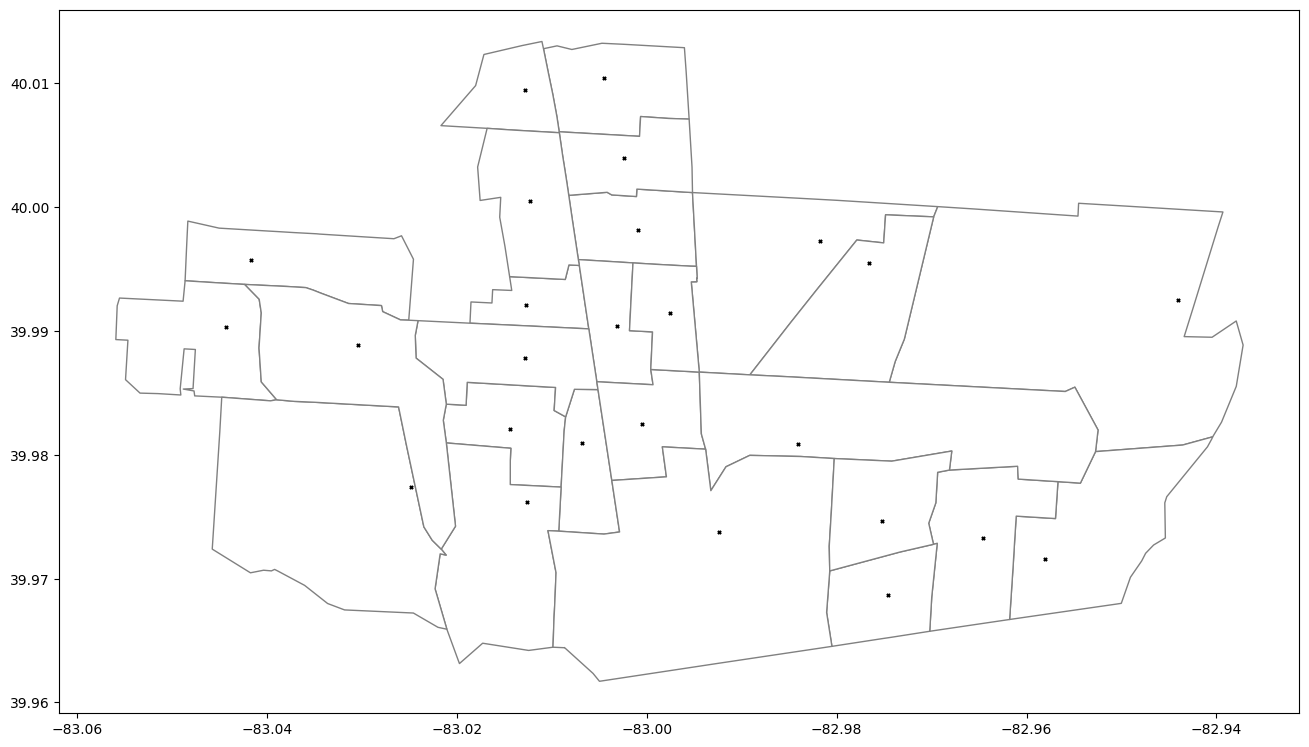

In [ ]:
census_dir = data_dir + "/Census Data/census_tract_data.geojson"
census_df = gpd.read_file(census_dir, crs='EPSG:4326')

hotspot_dir = data_dir + "/Hotspot Data/hotspot_data.geojson"
hotspot_locations = gpd.read_file(hotspot_dir, crs='EPSG:4326')

tract = gpd.GeoSeries(census_df.loc[:].geometry)
size = (16,16)
base = tract.plot(color="white", edgecolor="gray", figsize=size)
hotspot_locations.plot(ax = base, marker='x', color='black', markersize=5, figsize=size)

# save_image(plt, 'city_base')
plt.show()

## **Graph Generation**

### Graph creation code

In [ ]:
import networkx as nx
import numpy as np
from geopy.distance import geodesic
import matplotlib.pyplot as plt
from shapely.geometry import Point
import geopandas as gpd

# At the top of your function, define speed
TRAVEL_SPEED_KMH = 30  # e.g. urban driving speed, adjust as needed


def create_hotspot_graph(hotspot_locations, k_neighbors=5, use_mst_base=True):
    """
    Create a sparse graph using MST as base + limited k-nearest neighbors.

    Parameters:
    - hotspot_locations: GeoDataFrame with hotspot data
    - k_neighbors: Number of nearest neighbors to connect each node to (beyond MST)
    - use_mst_base: If True, starts with MST then adds k-NN edges

    Returns:
    - NetworkX graph object with ~(n-1 + k*n) edges
    """
    from scipy.spatial import cKDTree

    # Create an empty graph
    G = nx.Graph()

    # Store node info
    node_coords = {}
    node_list = []

    # Add nodes for each hotspot
    for idx, row in hotspot_locations.iterrows():
        geoid = row['GEOID']
        geometry = row['geometry']
        locations = row['locations']

        lat = geometry.y
        lon = geometry.x

        G.add_node(geoid,
                  lat=lat,
                  lon=lon,
                  locations=locations,
                  coordinates=(lat, lon),
                  geometry=geometry)

        node_coords[geoid] = (lat, lon)
        node_list.append(geoid)

    # Step 1: Create MST for base connectivity (n-1 edges)
    # First, create a complete graph temporarily to compute MST
    print("Building MST base...")
    temp_G = nx.Graph()
    temp_G.add_nodes_from(G.nodes(data=True))

    for i in range(len(node_list)):
        for j in range(i + 1, len(node_list)):
            node1, node2 = node_list[i], node_list[j]
            coord1 = node_coords[node1]
            coord2 = node_coords[node2]

            distance_km = geodesic(coord1, coord2).kilometers * 1.4   # Temp 1.4
            time_min = (distance_km / TRAVEL_SPEED_KMH) * 60
            temp_G.add_edge(node1, node2,
                        weight=time_min,
                        distance=distance_km,
                        time=time_min)

    # Compute MST
    mst = nx.minimum_spanning_tree(temp_G)

    # Add MST edges to main graph
    G.add_edges_from(mst.edges(data=True))

    print(f"MST created with {mst.number_of_edges()} edges")

    # Step 2: Add k-nearest neighbor edges (for redundancy and shortcuts)
    print(f"Adding {k_neighbors}-nearest neighbor edges...")

    # Build KD-tree for efficient nearest neighbor search
    coords_array = np.array([node_coords[node] for node in node_list])
    tree = cKDTree(coords_array)

    edges_added = 0

    for i, node in enumerate(node_list):
        coord = node_coords[node]

        # Query k+1 neighbors (includes the node itself)
        distances, indices = tree.query(coords_array[i], k=min(k_neighbors + 1, len(node_list)))

        # Skip the first one (distance to itself)
        for dist_deg, idx in zip(distances[1:], indices[1:]):
            neighbor = node_list[idx]

            # Only add if edge doesn't exist (avoid duplicates from MST)
            if not G.has_edge(node, neighbor):
                distance_km = geodesic(coord, node_coords[neighbor]).kilometers * 1.4
                time_min = (distance_km / TRAVEL_SPEED_KMH) * 60  # ← ADD THIS

                G.add_edge(node, neighbor,
                          weight=time_min,
                          distance=distance_km,
                          time=time_min)
                edges_added += 1

    print(f"Added {edges_added} k-NN edges")
    print(f"\nFinal graph stats:")
    print(f"  Nodes: {G.number_of_nodes()}")
    print(f"  Edges: {G.number_of_edges()}")
    print(f"  Average degree: {2 * G.number_of_edges() / G.number_of_nodes():.2f}")
    print(f"  Connected: {nx.is_connected(G)}")

    # Calculate degree distribution
    degrees = [G.degree(node) for node in G.nodes()]
    print(f"  Degree range: {min(degrees)} - {max(degrees)}")
    print(f"  Median degree: {np.median(degrees):.1f}")

    return G

def visualize_hotspot_graph(G, hotspot_locations, census_df=None, show_edges=True, edge_alpha=0.3):
    """
    Visualize the hotspot graph on a map.

    Parameters:
    - G: NetworkX graph
    - hotspot_locations: GeoDataFrame with hotspot data
    - show_edges: Whether to show graph edges
    - edge_alpha: Transparency of edges
    """

    fig, ax = plt.subplots(1, 1, figsize=(12, 10))

    # Plot census tract boundaries first (as base layer)
    if census_df is not None:
        census_df.plot(ax=ax, color="white", edgecolor="gray", linewidth=0.5, alpha=0.8)

    # Plot hotspots
    hotspot_locations.plot(ax=ax, marker='o', color='red', markersize=50, alpha=0.7, label='Hotspots')

    if show_edges and G.number_of_edges() > 0:
        # Draw edges
        for edge in G.edges():
            node1, node2 = edge
            lat1, lon1 = G.nodes[node1]['coordinates']
            lat2, lon2 = G.nodes[node2]['coordinates']

            ax.plot([lon1, lon2], [lat1, lat2], 'b-', alpha=edge_alpha, linewidth=0.5)

    # Add labels for nodes with location counts
    for node in G.nodes():
        lat, lon = G.nodes[node]['coordinates']
        locations = G.nodes[node]['locations']
        ax.annotate(f'{locations}', (lon, lat), xytext=(3, 3), textcoords='offset points',
                   fontsize=8, alpha=0.8)

    ax.set_title(f'Hotspot Graph\nNodes: {G.number_of_nodes()}, Edges: {G.number_of_edges()}')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    plt.legend()
    plt.tight_layout()
    plt.show()

def get_graph_statistics(G):
    """
    Print basic statistics about the graph.
    """
    print("=== Graph Statistics ===")
    print(f"Number of nodes: {G.number_of_nodes()}")
    print(f"Number of edges: {G.number_of_edges()}")
    print(f"Graph density: {nx.density(G):.4f}")
    print(f"Is connected: {nx.is_connected(G)}")

    if G.number_of_edges() > 0:
        weights = [G[u][v]['weight'] for u, v in G.edges()]
        print(f"Average edge weight (distance): {np.mean(weights):.2f} km")
        print(f"Min edge weight: {np.min(weights):.2f} km")
        print(f"Max edge weight: {np.max(weights):.2f} km")

    if not nx.is_connected(G):
        components = list(nx.connected_components(G))
        print(f"Number of connected components: {len(components)}")
        component_sizes = [len(comp) for comp in components]
        print(f"Component sizes: {component_sizes}")


### Load clique graph with graphhopper data

In [ ]:
census_df = gpd.read_file(data_dir + "/Census Data/census_tract_data.geojson")
# num_hotspots = len(census_df.index)
# print(num_hotspots)

# === FILE PATHS ===
hotspot_path = data_dir + "/UMST Graph/graphs/gh_hotspot_graph.graphml"
census_path = data_dir + "/Census Data/census_tract_data.geojson"
hotspot_geojson_path = data_dir + "/Hotspot Data/hotspot_data.geojson"

# === 1. LOAD GRAPH ===
print("\n[1] Loading clique graph from files...")
hotspot_graph = nx.read_graphml(hotspot_path)

# Restore coordinates from lat/lon
for n in hotspot_graph.nodes():
    if 'lat' in hotspot_graph.nodes[n] and 'lon' in hotspot_graph.nodes[n]:
        hotspot_graph.nodes[n]['coordinates'] = (
            float(hotspot_graph.nodes[n]['lat']),
            float(hotspot_graph.nodes[n]['lon'])
        )


# Load census tract boundaries for visualization
try:
    census_gdf = gpd.read_file(census_path, crs='EPSG:4326')
    print(f"    ✓ Census tracts loaded: {len(census_gdf)} tracts")
except Exception as e:
    print(f"    ⚠ Warning: Could not load census data: {e}")
    print(f"    Continuing without census tract boundaries...")
    census_gdf = None

print(f"    ✓ Hotspot Graph: {hotspot_graph.number_of_nodes()} nodes, {hotspot_graph.number_of_edges()} edges")


# Get number of hotspots (nodes)
num_hotspots = hotspot_graph.number_of_nodes()
print(f"Number of hotspots: {num_hotspots}")


[1] Loading clique graph from files...
    ✓ Census tracts loaded: 26 tracts
    ✓ Hotspot Graph: 26 nodes, 168 edges
Number of hotspots: 26


/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:200: RuntimeWarning: driver GeoJSON does not support open option CRS
  return ogr_read(


#### Graph Creation function call

In [ ]:
# # Create the graph from your hotspot data
# print("Creating complete hotspot graph (all nodes connected)...")
# hotspot_graph = create_hotspot_graph(hotspot_locations, k_neighbors=k_neighbors, use_mst_base=True)

### Display Hotspot graph

=== Graph Statistics ===
Number of nodes: 26
Number of edges: 168
Graph density: 0.5169
Is connected: True
Average edge weight (distance): 5.53 km
Min edge weight: 1.33 km
Max edge weight: 13.72 km

Visualizing hotspot graph with census tract boundaries...


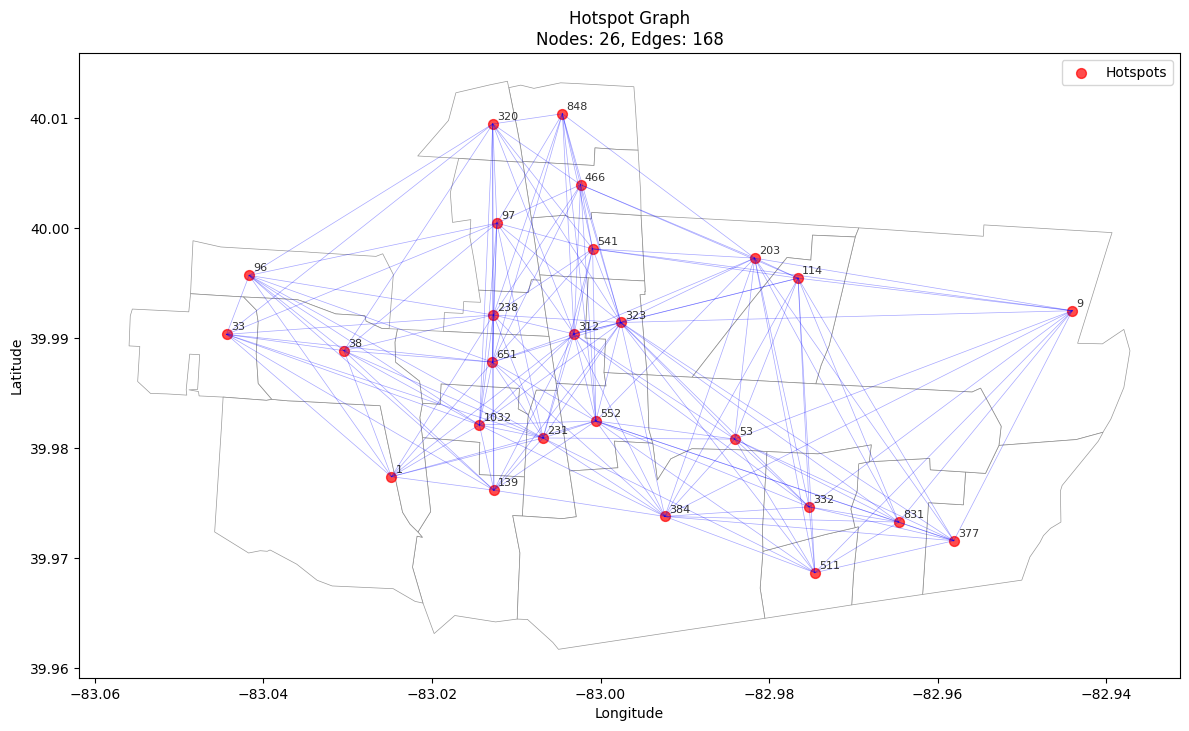

In [ ]:
# Display graph statistics
get_graph_statistics(hotspot_graph)

# Visualize the graph with census tract boundaries
print("\nVisualizing hotspot graph with census tract boundaries...")
visualize_hotspot_graph(hotspot_graph, hotspot_locations, census_df, show_edges=True, edge_alpha=0.35)

In [ ]:
# gh_hotspot_graph = run_graphhopper_queries(hotspot_graph, keys)


# # We are skipping Graphhopper Queries

gh_hotspot_graph = hotspot_graph

In [ ]:
# import pickle
# import os

# # Define directory and file path
# save_dir = os.path.join(output_dir, "UMST Graph")
# os.makedirs(save_dir, exist_ok=True)  # Create directory if it doesn't exist

# file_path = os.path.join(save_dir, "gh_hotspot_graph.pkl")

# # Save pickle file
# with open(file_path, "wb") as f:
#     pickle.dump(gh_hotspot_graph, f)




### GH-Query



In [ ]:
import requests
import time
import pickle
import os
import hashlib
from typing import List, Dict, Tuple, Any
import networkx as nx

# Configuration
CACHE_DIR = os.path.join(data_dir, "gh_cache")
CACHE_FILE = os.path.join(CACHE_DIR, "gh_queries.pkl")

keys = [
    '490135cd-63e4-461d-9b63-6f0911c94335',
    'd927fb04-31ab-43e6-9b4b-62a11d96e928',  # Add your GraphHopper API key here
    '70ec22eb-155c-41b7-9daf-e760e8ac34a8'
]

URL = "https://graphhopper.com/api/1/matrix"
req_lim = 80
key_ind = len(keys) - 1

In [ ]:
def gh_query(from_point: List[float], to_point: List[float], keys: List[str]) -> Dict:
    """
    GraphHopper query function with caching
    """
    global key_ind

    # Check cache first
    cache = load_cache()
    cache_key = generate_cache_key(from_point, to_point)

    if cache_key in cache:
        print(f"Cache hit for {from_point} -> {to_point}")
        return cache[cache_key]

    print(f"Querying API for {from_point} -> {to_point}")

    # Do-while loop in python, runs query before checking
    while True:
        # Query to provide the key
        query = {"key": keys[key_ind]}
        # Payload to send rest of data
        payload = {
            "profile": "car",
            "from_points": from_point,
            "to_points": to_point,
            "out_arrays": ["distances", "times", "weights"],
            "fail_fast": "true",
        }
        # Get response using POST
        response = requests.post(URL, json=payload, params=query)

        # Check if response is successful
        if response.status_code != 200:
            print(f"HTTP Error {response.status_code}: {response.text}")
            time.sleep(1)
            continue

        try:
            data = response.json()  # Store data as json
        except requests.exceptions.JSONDecodeError as e:
            print(f"JSON decode error: {e}")
            print(f"Response content: {response.text[:500]}")  # First 500 chars
            time.sleep(1)
            continue

        # If there is a message, then something went wrong.
        if 'message' not in data.keys():
            # Cache successful result
            cache[cache_key] = data
            save_cache(cache)
            return data  # No message so return data
        else:  # Assume message says key ran out
            if key_ind > 0:  # Make sure we don't exit bounds of list
                key_ind -= 1
            else:  # Otherwise we have run out of keys
                if 'Minutely API limit heavily violated' not in data['message']:
                    print(data['message'])
                key_ind = len(keys) - 1
                time.sleep(60)  # Wait if rate limited

##### Utility functions for Graphhopper query

In [ ]:
def ensure_cache_dir():
    """Create cache directory if it doesn't exist"""
    if not os.path.exists(CACHE_DIR):
        os.makedirs(CACHE_DIR)

def load_cache() -> Dict:
    """Load cached queries from disk"""
    if os.path.exists(CACHE_FILE):
        try:
            with open(CACHE_FILE, 'rb') as f:
                return pickle.load(f)
        except:
            return {}
    return {}

def save_cache(cache: Dict):
    """Save cached queries to disk"""
    ensure_cache_dir()
    with open(CACHE_FILE, 'wb') as f:
        pickle.dump(cache, f)

def generate_cache_key(from_point: List[float], to_point: List[float], profile: str = "car") -> str:
    """Generate unique cache key for query"""
    # Handle both single coordinate pairs and lists of coordinates
    if isinstance(from_point[0], list):
        # If it's a list of lists, take the first coordinate pair
        from_coords = from_point[0]
        to_coords = to_point[0]
    else:
        # If it's a single coordinate pair
        from_coords = from_point
        to_coords = to_point

    key_data = f"{from_coords[0]:.6f},{from_coords[1]:.6f}_{to_coords[0]:.6f},{to_coords[1]:.6f}_{profile}"
    return hashlib.md5(key_data.encode()).hexdigest()

def run_graphhopper_queries(hotspot_graph: nx.Graph, keys: List[str]) -> nx.Graph:
    """
    Run GraphHopper queries for all edges in the graph and update with real data
    """
    print(f"Starting GraphHopper queries for {len(hotspot_graph.edges())} edges...")

    # Create a copy of the graph to avoid modifying the original
    updated_graph = hotspot_graph.copy()

    # Counter for progress tracking
    total_edges = len(hotspot_graph.edges())
    processed = 0

    # Process each edge
    for u, v, data in hotspot_graph.edges(data=True):
        processed += 1
        print(f"Processing edge {processed}/{total_edges}: {u} -> {v}")

        # Get coordinates from node data (handle different longitude key names)
        u_node = hotspot_graph.nodes[u]
        v_node = hotspot_graph.nodes[v]

        # Try different longitude key variations
        lng_key = None
        for key in ['lng', 'lon', 'longitude']:
            if key in u_node:
                lng_key = key
                break

        if lng_key is None:
            print(f"  Error: No longitude key found in node {u}. Available keys: {list(u_node.keys())}")
            continue

        from_coords = [[u_node[lng_key], u_node['lat']]]  # [lon, lat] format as list of lists
        to_coords = [[v_node[lng_key], v_node['lat']]]    # [lon, lat] format as list of lists

        try:
            # Query GraphHopper
            result = gh_query(from_coords, to_coords, keys)

            # Extract distance and time from result
            if 'distances' in result and 'times' in result:
                # GraphHopper returns matrices, we need [0][0] for single point-to-point
                distance_m = result['distances'][0][0]  # Distance in meters
                time_s = result['times'][0][0]  # Time in seconds

                # Convert to desired units
                distance_km = distance_m / 1000.0  # Convert to kilometers
                time_minutes = time_s / 60.0  # Convert to minutes

                # Update edge data
                updated_graph[u][v]['distance'] = distance_km
                updated_graph[u][v]['time'] = time_minutes

                print(f"  Distance: {distance_km:.2f} km, Time: {time_minutes:.2f} min")
            else:
                print(f"  Warning: No valid data returned for edge {u} -> {v}")
                # Keep original values if query failed

        except Exception as e:
            print(f"  Error processing edge {u} -> {v}: {str(e)}")
            # Keep original values if query failed

        # Small delay to be respectful to the API
        time.sleep(0.1)

    print(f"\nCompleted GraphHopper queries for all {total_edges} edges!")
    return updated_graph

def get_cache_stats():
    """Get statistics about cached queries"""
    cache = load_cache()
    print(f"Cache contains {len(cache)} queries")
    return len(cache)

def clear_cache():
    """Clear all cached queries"""
    if os.path.exists(CACHE_FILE):
        os.remove(CACHE_FILE)
        print("Cache cleared!")
    else:
        print("No cache file found.")

In [ ]:
get_cache_stats()

print("GraphHopper Query Manager ready!")
print("Usage:")
print("1. updated_graph = run_graphhopper_queries(hotspot_graph, keys)")
print("2. get_cache_stats() - to see cached queries")
print("3. clear_cache() - to clear all cached data")

Cache contains 325 queries
GraphHopper Query Manager ready!
Usage:
1. updated_graph = run_graphhopper_queries(hotspot_graph, keys)
2. get_cache_stats() - to see cached queries
3. clear_cache() - to clear all cached data


##### Query

In [ ]:
# Determine the travel graph based on whether road network data is requested
if with_geodesic_distance:
    # Fallback to Geodesic (straight-line) distance
    gh_hotspot_graph = hotspot_graph.copy()
else:
    gh_hotspot_graph = run_graphhopper_queries(hotspot_graph, keys)

Starting GraphHopper queries for 168 edges...
Processing edge 1/168: 39049001110 -> 39049001000
Cache hit for [[-83.01279606706105, 40.0094681290053]] -> [[-83.00452901784297, 40.0103956014305]]
  Distance: 1.02 km, Time: 3.45 min
Processing edge 2/168: 39049001110 -> 39049001121
Cache hit for [[-83.01279606706105, 40.0094681290053]] -> [[-83.01230072161665, 40.00045262230653]]
  Distance: 1.71 km, Time: 3.90 min
Processing edge 3/168: 39049001110 -> 39049001200
Cache hit for [[-83.01279606706105, 40.0094681290053]] -> [[-83.00236893225473, 40.00394748402827]]
  Distance: 1.93 km, Time: 4.30 min
Processing edge 4/168: 39049001110 -> 39049001300
Cache hit for [[-83.01279606706105, 40.0094681290053]] -> [[-83.00093965606352, 39.998113492276296]]
  Distance: 2.42 km, Time: 4.77 min
Processing edge 5/168: 39049001110 -> 39049001810
Cache hit for [[-83.01279606706105, 40.0094681290053]] -> [[-83.0127189313813, 39.99210230198253]]
  Distance: 3.20 km, Time: 6.47 min
Processing edge 6/168: 39

In [ ]:
import pickle
import os

# Define directory and file path
save_dir = os.path.join(data_dir, "UMST Graph")
os.makedirs(save_dir, exist_ok=True)  # Create directory if it doesn't exist

file_path = os.path.join(save_dir, "gh_hotspot_graph.pkl")

# Save pickle file
with open(file_path, "wb") as f:
    pickle.dump(gh_hotspot_graph, f)


In [ ]:
def prepare_graph_for_graphml(G):
      """Remove or convert attributes that GraphML cannot handle"""
      G_clean = G.copy()

      # Convert tuple coordinates to separate lat/lon attributes
      for node in G_clean.nodes():
          if 'coordinates' in G_clean.nodes[node]:
              lat, lon = G_clean.nodes[node]['coordinates']
              G_clean.nodes[node]['lat'] = float(lat)
              G_clean.nodes[node]['lon'] = float(lon)
              del G_clean.nodes[node]['coordinates']

          # Remove geometry objects (Shapely objects not supported)
          if 'geometry' in G_clean.nodes[node]:
              del G_clean.nodes[node]['geometry']

      return G_clean

In [ ]:
# Save clique graphs for each N value
for k in k_neighbors_list:
    clique_g = create_hotspot_graph(hotspot_locations, k_neighbors=k, use_mst_base=True)
    clique_clean = prepare_graph_for_graphml(clique_g)
    nx.write_graphml(clique_clean, umst_dir + f"/clique_{k}_graph.graphml")
    print(f"Clique-{k} graph saved to: {umst_dir}/clique_{k}_graph.graphml")

# Keep legacy file as clique_10 alias for backward compatibility
hotspot_clean = prepare_graph_for_graphml(gh_hotspot_graph)
nx.write_graphml(hotspot_clean, umst_dir + "/gh_hotspot_graph.graphml")
print(f"Full Graph saved to: {umst_dir}/gh_hotspot_graph.graphml")

In [ ]:
# Save original graph-> hotspot graph
hotspot_clean = prepare_graph_for_graphml(gh_hotspot_graph)
nx.write_graphml(hotspot_clean, umst_dir + "/gh_hotspot_graph.graphml")
print(f"Full Graph saved to: {umst_dir}/gh_hotspot_graph.graphml")

Full Graph saved to: ./gdrive/MyDrive/UMST_DeliverAI/Delivery_Data/Columbus_mini - RL Delivery Data/UMST Graph/graphs/gh_hotspot_graph.graphml


##  B. UMST Generation

In [ ]:
import networkx as nx
import numpy as np
import random
import matplotlib.pyplot as plt
from collections import defaultdict
import itertools

Addditional: UMST generation Parameter

In [ ]:
# # We got "umst_m20_d50" is doing great
# no_of_mst = 40  # Total no of mst  to finally create UMST
# perc_of_egde_drop_in_mst = 0.1 # Everytime 10% edges will drop randomely
# dist_threshold = 2.5  # Only take edges with dist <= 2.5 km

### UMST calculation functions

In [ ]:
def calculate_umst(G, num_iterations=100, drop_percentage=0.1, random_seed=None):
    """
    Calculate Union of Multiple Spanning Trees (UMST)

    Parameters:
    - G: NetworkX graph
    - num_iterations: Number of MSTs to generate (default 100)
    - drop_percentage: Percentage of edges to drop each iteration (default 0.1 = 10%)
    - random_seed: Random seed for reproducibility

    Returns:
    - umst_graph: Union of all MSTs
    - mst_collection: List of all individual MSTs
    - edge_frequencies: How often each edge appeared in MSTs
    """

    if random_seed is not None:
        random.seed(random_seed)
        np.random.seed(random_seed)

    print(f"Calculating UMST with {num_iterations} iterations...")
    print(f"Original graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
    print(f"Dropping edges with  {drop_percentage*100}% of probability")

    if not nx.is_connected(G):
        print("Warning: Graph is not connected. Using largest connected component.")
        largest_cc = max(nx.connected_components(G), key=len)
        G = G.subgraph(largest_cc).copy()
        print(f"Using connected component: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

    original_edges = list(G.edges())
    # num_edges_to_drop = int(len(original_edges) * drop_percentage)

    # print(f"Will drop {num_edges_to_drop} edges per iteration")

    mst_collection = []
    edge_frequencies = defaultdict(int)
    successful_iterations = 0

    for iteration in range(num_iterations):
        # Create a copy of the original graph
        G_modified = G.copy()

        # # Randomly drop edges
        # edges_to_drop = random.sample(original_edges, num_edges_to_drop)
        # G_modified.remove_edges_from(edges_to_drop)

        # Randomly drop edges using probabilistic road closure
        edges_to_drop = [edge for edge in original_edges if random.random() < drop_percentage]


        G_modified.remove_edges_from(edges_to_drop)


        # Check if graph is still connected after dropping edges
        if nx.is_connected(G_modified):
            # Calculate MST of the modified graph
            mst = nx.minimum_spanning_tree(G_modified, weight='weight')
            mst_collection.append(mst)

            # Count edge frequencies
            for edge in mst.edges():
                # Ensure consistent edge representation (smaller node first)
                edge_key = tuple(sorted(edge))
                edge_frequencies[edge_key] += 1

            successful_iterations += 1

            if (iteration + 1) % 20 == 0:
                print(f"Completed {iteration + 1}/{num_iterations} iterations...")
        else:
            if iteration < 10:  # Only print warnings for first few failures
                print(f"Iteration {iteration + 1}: Graph disconnected after dropping edges, skipping...")

    print(f"Successfully completed {successful_iterations}/{num_iterations} iterations")

    if successful_iterations == 0:
        print("Error: No successful iterations! Try reducing drop_percentage.")
        return None, [], {}

    # Create UMST by taking union of all MST edges
    umst_graph = G.copy()
    umst_graph.remove_edges_from(list(umst_graph.edges()))  # Remove all edges first

    # Add all edges that appeared in any MST
    umst_edges = set()
    for mst in mst_collection:
        for edge in mst.edges():
            edge_key = tuple(sorted(edge))
            umst_edges.add(edge_key)

    # Add edges back to UMST graph with original attributes
    for edge_key in umst_edges:
        node1, node2 = edge_key
        if G.has_edge(node1, node2):
            # Copy edge with all original attributes
            edge_data = G[node1][node2].copy()
            umst_graph.add_edge(node1, node2, **edge_data)

            # Add frequency information
            frequency = edge_frequencies[edge_key]
            umst_graph[node1][node2]['mst_frequency'] = frequency
            umst_graph[node1][node2]['frequency_ratio'] = frequency / successful_iterations

    print(f"UMST created: {umst_graph.number_of_nodes()} nodes, {umst_graph.number_of_edges()} edges")
    print(f"Edge reduction: {G.number_of_edges()} → {umst_graph.number_of_edges()} ({(1-umst_graph.number_of_edges()/G.number_of_edges())*100:.1f}% reduction)")

    return umst_graph, mst_collection, dict(edge_frequencies)

In [ ]:
def calculate_umst(G, num_iterations=100, drop_percentage=0.1, random_seed=None):
    """
    Calculate Union of Multiple Spanning Trees (UMST)

    Parameters:
    - G: NetworkX graph
    - num_iterations: Number of MSTs to generate (default 100)
    - drop_percentage: Percentage of edges to drop each iteration (default 0.1 = 10%)
    - random_seed: Random seed for reproducibility

    Returns:
    - umst_graph: Union of all MSTs
    - mst_collection: List of all individual MSTs
    - edge_frequencies: How often each edge appeared in MSTs
    """

    if random_seed is not None:
        random.seed(random_seed)
        np.random.seed(random_seed)

    print(f"Calculating UMST with {num_iterations} iterations...")
    print(f"Original graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
    print(f"Dropping edges with {drop_percentage*100}% of probability")

    if not nx.is_connected(G):
        print("Warning: Graph is not connected. Using largest connected component.")
        largest_cc = max(nx.connected_components(G), key=len)
        G = G.subgraph(largest_cc).copy()
        print(f"Using connected component: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

    original_edges = list(G.edges())
    # num_edges_to_drop = int(len(original_edges) * drop_percentage)

    # print(f"Will drop {num_edges_to_drop} edges per iteration")

    mst_collection = []
    edge_frequencies = defaultdict(int)
    successful_iterations = 0

    for iteration in range(num_iterations):
        # Create a copy of the original graph
        G_modified = G.copy()

        # # Randomly drop edges
        # edges_to_drop = random.sample(original_edges, num_edges_to_drop)
        # G_modified.remove_edges_from(edges_to_drop)

        # Randomly drop edges using probabilistic road closure
        edges_to_drop = [edge for edge in original_edges if random.random() < drop_percentage]
        print(f"Iteration {iteration+1}: Dropping {len(edges_to_drop)} edges")

        G_modified.remove_edges_from(edges_to_drop)

        # Check if graph is still connected after dropping edges
        if nx.is_connected(G_modified):
            # Calculate MST of the modified graph
            mst = nx.minimum_spanning_tree(G_modified, weight='weight')
            mst_collection.append(mst)

            # Count edge frequencies
            for edge in mst.edges():
                # Ensure consistent edge representation (smaller node first)
                edge_key = tuple(sorted(edge))
                edge_frequencies[edge_key] += 1

            successful_iterations += 1

            if (iteration + 1) % 20 == 0:
                print(f"Completed {iteration + 1}/{num_iterations} iterations...")
        else:
            if iteration < 10:  # Only print warnings for first few failures
                print(f"Iteration {iteration + 1}: Graph disconnected after dropping edges, skipping...")

    print(f"Successfully completed {successful_iterations}/{num_iterations} iterations")

    if successful_iterations == 0:
        print("Error: No successful iterations! Try reducing drop_percentage.")
        return None, [], {}

    # Create UMST by taking union of all MST edges
    umst_graph = G.copy()
    umst_graph.remove_edges_from(list(umst_graph.edges()))  # Remove all edges first

    # Add all edges that appeared in any MST
    umst_edges = set()
    for mst in mst_collection:
        for edge in mst.edges():
            edge_key = tuple(sorted(edge))
            umst_edges.add(edge_key)

    # Add edges back to UMST graph with original attributes
    for edge_key in umst_edges:
        node1, node2 = edge_key
        if G.has_edge(node1, node2):
            # Copy edge with all original attributes
            edge_data = G[node1][node2].copy()
            umst_graph.add_edge(node1, node2, **edge_data)

            # Add frequency information
            frequency = edge_frequencies[edge_key]
            umst_graph[node1][node2]['mst_frequency'] = frequency
            umst_graph[node1][node2]['frequency_ratio'] = frequency / successful_iterations

    print(f"UMST created: {umst_graph.number_of_nodes()} nodes, {umst_graph.number_of_edges()} edges")
    print(f"Edge reduction: {G.number_of_edges()} → {umst_graph.number_of_edges()} ({(1-umst_graph.number_of_edges()/G.number_of_edges())*100:.1f}% reduction)")

    return umst_graph, mst_collection, dict(edge_frequencies)

### Analyze and visualize UMST edges

In [ ]:
def analyze_umst_results(G_original, umst_graph, edge_frequencies, mst_collection):
    """
    Analyze UMST results and provide statistics
    """
    print("\n" + "="*60)
    print("UMST ANALYSIS")
    print("="*60)

    total_iterations = len(mst_collection)

    print(f"Original graph edges: {G_original.number_of_edges()}")
    print(f"UMST edges: {umst_graph.number_of_edges()}")
    print(f"Edge retention rate: {umst_graph.number_of_edges()/G_original.number_of_edges()*100:.1f}%")

    # Analyze edge frequencies
    frequencies = list(edge_frequencies.values())
    print(f"\nEdge Frequency Statistics:")
    print(f"  Mean frequency: {np.mean(frequencies):.2f}")
    print(f"  Median frequency: {np.median(frequencies):.2f}")
    print(f"  Min frequency: {np.min(frequencies)}")
    print(f"  Max frequency: {np.max(frequencies)}")
    print(f"  Std deviation: {np.std(frequencies):.2f}")

    # Categorize edges by frequency
    high_freq_edges = sum(1 for f in frequencies if f >= total_iterations * 0.8)
    medium_freq_edges = sum(1 for f in frequencies if total_iterations * 0.4 <= f < total_iterations * 0.8)
    low_freq_edges = sum(1 for f in frequencies if f < total_iterations * 0.4)

    print(f"\nEdge Categories:")
    print(f"  High frequency (≥80%): {high_freq_edges} edges")
    print(f"  Medium frequency (40-80%): {medium_freq_edges} edges")
    print(f"  Low frequency (<40%): {low_freq_edges} edges")

    # Analyze MST sizes
    mst_sizes = [mst.number_of_edges() for mst in mst_collection]
    print(f"\nMST Size Statistics:")
    print(f"  Expected MST size (n-1): {umst_graph.number_of_nodes()-1}")
    print(f"  Mean MST size: {np.mean(mst_sizes):.2f}")
    print(f"  MST size range: {np.min(mst_sizes)} - {np.max(mst_sizes)}")

def visualize_umst_comparison(G_original, umst_graph, hotspot_locations, census_df=None):
    """
    Visualize original graph vs UMST side by side
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

    # Plot original graph
    if census_df is not None:
        census_df.plot(ax=ax1, color="white", edgecolor="gray", linewidth=0.5, alpha=0.8)
        census_df.plot(ax=ax2, color="white", edgecolor="gray", linewidth=0.5, alpha=0.8)

    # Plot hotspots
    hotspot_locations.plot(ax=ax1, marker='x', color='black', markersize=30, alpha=0.9)
    hotspot_locations.plot(ax=ax2, marker='x', color='black', markersize=30, alpha=0.9)

    # Plot edges - Original graph
    for edge in G_original.edges():
        node1, node2 = edge
        if node1 in [node for node in G_original.nodes()] and node2 in [node for node in G_original.nodes()]:
            lat1, lon1 = G_original.nodes[node1]['coordinates']
            lat2, lon2 = G_original.nodes[node2]['coordinates']
            ax1.plot([lon1, lon2], [lat1, lat2], 'b-', alpha=0.5, linewidth=0.5)

    # Plot edges - UMST with frequency-based coloring
    for edge in umst_graph.edges(data=True):
        node1, node2, data = edge
        lat1, lon1 = umst_graph.nodes[node1]['coordinates']
        lat2, lon2 = umst_graph.nodes[node2]['coordinates']

        # Color based on frequency
        frequency_ratio = data.get('frequency_ratio', 0)
        if frequency_ratio >= 0.8:
            color, alpha, width = 'red', 0.8, 2.0    # High frequency - thick red
        elif frequency_ratio >= 0.4:
            color, alpha, width = 'orange', 0.6, 1.5  # Medium frequency - orange
        else:
            color, alpha, width = 'blue', 0.4, 1.0    # Low frequency - thin blue

        ax2.plot([lon1, lon2], [lat1, lat2], color=color, alpha=alpha, linewidth=width)

    ax1.set_title(f'Original Graph\n{G_original.number_of_nodes()} nodes, {G_original.number_of_edges()} edges')
    ax2.set_title(f'UMST Graph\n{umst_graph.number_of_nodes()} nodes, {umst_graph.number_of_edges()} edges')

    ax1.set_xlabel('Longitude')
    ax1.set_ylabel('Latitude')
    ax2.set_xlabel('Longitude')
    ax2.set_ylabel('Latitude')

    # Add legend for UMST
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color='red', lw=2, alpha=0.8, label='High frequency (≥80%)'),
        Line2D([0], [0], color='orange', lw=1.5, alpha=0.6, label='Medium frequency (40-80%)'),
        Line2D([0], [0], color='blue', lw=1, alpha=0.4, label='Low frequency (<40%)')
    ]
    ax2.legend(handles=legend_elements, loc='upper right')

    plt.tight_layout()
    plt.show()

def get_critical_edges(umst_graph, threshold=0.8):
    """
    Get edges that appear in most MSTs (critical for connectivity)
    """
    critical_edges = []

    for edge in umst_graph.edges(data=True):
        node1, node2, data = edge
        frequency_ratio = data.get('frequency_ratio', 0)

        if frequency_ratio >= threshold:
            critical_edges.append({
                'edge': (node1, node2),
                'frequency_ratio': frequency_ratio,
                'frequency_count': data.get('mst_frequency', 0),
                'weight': data.get('weight', 0)
            })

    # Sort by frequency ratio
    critical_edges.sort(key=lambda x: x['frequency_ratio'], reverse=True)

    print(f"\nCritical Edges (appearing in ≥{threshold*100}% of MSTs):")
    print(f"Found {len(critical_edges)} critical edges")

    for i, edge_info in enumerate(critical_edges[:10]):  # Show top 10
        edge = edge_info['edge']
        freq_ratio = edge_info['frequency_ratio']
        weight = edge_info['weight']
        print(f"  {i+1:2d}. {edge[0]} ↔ {edge[1]}: {freq_ratio*100:5.1f}% (weight: {weight:.2f})")

    return critical_edges

def visualize_individual_msts(mst_collection, hotspot_locations, census_df=None, max_display=20, msts_per_row=4):
    """
    Visualize individual MSTs to see the variation using a grid layout
    """
    num_msts = min(len(mst_collection), max_display)

    if num_msts == 0:
        print("No MSTs to display")
        return

    # Calculate grid dimensions
    cols = min(msts_per_row, num_msts)
    rows = (num_msts + cols - 1) // cols  # Ceiling division

    fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 4*rows))

    # Handle different subplot configurations
    if rows == 1 and cols == 1:
        axes = [axes]
    elif rows == 1:
        axes = axes.flatten()
    elif cols == 1:
        axes = axes.flatten()
    else:
        axes = axes.flatten()

    # Color palette for different MSTs
    colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan',
              'magenta', 'yellow', 'navy', 'lime', 'maroon', 'teal', 'silver', 'indigo', 'coral', 'gold']

    for i in range(rows * cols):
        ax = axes[i]

        if i < num_msts:
            mst = mst_collection[i]

            # Plot census tract boundaries
            if census_df is not None:
                census_df.plot(ax=ax, color="white", edgecolor="gray", linewidth=0.3, alpha=0.8)

            # Plot hotspots
            hotspot_locations.plot(ax=ax, marker='o', color='black', markersize=15, alpha=0.9)

            # Plot MST edges
            for edge in mst.edges():
                node1, node2 = edge
                lat1, lon1 = mst.nodes[node1]['coordinates']
                lat2, lon2 = mst.nodes[node2]['coordinates']
                ax.plot([lon1, lon2], [lat1, lat2], color=colors[i % len(colors)],
                       alpha=0.8, linewidth=1.5)

            # Calculate total weight
            total_weight = sum(mst[u][v]['weight'] for u, v in mst.edges())

            ax.set_title(f'MST {i+1}\n{mst.number_of_edges()} edges\nWeight: {total_weight:.1f}km', fontsize=10)
            ax.set_xlabel('Longitude', fontsize=8)
            ax.set_ylabel('Latitude', fontsize=8)
            ax.tick_params(labelsize=8)
        else:
            # Hide unused subplots
            ax.set_visible(False)

    plt.tight_layout()
    plt.show()

    if num_msts > max_display:
        print(f"Showing first {max_display} MSTs out of {len(mst_collection)} total MSTs")


def compare_mst_statistics(mst_collection):
    """
    Compare statistics across different MSTs
    """
    print("\n" + "="*50)
    print("INDIVIDUAL MST COMPARISON")
    print("="*50)

    for i, mst in enumerate(mst_collection):
        weights = [mst[u][v]['weight'] for u, v in mst.edges()]
        total_weight = sum(weights)

        print(f"MST {i+1}:")
        print(f"  Edges: {mst.number_of_edges()}")
        print(f"  Total weight: {total_weight:.2f} km")
        print(f"  Average edge weight: {np.mean(weights):.2f} km")
        print(f"  Min edge weight: {np.min(weights):.2f} km")
        print(f"  Max edge weight: {np.max(weights):.2f} km")
        print()

def analyze_edge_differences(mst_collection):
    """
    Analyze which edges differ between MSTs
    """
    print("\n" + "="*50)
    print("EDGE DIFFERENCE ANALYSIS")
    print("="*50)

    if len(mst_collection) < 2:
        print("Need at least 2 MSTs for comparison")
        return

    # Get all edges from each MST
    mst_edges = []
    for i, mst in enumerate(mst_collection):
        edges = set()
        for edge in mst.edges():
            edges.add(tuple(sorted(edge)))  # Normalize edge representation
        mst_edges.append(edges)
        print(f"MST {i+1} has {len(edges)} edges")

    # Find common and unique edges
    all_edges = set().union(*mst_edges)
    common_edges = set.intersection(*mst_edges)

    print(f"\nTotal unique edges across all MSTs: {len(all_edges)}")
    print(f"Common edges in all MSTs: {len(common_edges)}")
    print(f"Variable edges: {len(all_edges) - len(common_edges)}")

    # Show which edges are common
    if len(common_edges) > 0:
        print(f"\nEdges that appear in ALL {len(mst_collection)} MSTs:")
        for i, edge in enumerate(sorted(common_edges)[:10]):  # Show first 10
            print(f"  {i+1}. {edge[0]} ↔ {edge[1]}")
        if len(common_edges) > 10:
            print(f"  ... and {len(common_edges) - 10} more")

    # Show which edges vary
    variable_edges = all_edges - common_edges
    if len(variable_edges) > 0:
        print(f"\nEdges that vary between MSTs:")
        for i, edge in enumerate(sorted(variable_edges)[:10]):  # Show first 10
            count = sum(1 for mst_edge_set in mst_edges if edge in mst_edge_set)
            print(f"  {i+1}. {edge[0]} ↔ {edge[1]} (appears in {count}/{len(mst_collection)} MSTs)")
        if len(variable_edges) > 10:
            print(f"  ... and {len(variable_edges) - 10} more")

### UMST Function Call

In [ ]:
if regenerate_umst:
    # Example usage with your hotspot_graph:
    print("Running UMST analysis on our Clique graph...")
    print("Starting with MSTs for initial analysis...")

    # Calculate UMST with  iterations first
    umst_graph, mst_collection, edge_frequencies = calculate_umst(
        hotspot_graph,  # our hotspot graph
        num_iterations= no_of_mst, # Initially taking 40 mst's
        drop_percentage = perc_of_egde_drop_in_mst,  # 0.1 for 10%
        random_seed=42
    )

    if umst_graph is not None:
        # Show individual MSTs first
        print("\nVisualizing individual MSTs...")
        visualize_individual_msts(mst_collection, hotspot_locations, census_df, max_display=no_of_mst)

        # Compare MST statistics
        compare_mst_statistics(mst_collection)

        # Analyze edge differences
        analyze_edge_differences(mst_collection)

        # Analyze results
        analyze_umst_results(hotspot_graph, umst_graph, edge_frequencies, mst_collection)

        # Get critical edges
        critical_edges = get_critical_edges(umst_graph, threshold=0.6)  # Lower threshold for 5 MSTs

        # Visualize comparison
        print("\nCreating UMST comparison visualization...")
        visualize_umst_comparison(hotspot_graph, umst_graph, hotspot_locations, census_df)

        # Option to run with more MSTs
        print("\n" + "="*60)
        print("All-MST ANALYSIS COMPLETE!")
        print("="*60)
        print("This was just a quick analysis with all MSTs.")
        print("For more robust results, consider running with 50-100 MSTs.")
        print("\nTo run with more MSTs, execute:")
        print("umst_graph_full, mst_collection_full, edge_frequencies_full = calculate_umst(")
        print("    hotspot_graph, num_iterations=100, drop_percentage=0.5, random_seed=42)")

        # Save results
        print("\nSaving all-MST results...")

        # Function to clean graph for GraphML saving
        def prepare_graph_for_graphml(G):
            """Remove or convert attributes that GraphML cannot handle"""
            G_clean = G.copy()

            # Convert tuple coordinates to separate lat/lon attributes
            for node in G_clean.nodes():
                if 'coordinates' in G_clean.nodes[node]:
                    lat, lon = G_clean.nodes[node]['coordinates']
                    G_clean.nodes[node]['lat'] = float(lat)
                    G_clean.nodes[node]['lon'] = float(lon)
                    del G_clean.nodes[node]['coordinates']

                # Remove geometry objects (Shapely objects not supported)
                if 'geometry' in G_clean.nodes[node]:
                    del G_clean.nodes[node]['geometry']

            return G_clean

        # Save UMST
        umst_dir = data_dir + "/UMST Graph/graphs"
        os.makedirs(umst_dir, exist_ok=True)

        umst_clean = prepare_graph_for_graphml(umst_graph)
        nx.write_graphml(umst_clean, umst_dir + "/umst_graph.graphml")
        print(f"UMST saved to: {umst_dir}/umst_graph.graphml")

        # Save original graph-> hotspot graph
        hotspot_clean = prepare_graph_for_graphml(hotspot_graph)
        nx.write_graphml(hotspot_clean, umst_dir + "/gh_hotspot_graph.graphml")
        print(f"Full Graph saved to: {umst_dir}/gh_hotspot_graph.graphml")

        # Save MST graph
        mst_graph = nx.minimum_spanning_tree(hotspot_graph, weight="distance")
        mst_graph_clean = prepare_graph_for_graphml(mst_graph)
        nx.write_graphml(mst_graph_clean, umst_dir + "/mst_graph.graphml")
        print(f"MST graph saved to: {umst_dir}/mst_graph.graphml")
        # # Save individual MSTs for analysis
        # for i, mst in enumerate(mst_collection):
        #     mst_clean = prepare_graph_for_graphml(mst)
        #     nx.write_graphml(mst_clean, data_dir + f"/UMST Graph/mst_{i+1}.graphml")



    else:
        print("UMST calculation failed. Try reducing the drop_percentage parameter or check graph connectivity.")

else:
    print("Loading previously saved UMST graphs...")
    umst_graph  = nx.read_graphml(umst_dir + "/umst_graph.graphml")
    mst_graph   = nx.read_graphml(umst_dir + "/mst_graph.graphml")
    print("Graphs loaded successfully.")

Loading previously saved UMST graphs...
Graphs loaded successfully.


In [ ]:
print(f"{dist_threshold}")

2.5



## C. Simulation Materials

### 2. Deliveries

#### 2. Delivery Class

In [ ]:
# ============================================================
# 1. DELIVERY CLASS - Enhanced with Raw Data Tracking
# ============================================================
class Delivery:
    """
    Represents a single delivery request with comprehensive tracking.
    """
    id_counter = 0

    def __init__(self, start_node, end_node, start_time, buffer_time_type,
                 time_tolerance_factor, shortest_path=None):
        # Identity
        self.id = Delivery.id_counter
        Delivery.id_counter += 1

        # Route (immutable)
        self.start_node = start_node
        self.end_node = end_node
        self.shortest_path = shortest_path if shortest_path else [start_node, end_node]

        # Time constraints
        self.start_time = start_time
        self.TIME_TOLERANCE_FACTOR = time_tolerance_factor
        self.buffer_time_type = buffer_time_type
        self.time_limit = None  # Set after initialization
        self.expected_travel_time = 0  # Pure travel time without buffer

        # Current state (mutable)
        self.current_node = start_node
        self.path_index = 0
        self.in_transition = False
        self.time_till_next_node = 0
        self.wait_time_remaining = 0

        # Completion tracking
        self.completed = False
        self.successful = False
        self.end_time = None

        # Enhanced Statistics
        self.distance_traveled = 0
        self.actual_path = [start_node]
        self.num_vehicle_changes = 0
        self.times_bundled = 0
        self.total_wait_time = 0
        self.bundle_history = []  # List of (step, bundle_id, action)

        # NEW: Detailed tracking for metrics
        self.actual_delivery_time = 0  # End to end time
        self.delay = 0  # Actual time - expected time
        self.within_buffer = False  # Met expected + buffer?
        self.package_km = 0  # Distance * 1 package

        # Bundle reference
        self.current_bundle_id = None

        self.failed = False

    def get_next_node(self):
        """Get next node in planned path."""
        if self.path_index < len(self.shortest_path) - 1:
            return self.shortest_path[self.path_index + 1]
        return None

    def move_to_next_node(self, distance, travel_time):
        """Start transition to next node."""
        self.in_transition = True
        self.time_till_next_node = travel_time
        self.distance_traveled += distance
        self.package_km = distance  # 1 package * distance

    def arrive_at_node(self, node):
        """Complete arrival at node."""
        self.in_transition = False
        self.current_node = node
        self.actual_path.append(node)
        self.path_index += 1

        if self.current_node == self.end_node:
            self.completed = True

    def finalize_metrics(self, vehicle_change_time):
        """Calculate final metrics after delivery completion."""
        if self.completed and self.end_time:
            # Actual delivery time including penalties
            self.actual_delivery_time = (self.end_time - self.start_time) + \
                                       (self.num_vehicle_changes * vehicle_change_time)

            # Delay calculation
            self.delay = self.actual_delivery_time - self.time_limit
            # self.delay = max(0, self.actual_delivery_time - self.time_limit)

            # Within buffer check
            self.within_buffer = self.actual_delivery_time <= self.time_limit
            self.successful = self.within_buffer

    def reset(self):
        """Reset to initial state."""
        self.current_node = self.start_node
        self.path_index = 0
        self.in_transition = False
        self.time_till_next_node = 0
        self.wait_time_remaining = 0
        self.completed = False
        self.successful = False
        self.end_time = None
        self.distance_traveled = 0
        self.actual_path = [self.start_node]
        self.num_vehicle_changes = 0
        self.current_bundle_id = None
        self.total_wait_time = 0
        self.bundle_history = []
        self.actual_delivery_time = 0
        self.delay = 0
        self.within_buffer = False
        self.times_bundled = 0
        self.failed = False

        # NEW: Clear vehicle references from previous baseline runs
        if hasattr(self, '_dedicated_vehicle_id'):
            delattr(self, '_dedicated_vehicle_id')
        if hasattr(self, '_dedicated_vehicle'):
            delattr(self, '_dedicated_vehicle')


    def __repr__(self):
        status = "✅" if self.completed else ("🚗" if self.in_transition else "⏳")
        bundle = f"[B{self.current_bundle_id}]" if self.current_bundle_id else ""
        return f"D{self.id}:{self.start_node}→{self.end_node}|{status}{bundle}@N{self.current_node}"


#### 3. Vehicle Class

In [ ]:
# ============================================================
# 2. VEHICLE CLASS - Enhanced Tracking
# ============================================================
class Vehicle:
    """
    Represents a physical vehicle with comprehensive metrics.
    """
    id_counter = 0

    def __init__(self, start_node, allow_reuse=True):
        self.id = Vehicle.id_counter
        Vehicle.id_counter += 1

        self.current_node = start_node
        self.allow_reuse = allow_reuse

        # Cumulative stats
        self.total_distance = 0
        self.total_trips = 0
        self.all_deliveries_carried = set()
        self.trip_history = []  # List of (start_time, end_time, deliveries, distance)

        # Current trip
        self.current_trip_distance = 0
        self.current_route = [start_node]
        self.current_trip_start_time = 0
        self.is_in_use = False

        # Reuse management
        self.available_at_time = 0
        self.cooldown_period = 0

    def move_to(self, next_node, distance):
        """Move vehicle to next node."""
        self.current_node = next_node
        self.total_distance += distance
        self.current_trip_distance += distance
        self.current_route.append(next_node)

    def start_new_trip(self, start_node, current_time):
        """Prepare for new trip (reuse)."""
        if not self.allow_reuse:
            raise ValueError("Vehicle reuse not allowed in baseline mode")

        self.current_node = start_node
        self.current_trip_distance = 0
        self.current_route = [start_node]
        self.current_trip_start_time = current_time
        self.total_trips += 1
        self.is_in_use = True
        self.available_at_time = 0

    def release(self, current_time):
        """Mark as available for reuse after cooldown."""
        self.is_in_use = False
        if self.allow_reuse:
            self.available_at_time = current_time + self.cooldown_period

    def can_reuse(self, current_time):
        """Check if vehicle can be reused."""
        return self.allow_reuse and not self.is_in_use and current_time >= self.available_at_time

    def __repr__(self):
        return f"V{self.id}@N{self.current_node}|{self.total_distance/1000:.1f}km"

#### 4. Delivery Bundle Class

In [ ]:
# ============================================================
# 3. BUNDLE CLASS - No Changes Needed
# ============================================================
class Bundle:
    """
    Manages a group of deliveries sharing a vehicle.
    """
    id_counter = 0

    def __init__(self, delivery_ids, vehicle, current_node, next_node, step):
        self.id = Bundle.id_counter
        Bundle.id_counter += 1

        self.delivery_ids = set(delivery_ids)
        self.vehicle = vehicle
        self.current_node = current_node
        self.next_node = next_node
        self.created_at_step = step

        self.is_active = True
        self.dissolved_at_step = None
        self.dissolution_reason = None

    def add_delivery(self, delivery_id):
        self.delivery_ids.add(delivery_id)

    def remove_delivery(self, delivery_id):
        self.delivery_ids.discard(delivery_id)

    def dissolve(self, step, reason):
        self.is_active = False
        self.dissolved_at_step = step
        self.dissolution_reason = reason

    def size(self):
        return len(self.delivery_ids)

    def __repr__(self):
        status = "🟢" if self.is_active else "🔴"
        return f"{status}Bundle{self.id}:[{','.join(f'D{d}' for d in sorted(self.delivery_ids))}]@V{self.vehicle.id}"

#### 5. DeliveryList Class

In [ ]:
# ============================================================
# 4. DELIVERYLIST CLASS - Enhanced with Buffer Time Types
# ============================================================
class DeliveryList:
    """
    Manages collection of deliveries with configurable buffer strategies.
    """

    def __init__(self, max_delivery_time, load, time_tolerance_factor,
                 buffer_time_type="multiply",  # NEW PARAMETER
                 hours=1, peaks=[0.25, 0.75], sigma=10, num_hotspots=50,
                 adjacency_matrix=None, node_positions=None, regenerate=True):

        self.load = load
        self.hours = hours
        self.peaks = peaks
        self.sigma = sigma
        self.time_tolerance_factor = time_tolerance_factor
        self.buffer_time_type = buffer_time_type  # NEW
        self.max_delivery_time = max_delivery_time
        self.num_hotspots = num_hotspots
        self.adjacency_matrix = adjacency_matrix
        self.node_positions = node_positions

        if adjacency_matrix is None or node_positions is None:
            raise ValueError("adjacency_matrix and node_positions are required!")

        # Generate deliveries
        if regenerate:
            self.distribution, self.loads = self.generate_distribution()
            self.computed_paths = {}
            self.deliveries = self.generate_deliveries()
            self.calculate_time_limits()
            with open("delivery_list.pkl", "wb") as f:
                pickle.dump(self.__dict__, f)
        else:
            with open("delivery_list.pkl", "rb") as f:
                self.__dict__ = pickle.load(f)

    # def generate_distribution(self):
    #     """Generate temporal distribution of deliveries."""
    #     mu_list = [peak * 60 * self.hours for peak in self.peaks]
    #     x = np.linspace(0, 60 * self.hours, 60 * self.hours)

    #     y_combined = np.zeros_like(x)
    #     for mu in mu_list:
    #         y_combined += (1 / (self.sigma * np.sqrt(2 * np.pi))) * \
    #                      np.exp(-0.5 * ((x - mu) / self.sigma) ** 2)

    #     loads = [int((self.load * (self.sigma * np.sqrt(2 * np.pi))) * y)
    #             for y in y_combined]

    #     return y_combined, loads

    def generate_distribution(self):
        """Generate temporal distribution of deliveries (correct & normalized)."""

        # Time axis (minutes)
        x = np.arange(0, 60 * self.hours)

        # Convert peak hours to minutes
        mu_list = [peak * 60 for peak in self.peaks]

        # Build combined Gaussian
        y_combined = np.zeros_like(x, dtype=float)

        for mu in mu_list:
            y_combined += (1 / (self.sigma * np.sqrt(2 * np.pi))) * \
                          np.exp(-0.5 * ((x - mu) / self.sigma) ** 2)

        # ✅ Normalize to probability distribution
        y_normalized = y_combined / np.sum(y_combined)

        # ✅ Total deliveries = hotspots × load
        total_deliveries = self.num_hotspots * self.load

        # ✅ Distribute exactly using multinomial
        loads = np.random.multinomial(total_deliveries, y_normalized)

        return y_combined, loads

    def get_travel_time(self, start, end):
        """Get pre-computed travel time between two nodes."""
        if start == end:
            return 0

        if (start, end) not in self.computed_paths:
            return float('inf')

        travel_time, path = self.computed_paths[(start, end)]
        return travel_time

    def calculate_time_limits(self):
        """
        Calculate time limits for all deliveries using buffer strategies.
        """
        for delivery in self.deliveries:
            # Get base travel time
            travel_time = self.get_travel_time(
                delivery.start_node,
                delivery.end_node
            )

            delivery.expected_travel_time = travel_time

            # Calculate required time based on buffer strategy
            if self.buffer_time_type == "multiply":
                required_time = travel_time * delivery.TIME_TOLERANCE_FACTOR

            elif self.buffer_time_type == "randomized":
                required_time = travel_time + random.randint(2, 8) * 60  # 2-8 mins

            elif self.buffer_time_type == 'fixed_buffer':
                required_time = travel_time + 5 * 60  # 5 mins for all

            elif self.buffer_time_type == 'rangewise':
                if travel_time <= 10 * 60:
                    required_time = travel_time + 5 * 60  # 5 mins/3
                elif travel_time <= 20 * 60:
                    required_time = travel_time + 10 * 60  # 10 mins/7
                elif travel_time <= 25 * 60:
                    required_time = travel_time + 12 * 60  # 12 mins
                else:
                    required_time = travel_time + 15 * 60  # 15 mins
            else:
                required_time = travel_time * delivery.TIME_TOLERANCE_FACTOR

            delivery.time_limit = required_time

    def generate_deliveries(self):
        """Generate delivery requests using pre-computed or dynamically computed paths."""
        deliveries = []
        total_deliveries = sum(self.loads)
        valid_nodes = list(range(self.num_hotspots))

        max_attempts_limit = int(20 * total_deliveries)
        total_attempts = 0

        # Reachable Nodes within Delivery Time limit
        reachable = self.build_reachable_neighbors()

        # Sanity check — print after build_reachable_neighbors
        total_pairs = sum(len(v) for v in reachable.values())
        avg_paths = total_pairs / self.num_hotspots
        print(f"  Reachable pairs: {total_pairs}, avg reachable per node: {avg_paths:.1f}")


        valid_starts = [n for n in valid_nodes if reachable[n]]
        if not valid_starts:
            raise RuntimeError("No valid start-end pairs within max_delivery_time.")

        with tqdm(total=total_deliveries, desc="Creating deliveries", leave=False) as pbar:
            for j in range(60 * self.hours):
                for _ in range(self.loads[j]):

                    start = random.choice(valid_starts)
                    end, travel_time, shortest_path = random.choice(reachable[start])

                    # Store result
                    self.computed_paths[(start, end)] = (travel_time, shortest_path)
                    time = random.randint(j * 60, (j + 1) * 60)

                    delivery = Delivery(
                        start, end, time,
                        buffer_time_type=self.buffer_time_type,
                        time_tolerance_factor=self.time_tolerance_factor,
                        shortest_path=shortest_path
                    )
                    deliveries.append(delivery)
                    pbar.update(1)

        return deliveries


    def build_reachable_neighbors(self):
        """
        Use single-source Dijkstra per node instead of A* per (start, end) pair.
        2190 nodes: 2190 Dijkstra runs vs 4.8M A* runs.
        """
        import heapq
        reachable = {}

        for start in tqdm(range(self.num_hotspots), desc="Building reachable map", leave=False):
            reachable[start] = []

            # Single Dijkstra from 'start' to all reachable nodes
            dist = {start: 0}
            prev = {start: None}
            heap = [(0, start)]

            while heap:
                cost, node = heapq.heappop(heap)
                if cost > dist.get(node, float('inf')):
                    continue
                if cost > self.max_delivery_time:
                    break

                for neighbor_idx, edge_dist, edge_time in self.adjacency_matrix[node]:
                    new_cost = cost + edge_time
                    if new_cost < dist.get(neighbor_idx, float('inf')):
                        dist[neighbor_idx] = new_cost
                        prev[neighbor_idx] = node
                        heapq.heappush(heap, (new_cost, neighbor_idx))

            # Reconstruct paths for all reachable nodes within time limit
            for end, travel_time in dist.items():
                if end == start or travel_time > self.max_delivery_time:
                    continue

                # Reconstruct path
                path = []
                cur = end
                while cur is not None:
                    path.append(cur)
                    cur = prev[cur]
                path.reverse()

                reachable[start].append((end, travel_time, path))
                self.computed_paths[(start, end)] = (travel_time, path)

        return reachable


    def reset_deliveries(self):
        """Reset all deliveries to their initial state."""
        for d in self.deliveries:
            d.reset()

### 3. Simulation

In [ ]:
# ============================================================
# 5. SIMULATION CLASS - Orchestrates everything (Adjacency Matrix Version)
# ============================================================

class Simulation:
    """
    Main simulation engine with comprehensive metrics tracking.
    """

    def __init__(self, deliverylist, adjacency_matrix, node_positions, num_hotspots,
                 wait_time=30, max_bundle_size=4, vehicle_change_time=15,
                 vehicle_cooldown=0, debug=False):

        self.deliverylist = deliverylist
        self.adjacency_matrix = adjacency_matrix
        self.node_positions = node_positions
        self.num_hotspots = num_hotspots
        self.wait_time = wait_time
        self.max_bundle_size = max_bundle_size
        self.vehicle_change_time = vehicle_change_time
        self.vehicle_cooldown = vehicle_cooldown
        self.debug = debug

        # Time
        self.clock = 0
        self.time_step = TIME_STEP
        self.step_count = 0

        # Deliveries
        self.all_deliveries = {d.id: d for d in deliverylist.deliveries}
        self.active_deliveries = set()
        self.dormant_deliveries = set(d.id for d in deliverylist.deliveries)

        # Bundles
        self.bundles = {}
        self.active_bundles = set()

        # Vehicles
        self.vehicles = {}
        self.available_vehicles = []
        self.use_bundling = True

        # Statistics
        self.bundles_created = 0
        self.bundles_dissolved = 0
        self.bundles_merged = 0
        self.peak_active_vehicles = 0
        self.active_vehicles_history = []
        self.bundle_peak_sizes = []

        # Raw data storage for post-facto analysis
        self.raw_simulation_data = {
            'deliveries': [],
            'vehicles': [],
            'bundles': [],
            'timeline': []
        }

        # NEW: Timeline tracking for visualization
        self.timeline_metrics = {
            'timestamps': [],                    # Clock times
            'active_deliveries': [],             # Deliveries active at this time
            'bundled_deliveries': [],            # Deliveries in bundles right now
            'avg_bundle_size': [],               # Average size of active bundles
            'num_active_bundles': [],            # Count of active bundles
            'total_vehicles_active': []          # Vehicles in use right now
        }

    # NEW method to Simulation class:
    def track_timeline_metrics(self):
        """
        Track bundling metrics at current timestep.
        Call this at the end of each step().
        """
        # Count bundled deliveries RIGHT NOW
        bundled_now = sum(1 for d in self.all_deliveries.values()
                          if d.current_bundle_id is not None and not d.completed)

        # Calculate average bundle size of ACTIVE bundles
        active_bundle_sizes = [bundle.size() for bundle in self.bundles.values()
                              if bundle.is_active]
        avg_size = np.mean(active_bundle_sizes) if active_bundle_sizes else 0

        # Count active vehicles (in bundles currently)
        active_vehicle_ids = set()
        for bundle in self.bundles.values():
            if bundle.is_active:
                active_vehicle_ids.add(bundle.vehicle.id)

        # Store metrics
        self.timeline_metrics['timestamps'].append(self.clock)
        self.timeline_metrics['active_deliveries'].append(len(self.active_deliveries))
        self.timeline_metrics['bundled_deliveries'].append(bundled_now)
        self.timeline_metrics['avg_bundle_size'].append(avg_size)
        self.timeline_metrics['num_active_bundles'].append(len(self.active_bundles))
        self.timeline_metrics['total_vehicles_active'].append(len(active_vehicle_ids))

    def get_edge_info(self, from_node, to_node):
      """Get distance and time for edge."""
      if from_node not in self.adjacency_matrix:
          return None, None
      for neighbor_idx, dist, time in self.adjacency_matrix[from_node]:
          if neighbor_idx == to_node:
              return dist, time
      return None, None

    def run(self, grace_time, use_bundling=True):
        """Run simulation."""
        self.use_bundling = use_bundling  # Store for vehicle creation
        max_time = self.deliverylist.hours * 60 * 60 + grace_time

        mode = "BUNDLING" if use_bundling else "BASELINE"
        print(f"\n{'='*80}")
        print(f"🚀 {mode} SIMULATION")
        print(f"{'='*80}")
        print(f"⏱️  Max time: {max_time}s ({max_time/3600:.2f}hr)")
        print(f"⏳ Wait time: {self.wait_time}s")
        print(f"🚗 Max bundle: {self.max_bundle_size} deliveries")
        if use_bundling:
            print(f"🔄 Vehicle cooldown: {self.vehicle_cooldown}s")
        print(f"📦 Total deliveries: {len(self.all_deliveries)}")
        print(f"{'='*80}\n")

        while self.clock < max_time and (self.active_deliveries or self.dormant_deliveries):
            self.step(use_bundling)

            if self.clock % 600 == 0 and self.debug:
                self.print_status()

        self.finalize_results()
        self.print_summary()

    def step(self, use_bundling):
        """Execute one simulation step."""
        self.step_count += 1

        # Phase 1: Activate new deliveries
        self.activate_deliveries()

        # Phase 2: Move all deliveries in transit
        self.move_deliveries()

        # Phase 3: Handle bundling logic
        if use_bundling:
            self.handle_unbundling()  # Dissolve diverging bundles
            self.handle_bundling()    # Create/merge bundles
        else:
            self.handle_baseline()    # Individual vehicles

        # Phase 4: Track metrics
        self.track_metrics()

        # NEW: Track timeline metrics
        self.track_timeline_metrics()

        # Advance time
        self.clock += self.time_step

    def activate_deliveries(self):
        """Move deliveries from dormant to active."""
        to_activate = [d_id for d_id in self.dormant_deliveries
                       if self.all_deliveries[d_id].start_time <= self.clock]

        for d_id in to_activate:
            self.dormant_deliveries.remove(d_id)
            if self.all_deliveries[d_id].failed:    # ← skip unroutable deliveries
                continue
            self.active_deliveries.add(d_id)

            if self.debug and len(to_activate) <= 3:
                print(f"  📦 NEW: {self.all_deliveries[d_id]}")

        if self.debug and len(to_activate) > 3:
            print(f"  📦 {len(to_activate)} new deliveries")

    def move_deliveries(self):
        """Move all deliveries in transit."""
        completed = []

        for d_id in list(self.active_deliveries):
            delivery = self.all_deliveries[d_id]

            if delivery.in_transition:
                delivery.time_till_next_node -= self.time_step

                if delivery.time_till_next_node <= 0:
                    next_node = delivery.get_next_node()
                    if next_node is None:
                        if self.debug:
                            print(f"  ⚠️ WARNING: D{d_id} in transition but no next node")
                        delivery.in_transition = False
                        continue

                    delivery.arrive_at_node(next_node)

                    if delivery.completed:
                        delivery.end_time = self.clock
                        completed.append(d_id)
                        if delivery.current_bundle_id:
                            self.remove_from_bundle(d_id, "completed")
                        elif hasattr(delivery, '_dedicated_vehicle'):
                            delivery._dedicated_vehicle.release(self.clock)
                            if delivery._dedicated_vehicle not in self.available_vehicles:
                                self.available_vehicles.append(delivery._dedicated_vehicle)
                continue

            # WAITING: only decrement if actually waiting
            SNAP_THRESHOLD = (self.wait_time / 2) # Allow to proceed before finishing full wait time
            if not delivery.completed and delivery.wait_time_remaining > 0:
                delivery.wait_time_remaining -= self.time_step
                if delivery.wait_time_remaining <= SNAP_THRESHOLD:
                    delivery.wait_time_remaining = -1  # sentinel

            # FIX Bug 1: if wait_time=0 and delivery just arrived (still 0),
            # immediately mark as ready
            elif not delivery.completed and delivery.wait_time_remaining == 0 and self.wait_time == 0:
                delivery.wait_time_remaining = -1  # immediately ready

        for d_id in completed:
            self.active_deliveries.remove(d_id)

    def handle_unbundling(self):
        """Check and dissolve bundles with diverging paths."""
        for bundle_id in list(self.active_bundles):
            bundle = self.bundles[bundle_id]

            next_destinations = defaultdict(list)
            for d_id in list(bundle.delivery_ids):
                delivery = self.all_deliveries[d_id]
                if not delivery.in_transition and not delivery.completed:
                    next_node = delivery.get_next_node()
                    next_destinations[next_node].append(d_id)

            if len(next_destinations) <= 1:
                continue

            if self.debug:
                print(f"    🔀 SPLIT: Bundle{bundle_id} diverging to {len(next_destinations)} destinations")

            mother_vehicle = bundle.vehicle
            self.dissolve_bundle(bundle_id, "path_divergence", release_vehicle=False)

            sorted_groups = sorted(next_destinations.items(),
                                  key=lambda x: len(x[1]),
                                  reverse=True)

            first_group = True
            for next_node, delivery_ids in sorted_groups:
                if next_node is None:
                    continue

                if len(delivery_ids) >= 2:
                    current_node = self.all_deliveries[delivery_ids[0]].current_node
                    if first_group:
                        self.create_bundle(delivery_ids, current_node, next_node, vehicle=mother_vehicle, is_recreate=True)
                        first_group = False
                    else:
                        self.create_bundle(delivery_ids, current_node, next_node)

                elif len(delivery_ids) == 1:
                    d_id = delivery_ids[0]
                    delivery = self.all_deliveries[d_id]
                    # FIX Bug 3: use -1 sentinel directly instead of setting wait_time
                    # so solo deliveries after a split move immediately when wait_time=0
                    if self.wait_time == 0:
                        delivery.wait_time_remaining = -1  # ready immediately
                    else:
                        delivery.wait_time_remaining = self.wait_time / 2

                    if self.debug:
                        print(f"      ↳ D{d_id} now solo, waiting for partners")

    def handle_bundling(self):
        """Create and merge bundles at each node."""
        node_groups = defaultdict(lambda: defaultdict(list))

        for d_id in self.active_deliveries:
            delivery = self.all_deliveries[d_id]
            if delivery.in_transition or delivery.completed:
                continue
            next_node = delivery.get_next_node()
            if next_node is not None:
                node_groups[delivery.current_node][next_node].append(d_id)
            elif next_node is None and delivery.current_node != delivery.end_node:
                if self.debug:
                    print(f"  ⚠️ WARNING: D{d_id} has no next node but not at destination!")

        for current_node, dest_groups in node_groups.items():
            for next_node, delivery_ids in dest_groups.items():

                if len(delivery_ids) < 2:
                    for d_id in delivery_ids:
                        delivery = self.all_deliveries[d_id]
                        if not delivery.current_bundle_id and delivery.wait_time_remaining == 0:
                            # FIX Bug 1: handle wait_time=0 case
                            if self.wait_time == 0:
                                delivery.wait_time_remaining = -1  # ready immediately
                            else:
                                delivery.wait_time_remaining = self.wait_time
                    continue

                bundled = defaultdict(list)
                unbundled = []

                for d_id in delivery_ids:
                    delivery = self.all_deliveries[d_id]
                    if delivery.current_bundle_id:
                        bundled[delivery.current_bundle_id].append(d_id)
                    elif delivery.wait_time_remaining <= 0:  # includes -1 sentinel
                        unbundled.append(d_id)

                # STRATEGY 1: Merge existing bundles
                if len(bundled) > 1:
                    all_bundled = []
                    for bundle_deliveries in bundled.values():
                        all_bundled.extend(bundle_deliveries)
                    if len(all_bundled) <= self.max_bundle_size:
                        for bundle_id in bundled.keys():
                            self.dissolve_bundle(bundle_id, "merge")
                        self.create_bundle(all_bundled, current_node, next_node)
                        self.bundles_merged += 1
                        continue

                # STRATEGY 2: Add unbundled to existing bundles
                for bundle_id, bundle_deliveries in bundled.items():
                    bundle = self.bundles[bundle_id]
                    slots_available = self.max_bundle_size - bundle.size()
                    if slots_available > 0 and unbundled:
                        to_add = unbundled[:slots_available]
                        unbundled = unbundled[slots_available:]
                        for d_id in to_add:
                            self.add_to_bundle(bundle_id, d_id)

                # STRATEGY 3: Create new bundles from unbundled
                while len(unbundled) >= 2:
                    group = unbundled[:self.max_bundle_size]
                    unbundled = unbundled[self.max_bundle_size:]
                    self.create_bundle(group, current_node, next_node)

                # STRATEGY 4: Remaining singles
                for d_id in unbundled:
                    delivery = self.all_deliveries[d_id]
                    if delivery.wait_time_remaining < 0:  # sentinel check
                        # delivery.wait_time_remaining = -1
                        self.initiate_delivery_movement(d_id, current_node, next_node)
                    else:
                        if self.debug:
                            print(f"      ↳ D{d_id} remains waiting")

        # FIX Bug 4: only move bundled deliveries that were NOT
        # already moved by create_bundle this step
        self.move_bundled_deliveries()

    def handle_baseline(self):
        """
        Baseline: Each delivery gets individual vehicle (NO REUSE).
        FIXED: Store vehicle object reference, not just ID.
        """
        for d_id in self.active_deliveries:
            delivery = self.all_deliveries[d_id]

            if delivery.in_transition or delivery.completed:
                continue

            next_node = delivery.get_next_node()
            if next_node is None:
                continue

            # Ready to move (no waiting in baseline for fairness)
            if delivery.wait_time_remaining <= 0:
                # FIXED: Store vehicle OBJECT on delivery, not just ID
                if not hasattr(delivery, '_dedicated_vehicle'):
                    # Create NEW vehicle for this delivery (no reuse in baseline)
                    vehicle = Vehicle(delivery.current_node, allow_reuse=False)
                    self.vehicles[vehicle.id] = vehicle
                    delivery._dedicated_vehicle = vehicle  # Store the object itself
                    delivery._dedicated_vehicle_id = vehicle.id  # Also store ID for get_results()
                    vehicle.is_in_use = True

                    if self.debug and self.clock < 100:
                        print(f"  🚗 NEW VEHICLE V{vehicle.id} for D{d_id}")
                else:
                    # Get vehicle from the stored object reference
                    vehicle = delivery._dedicated_vehicle

                # Get edge info using adjacency matrix
                distance, travel_time = self.get_edge_info(delivery.current_node, next_node)

                if distance is None or travel_time is None:
                    if self.debug:
                        print(f"  ⚠️ WARNING: No edge from N{delivery.current_node} to N{next_node}")
                    continue

                # Move delivery and vehicle together
                delivery.move_to_next_node(distance, travel_time)
                vehicle.move_to(next_node, distance)
                vehicle.all_deliveries_carried.add(d_id)
            else:
                delivery.wait_time_remaining -= self.time_step

    def create_bundle(self, delivery_ids, current_node, next_node, vehicle=None, is_recreate=False):
        """Create new bundle."""
        if len(delivery_ids) < 2:
            return

        if vehicle is None:
            vehicle = self.get_vehicle(current_node)
        else:
            if self.debug:
                print(f"      ♻️  Reusing V{vehicle.id} for new bundle")

        bundle = Bundle(delivery_ids, vehicle, current_node, next_node, self.step_count)
        self.bundles[bundle.id] = bundle
        self.active_bundles.add(bundle.id)
        self.bundle_peak_sizes.append(len(delivery_ids))

        distance, travel_time = self.get_edge_info(current_node, next_node)
        if distance is None or travel_time is None:
            if self.debug:
                print(f"  ⚠️ WARNING: No edge from N{current_node} to N{next_node}")
            return

        for d_id in delivery_ids:
            delivery = self.all_deliveries[d_id]
            delivery.current_bundle_id = bundle.id
            delivery.wait_time_remaining = 0
            if not is_recreate:
                delivery.num_vehicle_changes += 1  # only charge genuine vehicle switch
            delivery.times_bundled += 1
            delivery.move_to_next_node(distance, travel_time)  # move here

        vehicle.move_to(next_node, distance)
        for d_id in delivery_ids:
            vehicle.all_deliveries_carried.add(d_id)

        self.bundles_created += 1

        if self.debug:
            print(f"    🔗 BUNDLE{bundle.id} created @ N{current_node}: "
                  f"[{','.join(f'D{d}' for d in sorted(delivery_ids))}] → N{next_node} (V{vehicle.id})")


    def dissolve_bundle(self, bundle_id, reason, release_vehicle=True):
        """Dissolve bundle and release vehicle with cooldown."""
        if bundle_id not in self.bundles:
            return

        bundle = self.bundles[bundle_id]
        bundle.dissolve(self.step_count, reason)

        # Clear delivery references
        for d_id in list(bundle.delivery_ids):
            if d_id in self.all_deliveries:
                self.all_deliveries[d_id].current_bundle_id = None

        # # Release vehicle with cooldown
        # bundle.vehicle.release(self.clock)
        # if bundle.vehicle.allow_reuse:
        #     self.available_vehicles.append(bundle.vehicle)

        if release_vehicle:
          bundle.vehicle.release(self.clock)
          if bundle.vehicle.allow_reuse:
              # Avoid duplicates in available list
              if bundle.vehicle not in self.available_vehicles:
                  self.available_vehicles.append(bundle.vehicle)

        self.active_bundles.discard(bundle_id)
        self.bundles_dissolved += 1

        if self.debug:
            print(f"    🔓 BUNDLE{bundle_id} dissolved ({reason})")

    def add_to_bundle(self, bundle_id, delivery_id):
        """Add delivery to existing bundle."""
        bundle = self.bundles[bundle_id]
        bundle.add_delivery(delivery_id)

        delivery = self.all_deliveries[delivery_id]
        delivery.current_bundle_id = bundle_id
        delivery.wait_time_remaining = 0
        delivery.num_vehicle_changes += 1
        delivery.times_bundled += 1

        # Track bundle growth:::Newly added by ME
        # current_size = len(bundle.delivery_ids)
        # self.bundle_peak_sizes.append(current_size)

    def remove_from_bundle(self, delivery_id, reason):
        """Remove delivery from its bundle."""
        delivery = self.all_deliveries[delivery_id]
        if not delivery.current_bundle_id:
            return

        bundle_id = delivery.current_bundle_id
        bundle = self.bundles[bundle_id]

        bundle.remove_delivery(delivery_id)
        delivery.current_bundle_id = None

        # If bundle empty, dissolve
        if bundle.size() <= 1:
            self.dissolve_bundle(bundle_id, reason)

    def initiate_delivery_movement(self, delivery_id, current_node, next_node):
        """Start a solo delivery moving to next node."""
        delivery = self.all_deliveries[delivery_id]

        # Get dedicated vehicle
        vehicle = self.get_vehicle(current_node)

        # Get edge info using adjacency matrix
        distance, travel_time = self.get_edge_info(current_node, next_node)

        if distance is None or travel_time is None:
            if self.debug:
                print(f"  ⚠️ WARNING: No edge from N{current_node} to N{next_node}")
            return

        # Start movement
        delivery.move_to_next_node(distance, travel_time)
        vehicle.move_to(next_node, distance)
        vehicle.all_deliveries_carried.add(delivery_id)
        delivery.num_vehicle_changes += 1

        if self.debug and self.step_count % 60 == 0:  # Log occasionally
            print(f"    🚶 SOLO: D{delivery_id} N{current_node}→N{next_node} (V{vehicle.id})")


    def move_bundled_deliveries(self):
        """
        Move bundled deliveries that are waiting at nodes.
        FIX Bug 4: only move deliveries NOT already in transition
        (i.e. not just moved by create_bundle this step).
        """
        for bundle_id in list(self.active_bundles):
            bundle = self.bundles[bundle_id]

            if not bundle.is_active:
                continue

            members_at_node = []
            for d_id in bundle.delivery_ids:
                delivery = self.all_deliveries[d_id]
                # KEY FIX: skip if already in transition
                if not delivery.in_transition and not delivery.completed:
                    members_at_node.append(d_id)

            if len(members_at_node) == 0:
                continue  # all already moving — nothing to do

            # Only move if ALL non-completed members are waiting
            # (partial movement means bundle is mid-split — don't force)
            all_members = [d_id for d_id in bundle.delivery_ids
                          if not self.all_deliveries[d_id].completed]

            if len(members_at_node) != len(all_members):
                continue  # some already moving, some not — wait for next step

            if len(members_at_node) >= 2:
                first_delivery = self.all_deliveries[members_at_node[0]]
                current_node = first_delivery.current_node
                next_node = first_delivery.get_next_node()

                if next_node is not None:
                    distance, travel_time = self.get_edge_info(current_node, next_node)
                    if distance is None or travel_time is None:
                        continue

                    for d_id in members_at_node:
                        delivery = self.all_deliveries[d_id]
                        delivery.move_to_next_node(distance, travel_time)

                    bundle.vehicle.move_to(next_node, distance)

    def get_vehicle(self, start_node):
        """
        Get vehicle (reuse if available and cooled down, or create new).
        Only reuses in BUNDLING mode.
        """
        # Try to reuse available vehicle (only in bundling mode)
        if self.use_bundling and self.available_vehicles:
            # Check vehicles that have cooled down
            for vehicle in list(self.available_vehicles):
                if vehicle.can_reuse(self.clock):
                    self.available_vehicles.remove(vehicle)
                    vehicle.start_new_trip(start_node, self.clock)

                    if self.debug and self.clock < 200:
                        print(f"  ♻️  REUSING V{vehicle.id} (cooled down, {vehicle.total_trips} trips)")

                    return vehicle

        # Create new vehicle
        vehicle = Vehicle(start_node, allow_reuse=self.use_bundling)
        vehicle.cooldown_period = self.vehicle_cooldown
        self.vehicles[vehicle.id] = vehicle
        vehicle.is_in_use = True
        return vehicle



    def apply_edge_failures(self, degraded_adjacency):
        """
        Validate each delivery's baked-in path against degraded adjacency.
        Reroutes if possible, marks delivery.failed=True if not.
        Call AFTER __init__, BEFORE run().
        """
        rerouted, failed_count = 0, 0

        for delivery in self.all_deliveries.values():
            path = delivery.shortest_path

            path_valid = all(
                any(nb == path[i+1]
                    for nb, _, _ in degraded_adjacency.get(path[i], []))
                for i in range(len(path) - 1)
            )

            if path_valid:
                continue

            alt_path, alt_time = self._dijkstra(
                delivery.start_node, delivery.end_node, degraded_adjacency
            )

            if alt_path:
                delivery.shortest_path = alt_path
                delivery.expected_travel_time = alt_time
                delivery.time_limit = alt_time * delivery.TIME_TOLERANCE_FACTOR
                rerouted += 1
            else:
                delivery.failed = True
                failed_count += 1

        self.failed_deliveries = {
            d.id for d in self.all_deliveries.values() if d.failed
        }
        print(f"   ✓ Rerouted: {rerouted}  ✗ No path: {failed_count}")

    def _dijkstra(self, start, goal, adjacency):
        """Dijkstra on given adjacency. Returns (path, travel_time) or ([], inf)."""
        dist = {start: 0}
        prev = {start: None}
        heap = [(0, start)]

        while heap:
            cost, node = heapq.heappop(heap)
            if node == goal:
                break
            if cost > dist.get(node, float('inf')):
                continue
            for neighbor, _, edge_time in adjacency.get(node, []):
                new_cost = cost + edge_time
                if new_cost < dist.get(neighbor, float('inf')):
                    dist[neighbor] = new_cost
                    prev[neighbor] = node
                    heapq.heappush(heap, (new_cost, neighbor))

        if goal not in dist:
            return [], float('inf')

        path, cur = [], goal
        while cur is not None:
            path.append(cur)
            cur = prev[cur]
        path.reverse()
        return path, dist[goal]


    def track_metrics(self):
        """Track metrics for this step."""
        active_vehicles = set()
        for bundle_id in self.active_bundles:
            bundle = self.bundles[bundle_id]
            active_vehicles.add(bundle.vehicle.id)

        self.active_vehicles_history.append(len(active_vehicles))
        self.peak_active_vehicles = max(self.peak_active_vehicles, len(active_vehicles))



    def finalize_results(self):
        """Calculate final metrics and store raw data."""
        completed_count = 0
        successful_count = 0

        for delivery in self.all_deliveries.values():
            if delivery.completed and delivery.end_time is not None:
                completed_count += 1
                delivery.finalize_metrics(self.vehicle_change_time)

                if delivery.successful:
                    successful_count += 1

                # Store raw delivery data
                self.raw_simulation_data['deliveries'].append({
                    'id': delivery.id,
                    'start_node': delivery.start_node,
                    'end_node': delivery.end_node,
                    'start_time': delivery.start_time,
                    'end_time': delivery.end_time,
                    'actual_delivery_time': delivery.actual_delivery_time,
                    'expected_travel_time': delivery.expected_travel_time,
                    'time_limit': delivery.time_limit,
                    'delay': delivery.delay,
                    'within_buffer': delivery.within_buffer,
                    'distance_traveled': delivery.distance_traveled,
                    'num_vehicle_changes': delivery.num_vehicle_changes,
                    'times_bundled': delivery.times_bundled,
                    'successful': delivery.successful
                })

        # Store vehicle data
        for vehicle in self.vehicles.values():
            self.raw_simulation_data['vehicles'].append({
                'id': vehicle.id,
                'total_distance': vehicle.total_distance,
                'total_trips': vehicle.total_trips,
                'deliveries_carried': len(vehicle.all_deliveries_carried)
            })

    def get_results(self):
        """Get comprehensive simulation results."""
        failed = [d for d in self.all_deliveries.values() if d.failed]
        completed = [d for d in self.all_deliveries.values() if d.completed]
        successful = [d for d in self.all_deliveries.values() if d.successful]

        # Distance calculations
        delivery_distance = sum(d.distance_traveled for d in completed)

        vehicles_with_completed = set()
        for d in completed:
            if hasattr(d, '_dedicated_vehicle_id'):
                vehicles_with_completed.add(d._dedicated_vehicle_id)
            else:
                for vehicle in self.vehicles.values():
                    if d.id in vehicle.all_deliveries_carried:
                        vehicles_with_completed.add(vehicle.id)

        vehicle_distance = sum(
            v.total_distance for v in self.vehicles.values()
            if v.id in vehicles_with_completed
        )

        # Time calculations
        times = []
        delays = []
        for d in completed:
            times.append(d.actual_delivery_time)
            delays.append(d.delay)

        # NEW: Add percentile metrics
        time_percentiles = {
            'p50': np.percentile(times, 50) if times else 0,  # Median
            'p75': np.percentile(times, 75) if times else 0,
            'p90': np.percentile(times, 90) if times else 0,  # 90th percentile
            'p95': np.percentile(times, 95) if times else 0,  # 95th percentile
            'p99': np.percentile(times, 99) if times else 0
        }

        delay_percentiles = {
            'p50': np.percentile(delays, 50) if delays else 0,
            'p75': np.percentile(delays, 75) if delays else 0,
            'p90': np.percentile(delays, 90) if delays else 0,
            'p95': np.percentile(delays, 95) if delays else 0,
            'p99': np.percentile(delays, 99) if delays else 0
        }


        # Package-Kilometer metric
        package_km_bundled = delivery_distance  # Each package travels its distance
        package_km_baseline = sum(d.distance_traveled for d in completed)

        # Within buffer analysis
        within_buffer_count = sum(1 for d in completed if d.within_buffer)

        # NEW: Enhanced cost model with customizable weights
        cost_weights = {
            'vehicle_fixed': 100,        # $ per vehicle (purchase/rental)
            'vehicle_variable': 0.5,     # $ per km
            'time_penalty': 0.5,         # $ per second over expected
            'late_delivery': 50,         # $ penalty per late delivery
            'early_bonus': -5            # $ bonus for on-time delivery
        }

        # Vendor costs
        vendor_fixed_cost = len(vehicles_with_completed) * cost_weights['vehicle_fixed']
        vendor_variable_cost = vehicle_distance * cost_weights['vehicle_variable']
        total_vendor_cost = vendor_fixed_cost + vendor_variable_cost

        # Customer satisfaction costs
        time_penalties = sum(
            max(0, d.delay) * cost_weights['time_penalty']
            for d in completed
        )
        late_penalties = (len(completed) - len(successful)) * cost_weights['late_delivery']
        on_time_bonus = len(successful) * cost_weights['early_bonus']
        total_customer_cost = time_penalties + late_penalties + on_time_bonus

        # Combined metrics
        total_cost = total_vendor_cost + total_customer_cost
        cost_per_delivery = total_cost / len(completed) if completed else 0

        # Trade-off score (balance vendor vs customer)
        vendor_ratio = total_vendor_cost / total_cost if total_cost > 0 else 0
        customer_ratio = total_customer_cost / total_cost if total_cost > 0 else 0

        cost_model = {
            'vendor_fixed_cost': vendor_fixed_cost,
            'vendor_variable_cost': vendor_variable_cost,
            'total_vendor_cost': total_vendor_cost,
            'time_penalties': time_penalties,
            'late_penalties': late_penalties,
            'on_time_bonus': on_time_bonus,
            'total_customer_cost': total_customer_cost,
            'total_cost': total_cost,
            'cost_per_delivery': cost_per_delivery,
            'vendor_cost_ratio': vendor_ratio,
            'customer_cost_ratio': customer_ratio,
            'cost_weights': cost_weights  # Save for reference
        }

        return {
            'completed': len(completed),
            'successful': len(successful),
            'completion_rate': len(completed) / len(self.all_deliveries) if self.all_deliveries else 0,
            'success_rate': len(successful) / len(self.all_deliveries) if self.all_deliveries else 0,
            'within_buffer_rate': within_buffer_count / len(completed) if completed else 0,
            'failed_deliveries': len(failed),
            'failed_rate': len(failed) / len(self.all_deliveries) if self.all_deliveries else 0,

            # Distance metrics
            'vehicle_distance': vehicle_distance,
            'delivery_distance': delivery_distance,
            'distance_saved': delivery_distance - vehicle_distance,
            'package_km': package_km_bundled,

            # Time metrics
            'avg_time': np.mean(times) if times else 0,
            'median_time': np.median(times) if times else 0,
            'avg_delay': np.mean(delays) if delays else 0,
            'median_delay': np.median(delays) if delays else 0,
            'max_delay': max(delays) if delays else 0,

            # Vehicle metrics
            'total_vehicles': len(self.vehicles),
            'peak_active_vehicles': self.peak_active_vehicles,
            'avg_active_vehicles': np.mean(self.active_vehicles_history) if self.active_vehicles_history else 0,

            # Bundling metrics
            'bundles_created': self.bundles_created,
            'bundles_merged': self.bundles_merged,
            'bundles_dissolved': self.bundles_dissolved,
            'bundling_participation': sum(1 for d in self.all_deliveries.values() if d.times_bundled),

            # Raw data
            'times': times,
            'delays': delays,
            'timeline_metrics': self.timeline_metrics,
            'raw_data': self.raw_simulation_data,

            # Percentile metrics
            'time_percentiles': time_percentiles,
            'delay_percentiles': delay_percentiles,

            # Cost Model
            'cost_model': cost_model
        }


    def print_status(self):
        """Print current status."""
        completed = sum(1 for d in self.all_deliveries.values() if d.completed)
        bundled = sum(1 for d in self.all_deliveries.values()
                     if d.current_bundle_id is not None)

        print(f"\n{'='*80}")
        print(f"⏰ {self.clock}s ({self.clock/60:.1f}min)")
        print(f"📦 Active:{len(self.active_deliveries)} Dormant:{len(self.dormant_deliveries)} Done:{completed}")
        print(f"🔗 Bundles: {len(self.active_bundles)} active, {bundled} deliveries bundled")
        print(f"🚗 Vehicles: {len(self.vehicles)} total, {len(self.available_vehicles)} available")
        print(f"{'='*80}")

    def print_summary(self):
        """Print final summary."""
        results = self.get_results()

        print(f"\n{'='*80}")
        print(f"🏁 SIMULATION COMPLETE - {self.clock}s ({self.clock/3600:.2f}hr)")
        print(f"{'='*80}")
        print(f"📦 Total Deliveries: {len(self.all_deliveries)}")
        print(f"✅ Completed: {results['completed']} ({results['completion_rate']:.1%})")
        print(f"🎯 Successful (on-time): {results['successful']} ({results['success_rate']:.1%})")
        print(f"⏰ Late: {results['completed'] - results['successful']} "
              f"({(results['completed'] - results['successful'])/len(self.all_deliveries):.1%})")

        if self.use_bundling:
            print(f"\n🔗 Bundling Events:")
            print(f"   • Created: {self.bundles_created}")
            print(f"   • Bundles Merged: {self.bundles_merged}")
            print(f"   • Dissolved: {self.bundles_dissolved}")
            print(f"   • Participation: {results['bundling_participation']}")

        print(f"\n🚗 Vehicle Metrics:")
        print(f"   • Total vehicles: {len(self.vehicles)}")
        print(f"   • Vehicle reuse: {'Enabled' if self.use_bundling else 'Disabled (Baseline)'}")
        if self.use_bundling:
            reused = sum(1 for v in self.vehicles.values() if v.total_trips > 1)
            print(f"   • Reused vehicles: {reused} ({reused/len(self.vehicles):.1%})")
            avg_trips = sum(v.total_trips for v in self.vehicles.values()) / len(self.vehicles)
            print(f"   • Avg trips per vehicle: {avg_trips:.2f}")

        print(f"\n📏 Distance:")
        print(f"   • Vehicle distance: {results['vehicle_distance']:.1f}km")
        print(f"   • Delivery distance: {results['delivery_distance']:.1f}km")

        if results['delivery_distance'] > 0:
            savings = (results['delivery_distance'] - results['vehicle_distance']) / results['delivery_distance']
            print(f"   • Distance saved: {(results['delivery_distance'] - results['vehicle_distance']):.1f}km ({savings:.1%})")

        print(f"\n⏱️  Time:")
        print(f"   • Avg delivery time: {results['avg_time']:.1f}s ({results['avg_time']/60:.1f}min)")

        print(f"{'='*80}\n")

    def reset(self):
        """Reset simulation."""
        self.deliverylist.reset_deliveries()
        Delivery.id_counter = 0
        Vehicle.id_counter = 0
        Bundle.id_counter = 0
        self.__init__(
            self.deliverylist,
            self.adjacency_matrix,
            self.node_positions,
            self.num_hotspots,
            self.wait_time,
            self.max_bundle_size,
            self.vehicle_change_time,
            self.vehicle_cooldown,
            self.debug
        )

In [ ]:
def drop_edges(adjacency, drop_rate=0.0, seed=42):
    """
    Returns degraded adjacency with drop_rate fraction of edges removed.
    Returns original adjacency unchanged if drop_rate=0.0.
    """
    if drop_rate == 0.0:
        return adjacency

    all_edges = set()
    for u, neighbors in adjacency.items():
        for v, _, _ in neighbors:
            all_edges.add(frozenset({u, v}))

    n_drop = max(1, int(len(all_edges) * drop_rate))
    rng = random.Random(seed)
    failed = set(rng.sample(sorted(all_edges, key=str), n_drop))

    degraded = {
        u: [(v, dist, t) for v, dist, t in neighbors
            if frozenset({u, v}) not in failed]
        for u, neighbors in adjacency.items()
    }

    print(f"   ⚠️  Dropped {n_drop}/{len(all_edges)} edges ({drop_rate:.2%})")
    return degraded

### Pareto Analysis

In [ ]:
# Add this NEW function to your code (outside any class):

def generate_pareto_analysis(all_configs_results):
    """
    Generate Pareto frontier analysis for multi-objective optimization.

    Args:
        all_configs_results: List of dicts with config params and results

    Returns:
        DataFrame with Pareto-optimal configurations
    """
    import pandas as pd

    # Convert to DataFrame
    df = pd.DataFrame(all_configs_results)

    # Define objectives (lower is better after transformation)
    objectives = {
        'vehicle_distance': 'minimize',
        'avg_time': 'minimize',
        'total_vehicles': 'minimize',
        'success_rate': 'maximize'  # Will flip for consistency
    }

    # Normalize and flip maximize objectives
    df_normalized = df.copy()
    for col, direction in objectives.items():
        if direction == 'maximize':
            # Flip: higher success rate = lower value in Pareto space
            df_normalized[f'{col}_pareto'] = -df[col]
        else:
            df_normalized[f'{col}_pareto'] = df[col]

    # Find Pareto frontier
    pareto_mask = [True] * len(df)

    for i in range(len(df)):
        if not pareto_mask[i]:
            continue
        for j in range(len(df)):
            if i == j or not pareto_mask[j]:
                continue

            # Check if j dominates i
            dominates = True
            strictly_better = False

            for col in objectives.keys():
                pareto_col = f'{col}_pareto'
                if df_normalized.loc[j, pareto_col] > df_normalized.loc[i, pareto_col]:
                    dominates = False
                    break
                if df_normalized.loc[j, pareto_col] < df_normalized.loc[i, pareto_col]:
                    strictly_better = True

            if dominates and strictly_better:
                pareto_mask[i] = False
                break

    pareto_optimal = df[pareto_mask].copy()
    pareto_optimal['pareto_optimal'] = True

    df['pareto_optimal'] = False
    df.loc[pareto_optimal.index, 'pareto_optimal'] = True

    return df, pareto_optimal

In [ ]:

# # Usage in your analysis:
# # After grid search completes:
# all_results, pareto_configs = generate_pareto_analysis(results_df.to_dict('records'))
# print(f"\n🎯 Found {len(pareto_configs)} Pareto-optimal configurations:")
# print(pareto_configs[['wait_time', 'max_bundle_size', 'success_rate', 'vehicle_distance', 'avg_time']])

### 4. VISUALIZATION FUNCTIONS

In [ ]:
# ============================================================
# 6. VISUALIZATION FUNCTIONS
# ============================================================

def plot_delivery_analysis(sim, num_paths=15):
    """Visualize delivery paths and bundling analysis."""
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches

    fig = plt.figure(figsize=(20, 12))
    gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.35)

    # ========== PLOT 1: Delivery Timeline ==========
    ax1 = fig.add_subplot(gs[0:2, 0:2])
    deliveries = [d for d in list(sim.all_deliveries.values())[:num_paths] if d.end_time is not None]

    for i, delivery in enumerate(deliveries):
        color = 'green' if delivery.successful else 'red'
        ax1.plot([delivery.start_time, delivery.end_time], [i, i],
                color=color, linewidth=4, alpha=0.7)

        ax1.scatter(delivery.start_time, i, color='blue', s=120, marker='o',
                   zorder=5, edgecolors='black', linewidths=1.5)
        ax1.scatter(delivery.end_time, i, color=color, s=120, marker='s',
                   zorder=5, edgecolors='black', linewidths=1.5)

        path_str = "→".join(map(str, delivery.actual_path[:6]))
        if len(delivery.actual_path) > 6:
            path_str += "..."
        ax1.text(delivery.start_time - 50, i, f"D{delivery.id}:{path_str}",
                fontsize=9, va='center', ha='right', fontweight='bold')

    ax1.set_xlabel('Time (seconds)', fontsize=13, fontweight='bold')
    ax1.set_ylabel('Delivery', fontsize=13, fontweight='bold')
    ax1.set_title('📅 Delivery Timeline', fontsize=15, fontweight='bold', pad=20)
    ax1.grid(True, alpha=0.3, linestyle='--')
    ax1.set_yticks(range(len(deliveries)))
    ax1.set_yticklabels([f"D{d.id}" for d in deliveries])

    legend_elements = [
        mpatches.Patch(color='blue', label='🔵 Start'),
        mpatches.Patch(color='green', label='🟢 Success'),
        mpatches.Patch(color='red', label='🔴 Failed')
    ]
    ax1.legend(handles=legend_elements, loc='upper right', fontsize=9)

    # ========== PLOT 2: Bundle Size Distribution ==========
    ax2 = fig.add_subplot(gs[0, 2])
    results = sim.get_results()
    bundle_sizes = results['bundle_sizes']

    if bundle_sizes:
        sizes = sorted(bundle_sizes.keys())
        counts = [bundle_sizes[s] for s in sizes]

        bars = ax2.bar(sizes, counts, color='coral', edgecolor='black',
                      alpha=0.8, linewidth=1.5)

        for bar in bars:
            height = bar.get_height()
            ax2.text(bar.get_x() + bar.get_width()/2., height,
                    f'{int(height)}', ha='center', va='bottom', fontsize=10, fontweight='bold')

        ax2.set_xlabel('Bundle Size', fontsize=11, fontweight='bold')
        ax2.set_ylabel('Frequency', fontsize=11, fontweight='bold')
        ax2.set_title('📦 Bundle Sizes', fontsize=13, fontweight='bold')
        ax2.set_xticks(sizes)
        ax2.grid(True, alpha=0.3, axis='y')
    else:
        ax2.text(0.5, 0.5, 'No Bundles', ha='center', va='center',
                fontsize=12, transform=ax2.transAxes, fontweight='bold')

    # ========== PLOT 3: Bundling Events ==========
    ax3 = fig.add_subplot(gs[1, 2])
    event_types = ['Created', 'Merged', 'Dissolved']
    event_counts = [sim.bundles_created, sim.bundles_merged, sim.bundles_dissolved]
    colors = ['mediumseagreen', 'skyblue', 'lightcoral']

    bars = ax3.bar(event_types, event_counts, color=colors, edgecolor='black',
                  alpha=0.8, linewidth=1.5)

    for bar in bars:
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom', fontsize=11, fontweight='bold')

    ax3.set_ylabel('Count', fontsize=11, fontweight='bold')
    ax3.set_title('🔗 Bundle Events', fontsize=13, fontweight='bold')
    ax3.grid(True, alpha=0.3, axis='y')

    # ========== PLOT 4: Distance Comparison ==========
    ax4 = fig.add_subplot(gs[2, 0])

    vehicle_dist = results['vehicle_distance']
    delivery_dist = results['delivery_distance']
    saved = results['distance_saved']

    categories = ['Vehicle\nDistance', 'Delivery\nDistance', 'Saved']
    values = [vehicle_dist, delivery_dist, saved]
    colors_bar = ['skyblue', 'lightcoral', 'mediumseagreen']

    bars = ax4.bar(categories, values, color=colors_bar, edgecolor='black',
                  alpha=0.8, linewidth=1.5)

    for bar in bars:
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}km', ha='center', va='bottom', fontsize=10, fontweight='bold')

    ax4.set_ylabel('Distance (km)', fontsize=11, fontweight='bold')
    ax4.set_title('📏 Distance Metrics', fontsize=13, fontweight='bold')
    ax4.grid(True, alpha=0.3, axis='y')

    # ========== PLOT 5: Success Rate ==========
    ax5 = fig.add_subplot(gs[2, 1])

    success_rate = results['success_rate'] * 100
    fail_rate = 100 - success_rate

    wedges, texts, autotexts = ax5.pie([success_rate, fail_rate],
                                        labels=['Success', 'Failed'],
                                        colors=['mediumseagreen', 'lightcoral'],
                                        autopct='%1.1f%%',
                                        startangle=90,
                                        textprops={'fontsize': 11, 'fontweight': 'bold'})

    ax5.set_title('🎯 Success Rate', fontsize=13, fontweight='bold')

    # ========== PLOT 6: Vehicle Usage ==========
    ax6 = fig.add_subplot(gs[2, 2])

    metrics = ['Unique\nVehicles', 'Bundling\nRate (%)']
    values = [results['total_vehicles'], results['bundling_participation'] * 100]
    colors_bar = ['mediumpurple', 'orange']

    bars = ax6.bar(metrics, values, color=colors_bar, edgecolor='black',
                  alpha=0.8, linewidth=1.5)

    for i, bar in enumerate(bars):
        height = bar.get_height()
        label = f'{int(height)}' if i == 0 else f'{height:.1f}%'
        ax6.text(bar.get_x() + bar.get_width()/2., height,
                label, ha='center', va='bottom', fontsize=10, fontweight='bold')

    ax6.set_ylabel('Count / Percentage', fontsize=11, fontweight='bold')
    ax6.set_title('🚗 Vehicle Efficiency', fontsize=13, fontweight='bold')
    ax6.grid(True, alpha=0.3, axis='y')

    plt.suptitle('📊 Opportunistic Bundling Analysis Dashboard',
                fontsize=18, fontweight='bold', y=0.995)

    plt.savefig('bundling_dashboard.png', dpi=300, bbox_inches='tight')
    print("\n✅ Dashboard saved as 'bundling_dashboard.png'")
    plt.show()


def plot_comparison(bundling_results, baseline_results):
    """Compare bundling vs baseline."""
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle('📊 Bundling vs Baseline Comparison', fontsize=18, fontweight='bold')

    # Success Rate
    ax = axes[0, 0]
    bundling_sr = bundling_results['success_rate'] * 100
    baseline_sr = baseline_results['success_rate'] * 100

    bars = ax.bar(['Bundling', 'Baseline'], [bundling_sr, baseline_sr],
                  color=['skyblue', 'lightcoral'], edgecolor='black', linewidth=1.5)

    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
               f'{height:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

    ax.set_ylabel('Success Rate (%)', fontsize=12, fontweight='bold')
    ax.set_title('🎯 Success Rate', fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim(0, max(bundling_sr, baseline_sr) * 1.2)

    # Vehicle Distance
    ax = axes[0, 1]
    bundling_vdist = bundling_results['vehicle_distance']
    baseline_vdist = baseline_results['vehicle_distance']

    bars = ax.bar(['Bundling', 'Baseline'], [bundling_vdist, baseline_vdist],
                  color=['skyblue', 'lightcoral'], edgecolor='black', linewidth=1.5)

    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
               f'{height:.1f}km', ha='center', va='bottom', fontsize=11, fontweight='bold')

    reduction = (baseline_vdist - bundling_vdist) / baseline_vdist * 100 if baseline_vdist > 0 else 0
    ax.set_ylabel('Vehicle Distance (km)', fontsize=12, fontweight='bold')
    ax.set_title(f'📏 Vehicle Distance\n({reduction:+.1f}% reduction)', fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

    # Time
    ax = axes[0, 2]
    bundling_time = bundling_results['avg_time']
    baseline_time = baseline_results['avg_time']

    bars = ax.bar(['Bundling', 'Baseline'], [bundling_time, baseline_time],
                  color=['skyblue', 'lightcoral'], edgecolor='black', linewidth=1.5)

    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
               f'{height:.0f}s', ha='center', va='bottom', fontsize=11, fontweight='bold')

    ax.set_ylabel('Avg Time (s)', fontsize=12, fontweight='bold')
    ax.set_title('⏱️ Average Time', fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

    # Vehicles Used
    ax = axes[1, 0]
    bundling_veh = bundling_results['total_vehicles']
    baseline_veh = baseline_results['total_vehicles']

    bars = ax.bar(['Bundling', 'Baseline'], [bundling_veh, baseline_veh],
                  color=['skyblue', 'lightcoral'], edgecolor='black', linewidth=1.5)

    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
               f'{int(height)}', ha='center', va='bottom', fontsize=11, fontweight='bold')

    reduction_veh = (baseline_veh - bundling_veh) / baseline_veh * 100 if baseline_veh > 0 else 0
    ax.set_ylabel('Vehicle Count', fontsize=12, fontweight='bold')
    ax.set_title(f'🚗 Vehicles Used\n({reduction_veh:+.1f}% reduction)', fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

    # Distance Saved
    ax = axes[1, 1]
    distance_saved = bundling_results['distance_saved']

    bars = ax.bar(['Distance Saved'], [distance_saved],
                  color='mediumseagreen', edgecolor='black', linewidth=1.5)

    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
               f'{height:.1f}km', ha='center', va='bottom', fontsize=11, fontweight='bold')

    ax.set_ylabel('Distance (km)', fontsize=12, fontweight='bold')
    ax.set_title('💾 Distance Saved by Bundling', fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

    # Summary
    ax = axes[1, 2]
    ax.axis('off')

    improvements = [
        f"Success Rate: {(bundling_sr - baseline_sr):+.1f}%",
        f"Vehicles: {reduction_veh:+.1f}%",
        f"Vehicle Dist: {reduction:+.1f}%",
        f"Distance Saved: {distance_saved:.1f}km",
        f"",
        f"Bundles Created: {bundling_results['bundles_created']}",
        f"Bundles Merged: {bundling_results['bundles_merged']}",
        f"Bundling Rate: {bundling_results['bundling_participation']*100:.1f}%",
    ]

    summary_text = "📈 IMPROVEMENT\n" + "="*25 + "\n\n" + "\n".join(improvements)

    ax.text(0.5, 0.5, summary_text, ha='center', va='center',
           fontsize=12, fontweight='bold', family='monospace',
           bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8, pad=1))

    plt.tight_layout()
    plt.savefig('bundling_comparison.png', dpi=300, bbox_inches='tight')
    print("✅ Comparison saved as 'bundling_comparison.png'")
    plt.show()

### 5. MAIN RUNNER FUNCTIONS

In [ ]:
# ============================================================
# 7. MAIN RUNNER FUNCTIONS
# ============================================================

def run_bundling_simulation(deliverylist, adjacency_matrix, node_positions,
                            num_hotspots, grace_time, wait_time=30,
                            max_bundle_size=4, vehicle_change_time=15,
                            vehicle_cooldown=600, debug=True):
    """Run simulation with bundling."""
    sim = Simulation(
        deliverylist=deliverylist,
        adjacency_matrix=adjacency_matrix,
        node_positions=node_positions,
        num_hotspots=num_hotspots,
        wait_time=wait_time,
        max_bundle_size=max_bundle_size,
        vehicle_change_time=vehicle_change_time,
        vehicle_cooldown=vehicle_cooldown,
        debug=debug
    )

    sim.run(grace_time=grace_time, use_bundling=True)
    results = sim.get_results()

    return results, sim


def run_baseline_simulation(deliverylist, adjacency_matrix, node_positions,
                            num_hotspots, grace_time, wait_time=30,
                            max_bundle_size=4, vehicle_change_time=15,
                            vehicle_cooldown=600):
    """Run baseline (no bundling) simulation."""
    sim = Simulation(
        deliverylist=deliverylist,
        adjacency_matrix=adjacency_matrix,
        node_positions=node_positions,
        num_hotspots=num_hotspots,
        wait_time=wait_time,
        max_bundle_size=max_bundle_size,
        vehicle_change_time=vehicle_change_time,
        vehicle_cooldown=vehicle_cooldown,
        debug=False
    )

    sim.run(grace_time=grace_time, use_bundling=False)
    results = sim.get_results()

    return results, sim


def compare_systems(deliverylist, adjacency_matrix, node_positions, num_hotspots,
                   grace_time, wait_time=30, max_bundle_size=4, vehicle_change_time=15,
                   vehicle_cooldown=600):
    """Full comparison of bundling vs baseline."""

    # Run bundling simulation
    print("\n" + "🟢"*40)
    print("RUNNING BUNDLING SIMULATION")
    print("🟢"*40)
    bundling_results, bundling_sim = run_bundling_simulation(
        deliverylist, adjacency_matrix, node_positions, num_hotspots,
        grace_time, wait_time, max_bundle_size, vehicle_change_time,
        vehicle_cooldown, debug=False
    )

    # Reset for baseline
    deliverylist.reset_deliveries()
    Delivery.id_counter = 0
    Vehicle.id_counter = 0
    Bundle.id_counter = 0

    # Run baseline simulation
    print("\n" + "🔵"*40)
    print("RUNNING BASELINE SIMULATION (NO BUNDLING)")
    print("🔵"*40)
    baseline_results, baseline_sim = run_baseline_simulation(
        deliverylist, adjacency_matrix, node_positions, num_hotspots,
        grace_time, wait_time, max_bundle_size, vehicle_change_time,
        vehicle_cooldown
    )

    # Reset for baseline
    deliverylist.reset_deliveries()
    Delivery.id_counter = 0
    Vehicle.id_counter = 0
    Bundle.id_counter = 0

    # Print comparison
    print("\n" + "="*80)
    print("🔄 BUNDLING VS BASELINE COMPARISON")
    print("="*80)
    print(f"{'Metric':<35} {'Bundling':<20} {'Baseline':<20} {'Improvement':<15}")
    print("-"*90)

    metrics = [
        ('Completion Rate (%)', bundling_results['completion_rate']*100, baseline_results['completion_rate']*100),
        ('Success Rate (%)', bundling_results['success_rate']*100, baseline_results['success_rate']*100),
        ('Vehicles Used', bundling_results['total_vehicles'], baseline_results['total_vehicles']),
        ('Vehicle Distance (km)', bundling_results['vehicle_distance'], baseline_results['vehicle_distance']),
        ('Delivery Distance (km)', bundling_results['delivery_distance'], baseline_results['delivery_distance']),
        ('Avg Time (s)', bundling_results['avg_time'], baseline_results['avg_time']),
    ]

    for name, bund_val, base_val in metrics:
        if base_val > 0:
            if 'Rate' in name:
                delta = bund_val - base_val
                imp = f"{delta:+.2f}pp"  # percentage points
            else:
                delta = ((base_val - bund_val) / base_val) * 100
                imp = f"{delta:+.1f}%"
            print(f"{name:<35} {bund_val:<20.2f} {base_val:<20.2f} {imp:<15}")
        else:
            print(f"{name:<35} {bund_val:<20.2f} {base_val:<20.2f} {'N/A':<15}")

    print(f"\n💾 Distance Saved by Bundling: {bundling_results['distance_saved']:.1f}km")
    print(f"🔗 Bundling Events: {bundling_results['bundles_created']} created, "
          f"{bundling_results['bundles_merged']} merged, {bundling_results['bundles_dissolved']} dissolved")
    print(f"📊 Bundling Participation: {bundling_results['bundling_participation']:.1%}")

    # Vehicle reuse stats
    bundling_reused = sum(1 for v in bundling_sim.vehicles.values() if v.total_trips > 1)
    print(f"♻️  Vehicle Reuse: {bundling_reused}/{len(bundling_sim.vehicles)} vehicles reused in bundling")
    print(f"🚫 Baseline: No reuse (each delivery = dedicated vehicle)")

    print("="*90)

    # Generate visualizations
    plot_delivery_analysis(bundling_sim, num_paths=20)
    plot_comparison(bundling_results, baseline_results)

    return bundling_results, baseline_results


### 6. HYPERPARAMETER TUNER



In [ ]:
# ============================================================
# 6. HYPERPARAMETER TUNER - NEW CLASS
# ============================================================
class HyperparameterTuner:
    """
    Runs grid search over simulation parameters and finds optimal configuration.
    """

    def __init__(self, deliverylist, adjacency_matrix, node_positions, num_hotspots, delivery_params,
                 output_dir="./tuning_results"):
        self.deliverylist = deliverylist
        self.adjacency_matrix = adjacency_matrix
        self.node_positions = node_positions
        self.num_hotspots = num_hotspots
        self.output_dir = output_dir

        os.makedirs(output_dir, exist_ok=True)

        self.results_df = None
        self.best_params = None
        self.best_score = -np.inf

    def run_grid_search(self, param_grid, n_runs_per_config=5, grace_time=600):
        """
        Run grid search over parameter space.

        param_grid: dict with parameter names and values to try
        n_runs_per_config: number of simulation runs per configuration
        """

        # Generate all parameter combinations
        param_names = list(param_grid.keys())
        param_values = list(param_grid.values())
        param_combinations = list(product(*param_values))

        print(f"\n{'='*80}")
        print(f"🔍 HYPERPARAMETER GRID SEARCH")
        print(f"{'='*80}")
        print(f"Total configurations: {len(param_combinations)}")
        print(f"Runs per configuration: {n_runs_per_config}")
        print(f"Total simulations: {len(param_combinations) * n_runs_per_config}")
        print(f"{'='*80}\n")

        all_results = []

        # Iterate over all parameter combinations
        for combo_idx, param_combo in enumerate(tqdm(param_combinations, desc="Grid Search")):
            params = dict(zip(param_names, param_combo))

            print(f"\n[Config {combo_idx+1}/{len(param_combinations)}] Testing: {params}")

            # Run multiple simulations with this configuration
            config_results = []
            for run_idx in range(n_runs_per_config):
                # Reset deliveries
                self.deliverylist.reset_deliveries()
                Delivery.id_counter = 0
                Vehicle.id_counter = 0
                Bundle.id_counter = 0

                # Create simulation with these parameters
                sim = Simulation(
                    deliverylist=self.deliverylist,
                    adjacency_matrix=self.adjacency_matrix,
                    node_positions=self.node_positions,
                    num_hotspots=self.num_hotspots,
                    wait_time=params.get('wait_time', 30),
                    max_bundle_size=params.get('max_bundle_size', 4),
                    vehicle_change_time=params.get('vehicle_change_time', 15),
                    vehicle_cooldown=params.get('vehicle_cooldown', 600),
                    debug=False
                )

                # Run simulation
                sim.run(grace_time=grace_time, use_bundling=True)
                results = sim.get_results()

                # Store results with parameters
                result_record = {
                    'config_id': combo_idx,
                    'run_id': run_idx,
                    **params,
                    **results
                }
                config_results.append(result_record)
                all_results.append(result_record)

            # Calculate average for this configuration
            avg_success_rate = np.mean([r['success_rate'] for r in config_results])
            avg_vehicle_dist = np.mean([r['vehicle_distance'] for r in config_results])
            avg_time = np.mean([r['avg_time'] for r in config_results])

            print(f"  Avg Success Rate: {avg_success_rate:.2%}")
            print(f"  Avg Vehicle Distance: {avg_vehicle_dist:.1f}km")
            print(f"  Avg Delivery Time: {avg_time:.1f}s")

        # Convert to DataFrame
        self.results_df = pd.DataFrame(all_results)

        # Find best configuration
        self.find_best_configuration()

        # Save results
        self.save_results()

        return self.results_df, self.best_params

    def find_best_configuration(self, weights=None):
        """
        Find best configuration based on composite score.

        weights: dict with metric weights, e.g.:
            {'success_rate': 0.4, 'vehicle_distance': -0.3, 'avg_time': -0.3}
        """
        if weights is None:
            # Default weights
            weights = {
                'success_rate': 0.5,           # Higher is better
                'vehicle_distance': -0.3,      # Lower is better (negative weight)
                'avg_time': -0.2               # Lower is better
            }

        # Normalize metrics (0-1 scale)
        for metric in weights.keys():
            if metric in self.results_df.columns:
                min_val = self.results_df[metric].min()
                max_val = self.results_df[metric].max()
                if max_val > min_val:
                    self.results_df[f'{metric}_norm'] = \
                        (self.results_df[metric] - min_val) / (max_val - min_val)
                else:
                    self.results_df[f'{metric}_norm'] = 0.5

        # Calculate composite score
        self.results_df['composite_score'] = 0
        for metric, weight in weights.items():
            if f'{metric}_norm' in self.results_df.columns:
                self.results_df['composite_score'] += \
                    weight * self.results_df[f'{metric}_norm']

        # Group by configuration and find best
        config_scores = self.results_df.groupby('config_id').agg({
            'composite_score': 'mean',
            'success_rate': 'mean',
            'vehicle_distance': 'mean',
            'avg_time': 'mean',
            'wait_time': 'first',
            'max_bundle_size': 'first',
            'vehicle_change_time': 'first',
            'vehicle_cooldown': 'first'
        }).reset_index()

        # Find best
        best_idx = config_scores['composite_score'].idxmax()
        best_row = config_scores.loc[best_idx]

        self.best_params = {
            'wait_time': int(best_row['wait_time']),
            'max_bundle_size': int(best_row['max_bundle_size']),
            'vehicle_change_time': int(best_row['vehicle_change_time']),
            'vehicle_cooldown': int(best_row['vehicle_cooldown'])
        }
        self.best_score = best_row['composite_score']

        print(f"\n{'='*80}")
        print(f"🏆 BEST CONFIGURATION FOUND")
        print(f"{'='*80}")
        print(f"Parameters: {self.best_params}")
        print(f"Composite Score: {self.best_score:.4f}")
        print(f"Success Rate: {best_row['success_rate']:.2%}")
        print(f"Vehicle Distance: {best_row['vehicle_distance']:.1f}km")
        print(f"Avg Time: {best_row['avg_time']:.1f}s")
        print(f"{'='*80}\n")

        return self.best_params

    def save_results(self):
        """Save tuning results to files."""
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

        # Save full results
        results_file = f"{self.output_dir}/tuning_results_{timestamp}.csv"
        self.results_df.to_csv(results_file, index=False)
        print(f"✓ Results saved to: {results_file}")

        # Save best params
        best_params_file = f"{self.output_dir}/best_params_{timestamp}.json"
        with open(best_params_file, 'w') as f:
            json.dump({
                'best_params': self.best_params,
                'best_score': float(self.best_score)  # Convert to regular float
            }, f, indent=2, cls=NumpyEncoder)  # Use custom encoder
        print(f"✓ Best params saved to: {best_params_file}")

        # Generate visualizations
        self.plot_tuning_results(timestamp)

        # NEW: Generate and save Pareto analysis
        df_with_pareto, pareto_optimal = generate_pareto_analysis(
            self.results_df.to_dict('records')
        )

        pareto_file = f"{self.output_dir}/pareto_optimal_{timestamp}.csv"
        pareto_optimal.to_csv(pareto_file, index=False)
        print(f"✓ Pareto-optimal configs saved to: {pareto_file}")


    def plot_tuning_results(self, timestamp):
        """Generate visualization of tuning results."""
        fig, axes = plt.subplots(2, 3, figsize=(20, 12))
        fig.suptitle('Hyperparameter Tuning Results', fontsize=16, fontweight='bold')

        # Get aggregated results by config
        config_agg = self.results_df.groupby('config_id').agg({
            'success_rate': ['mean', 'std'],
            'vehicle_distance': ['mean', 'std'],
            'avg_time': ['mean', 'std'],
            'wait_time': 'first',
            'max_bundle_size': 'first',
            'vehicle_cooldown': 'first',
            'composite_score': 'mean'
        }).reset_index()

        # Flatten column names
        config_agg.columns = ['_'.join(col).strip('_') for col in config_agg.columns.values]

        # Plot 1: Success Rate by Wait Time
        ax = axes[0, 0]
        for bundle_size in sorted(config_agg['max_bundle_size_first'].unique()):
            data = config_agg[config_agg['max_bundle_size_first'] == bundle_size]
            ax.errorbar(data['wait_time_first'], data['success_rate_mean'],
                       yerr=data['success_rate_std'], marker='o', label=f'Bundle={bundle_size}',
                       capsize=5, alpha=0.7)
        ax.set_xlabel('Wait Time (s)', fontweight='bold')
        ax.set_ylabel('Success Rate', fontweight='bold')
        ax.set_title('Success Rate vs Wait Time')
        ax.legend()
        ax.grid(alpha=0.3)

        # Plot 2: Vehicle Distance by Bundle Size
        ax = axes[0, 1]
        bundle_data = config_agg.groupby('max_bundle_size_first').agg({
            'vehicle_distance_mean': 'mean',
            'vehicle_distance_std': 'mean'
        }).reset_index()
        ax.bar(bundle_data['max_bundle_size_first'], bundle_data['vehicle_distance_mean'],
               yerr=bundle_data['vehicle_distance_std'], capsize=5, alpha=0.7, color='coral')
        ax.set_xlabel('Max Bundle Size', fontweight='bold')
        ax.set_ylabel('Vehicle Distance (km)', fontweight='bold')
        ax.set_title('Vehicle Distance vs Bundle Size')
        ax.grid(alpha=0.3, axis='y')

        # Plot 3: Avg Time by Vehicle Cooldown
        ax = axes[0, 2]
        cooldown_data = config_agg.groupby('vehicle_cooldown_first').agg({
            'avg_time_mean': 'mean',
            'avg_time_std': 'mean'
        }).reset_index()
        ax.bar(cooldown_data['vehicle_cooldown_first'], cooldown_data['avg_time_mean'],
               yerr=cooldown_data['avg_time_std'], capsize=5, alpha=0.7, color='skyblue')
        ax.set_xlabel('Vehicle Cooldown (s)', fontweight='bold')
        ax.set_ylabel('Avg Delivery Time (s)', fontweight='bold')
        ax.set_title('Delivery Time vs Cooldown')
        ax.grid(alpha=0.3, axis='y')

        # Plot 4: Composite Score Distribution
        ax = axes[1, 0]
        ax.hist(config_agg['composite_score_mean'], bins=20, edgecolor='black', alpha=0.7, color='green')
        ax.axvline(self.best_score, color='red', linestyle='--', linewidth=2, label='Best Score')
        ax.set_xlabel('Composite Score', fontweight='bold')
        ax.set_ylabel('Frequency', fontweight='bold')
        ax.set_title('Composite Score Distribution')
        ax.legend()
        ax.grid(alpha=0.3, axis='y')

        # Plot 5: Parameter Importance (Success Rate)
        ax = axes[1, 1]
        param_importance = {}
        for param in ['wait_time_first', 'max_bundle_size_first', 'vehicle_cooldown_first']:
            corr = config_agg[param].corr(config_agg['success_rate_mean'])
            param_importance[param.replace('_first', '')] = abs(corr)

        params = list(param_importance.keys())
        importances = list(param_importance.values())
        ax.barh(params, importances, color='purple', alpha=0.7)
        ax.set_xlabel('Absolute Correlation', fontweight='bold')
        ax.set_title('Parameter Importance (Success Rate)')
        ax.grid(alpha=0.3, axis='x')

        # Plot 6: Best Config Summary
        ax = axes[1, 2]
        ax.axis('off')

        best_config = config_agg[config_agg['composite_score_mean'] == self.best_score].iloc[0]
        summary_text = f"""
BEST CONFIGURATION
{'='*40}

Parameters:
  Wait Time: {self.best_params['wait_time']}s
  Max Bundle Size: {self.best_params['max_bundle_size']}
  Vehicle Cooldown: {self.best_params['vehicle_cooldown']}s
  Vehicle Change Time: {self.best_params['vehicle_change_time']}s

Performance:
  Success Rate: {best_config['success_rate_mean']:.2%}
  Vehicle Distance: {best_config['vehicle_distance_mean']:.1f}km
  Avg Time: {best_config['avg_time_mean']:.1f}s
  Composite Score: {self.best_score:.4f}
"""

        ax.text(0.1, 0.5, summary_text, fontsize=11, family='monospace',
               verticalalignment='center', transform=ax.transAxes,
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

        plt.tight_layout()
        plot_file = f"{self.output_dir}/tuning_plots_{timestamp}.png"
        plt.savefig(plot_file, dpi=300, bbox_inches='tight')
        print(f"✓ Plots saved to: {plot_file}")
        plt.close()


### 7. MULTI-RUN EVALUATOR

In [ ]:
# ============================================================
# 7. MULTI-RUN EVALUATOR - NEW CLASS
# ============================================================
class MultiRunEvaluator:
    """
    Runs multiple simulations with best parameters and provides statistical analysis.
    """

    def __init__(self, deliverylist, adjacency_matrix, node_positions, num_hotspots, delivery_params,
                 output_dir="./evaluation_results"):
        self.deliverylist = deliverylist
        self.adjacency_matrix = adjacency_matrix
        self.node_positions = node_positions
        self.num_hotspots = num_hotspots
        self.output_dir = output_dir
        self.delivery_params = delivery_params

        os.makedirs(output_dir, exist_ok=True)

        self.bundling_results = []
        self.baseline_results = []

    def run_multiple_evaluations(self, params, n_runs=10, grace_time=600, drop_rate=0.0):

        for run_idx in tqdm(range(n_runs), desc="Running simulations"):

            degraded_adj = drop_edges(
                self.adjacency_matrix,
                drop_rate=drop_rate,
                seed=run_idx
            )

            # ← CHANGED: reset and reuse existing deliverylist
            #   instead of creating a new DeliveryList each run
            self.deliverylist.reset_deliveries()
            Delivery.id_counter = 0
            Vehicle.id_counter = 0
            Bundle.id_counter = 0

            bundling_sim = Simulation(
                deliverylist=self.deliverylist,
                adjacency_matrix=degraded_adj,
                node_positions=self.node_positions,
                num_hotspots=self.num_hotspots,
                **params,
                debug=False
            )

            if drop_rate > 0.0:
                bundling_sim.apply_edge_failures(degraded_adj)

            bundling_sim.run(grace_time=grace_time, use_bundling=True)
            self.bundling_results.append(bundling_sim.get_results())

            # Reset for baseline
            self.deliverylist.reset_deliveries()
            Delivery.id_counter = 0
            Vehicle.id_counter = 0
            Bundle.id_counter = 0

            baseline_sim = Simulation(
                deliverylist=self.deliverylist,
                adjacency_matrix=degraded_adj,
                node_positions=self.node_positions,
                num_hotspots=self.num_hotspots,
                **params,
                debug=False
            )

            if drop_rate > 0.0:
                baseline_sim.apply_edge_failures(degraded_adj)

            baseline_sim.run(grace_time=grace_time, use_bundling=False)
            self.baseline_results.append(baseline_sim.get_results())

        self.calculate_statistics()
        self.generate_report()
        return self.bundling_stats, self.baseline_stats

    def calculate_statistics(self):
        """Calculate mean, std, and confidence intervals."""

        def calc_stats(results_list, metric):
            values = [r[metric] for r in results_list]
            return {
                'mean': np.mean(values),
                'std': np.std(values),
                'min': np.min(values),
                'max': np.max(values),
                'median': np.median(values),
                'ci_95': 1.96 * np.std(values) / np.sqrt(len(values))  # 95% CI
            }

        metrics = ['success_rate', 'completion_rate', 'vehicle_distance',
                   'avg_time', 'package_km',
                   'total_vehicles', 'bundling_participation', 'avg_delay', 'within_buffer_rate', 'failed_deliveries', 'failed_rate']

        self.bundling_stats = {}
        self.baseline_stats = {}

        for metric in metrics:
            if metric in self.bundling_results[0]:
                self.bundling_stats[metric] = calc_stats(self.bundling_results, metric)
                self.baseline_stats[metric] = calc_stats(self.baseline_results, metric)

    def generate_report(self):
        """Generate comprehensive evaluation report."""
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

        # Print summary
        print(f"\n{'='*80}")
        print(f"📈 EVALUATION RESULTS (n={len(self.bundling_results)} runs)")
        print(f"{'='*80}")

        print(f"\n{'Metric':<30} {'Bundling':<25} {'Baseline':<25} {'Improvement':<15}")
        print("-"*95)

        for metric in self.bundling_stats.keys():
            b_mean = self.bundling_stats[metric]['mean']
            b_ci = self.bundling_stats[metric]['ci_95']
            base_mean = self.baseline_stats[metric]['mean']
            base_ci = self.baseline_stats[metric]['ci_95']

            # Format based on metric type
            if 'rate' in metric:
                b_str = f"{b_mean:.2%} ± {b_ci:.2%}"
                base_str = f"{base_mean:.2%} ± {base_ci:.2%}"
                improvement = (b_mean - base_mean) * 100
                imp_str = f"{improvement:+.2f}pp"
            elif 'distance' in metric or 'package_km' in metric:
                b_str = f"{b_mean:.1f} ± {b_ci:.1f}km"
                base_str = f"{base_mean:.1f} ± {base_ci:.1f}km"
                improvement = ((base_mean - b_mean) / base_mean * 100) if base_mean > 0 else 0
                imp_str = f"{improvement:+.1f}%"
            elif 'time' in metric or 'delay' in metric:
                b_str = f"{b_mean:.1f} ± {b_ci:.1f}s"
                base_str = f"{base_mean:.1f} ± {base_ci:.1f}s"
                improvement = ((base_mean - b_mean) / base_mean * 100) if base_mean > 0 else 0
                imp_str = f"{improvement:+.1f}%"
            else:
                b_str = f"{b_mean:.1f} ± {b_ci:.1f}"
                base_str = f"{base_mean:.1f} ± {base_ci:.1f}"
                improvement = ((base_mean - b_mean) / base_mean * 100) if base_mean > 0 else 0
                imp_str = f"{improvement:+.1f}%"

            print(f"{metric:<30} {b_str:<25} {base_str:<25} {imp_str:<15}")

        print(f"{'='*95}\n")

        # Save detailed results
        self.save_detailed_results(timestamp)

        # Generate visualizations
        self.plot_evaluation_results(timestamp)

    def save_detailed_results(self, timestamp):
        """Save detailed results to files."""

        # Save bundling results
        bundling_df = pd.DataFrame(self.bundling_results)
        bundling_file = f"{self.output_dir}/bundling_results_{timestamp}.csv"
        bundling_df.to_csv(bundling_file, index=False)

        # Save baseline results
        baseline_df = pd.DataFrame(self.baseline_results)
        baseline_file = f"{self.output_dir}/baseline_results_{timestamp}.csv"
        baseline_df.to_csv(baseline_file, index=False)

        # Convert numpy types to native Python types before saving
        def convert_numpy(obj):
            """Recursively convert numpy types to Python types."""
            if isinstance(obj, dict):
                return {k: convert_numpy(v) for k, v in obj.items()}
            elif isinstance(obj, (np.integer, np.int64, np.int32)):
                return int(obj)
            elif isinstance(obj, (np.floating, np.float64, np.float32)):
                return float(obj)
            elif isinstance(obj, np.ndarray):
                return obj.tolist()
            return obj

        # Save statistics summary
        stats_summary = {
            'bundling': convert_numpy(self.bundling_stats),
            'baseline': convert_numpy(self.baseline_stats)
        }
        stats_file = f"{self.output_dir}/statistics_{timestamp}.json"
        with open(stats_file, 'w') as f:
            json.dump(stats_summary, f, indent=2, cls=NumpyEncoder)

        print(f"✓ Detailed results saved to: {self.output_dir}/")

    def plot_evaluation_results(self, timestamp):
        """Generate comprehensive visualization of evaluation results."""

        fig = plt.figure(figsize=(20, 16))
        gs = fig.add_gridspec(4, 3, hspace=0.35, wspace=0.35)

        # Plot 1: Success Rate Comparison
        ax = fig.add_subplot(gs[0, 0])
        self._plot_metric_comparison(ax, 'success_rate', 'Success Rate', as_percent=True)

        # Plot 2: Vehicle Distance Comparison
        ax = fig.add_subplot(gs[0, 1])
        self._plot_metric_comparison(ax, 'vehicle_distance', 'Vehicle Distance (km)')

        # Plot 3: Avg Time Comparison
        ax = fig.add_subplot(gs[0, 2])
        self._plot_metric_comparison(ax, 'avg_time', 'Avg Delivery Time (s)')

        # Plot 4: Delay Distribution
        ax = fig.add_subplot(gs[1, :])
        bundling_delays = []
        baseline_delays = []
        for b_res, base_res in zip(self.bundling_results, self.baseline_results):
            bundling_delays.extend(b_res.get('delays', []))
            baseline_delays.extend(base_res.get('delays', []))

        ax.hist([bundling_delays, baseline_delays], bins=30, label=['Bundling', 'Baseline'],
               alpha=0.7, edgecolor='black')
        ax.set_xlabel('Delay (seconds)', fontweight='bold', fontsize=12)
        ax.set_ylabel('Frequency', fontweight='bold', fontsize=12)
        ax.set_title('Delay Distribution Comparison', fontweight='bold', fontsize=14)
        ax.legend(fontsize=11)
        ax.grid(alpha=0.3, axis='y')

        # Plot 5: Package-KM Analysis
        ax = fig.add_subplot(gs[2, 0])
        bundling_pkm = [r['package_km'] for r in self.bundling_results]
        baseline_pkm = [r['package_km'] for r in self.baseline_results]

        positions = [1, 2]
        bp = ax.boxplot([bundling_pkm, baseline_pkm], positions=positions,
                        labels=['Bundling', 'Baseline'], patch_artist=True)
        bp['boxes'][0].set_facecolor('skyblue')
        bp['boxes'][1].set_facecolor('lightcoral')
        ax.set_ylabel('Package-Kilometers', fontweight='bold', fontsize=12)
        ax.set_title('Package-KM Distribution', fontweight='bold', fontsize=14)
        ax.grid(alpha=0.3, axis='y')

        # Plot 6: Within Buffer Rate
        ax = fig.add_subplot(gs[2, 1])
        self._plot_metric_comparison(ax, 'within_buffer_rate', 'Within Buffer Rate', as_percent=True)

        # Plot 7: Vehicle Utilization
        ax = fig.add_subplot(gs[2, 2])
        bundling_vehicles = [r['total_vehicles'] for r in self.bundling_results]
        baseline_vehicles = [r['total_vehicles'] for r in self.baseline_results]

        x = np.arange(2)
        width = 0.35

        means = [np.mean(bundling_vehicles), np.mean(baseline_vehicles)]
        stds = [np.std(bundling_vehicles), np.std(baseline_vehicles)]

        ax.bar(x, means, width, yerr=stds, capsize=5, alpha=0.7,
              color=['skyblue', 'lightcoral'], edgecolor='black')
        ax.set_ylabel('Total Vehicles', fontweight='bold', fontsize=12)
        ax.set_title('Vehicle Count Comparison', fontweight='bold', fontsize=14)
        ax.set_xticks(x)
        ax.set_xticklabels(['Bundling', 'Baseline'])
        ax.grid(alpha=0.3, axis='y')

        # Plot 8: Statistical Summary
        ax = fig.add_subplot(gs[3, :])
        ax.axis('off')

        summary_text = f"""
STATISTICAL SUMMARY (n={len(self.bundling_results)} runs, 95% CI)
{'='*100}

SUCCESS METRICS:
  Success Rate:        Bundling: {self.bundling_stats['success_rate']['mean']:.2%} ± {self.bundling_stats['success_rate']['ci_95']:.2%}  |  Baseline: {self.baseline_stats['success_rate']['mean']:.2%} ± {self.baseline_stats['success_rate']['ci_95']:.2%}
  Within Buffer:       Bundling: {self.bundling_stats['within_buffer_rate']['mean']:.2%} ± {self.bundling_stats['within_buffer_rate']['ci_95']:.2%}  |  Baseline: {self.baseline_stats['within_buffer_rate']['mean']:.2%} ± {self.baseline_stats['within_buffer_rate']['ci_95']:.2%}

EFFICIENCY METRICS:
  Vehicle Distance:    Bundling: {self.bundling_stats['vehicle_distance']['mean']:.1f} ± {self.bundling_stats['vehicle_distance']['ci_95']:.1f}km  |  Baseline: {self.baseline_stats['vehicle_distance']['mean']:.1f} ± {self.baseline_stats['vehicle_distance']['ci_95']:.1f}km
  Package-KM:          Bundling: {self.bundling_stats['package_km']['mean']:.1f} ± {self.bundling_stats['package_km']['ci_95']:.1f}km  |  Baseline: {self.baseline_stats['package_km']['mean']:.1f} ± {self.baseline_stats['package_km']['ci_95']:.1f}km
  Total Vehicles:      Bundling: {self.bundling_stats['total_vehicles']['mean']:.1f} ± {self.bundling_stats['total_vehicles']['ci_95']:.1f}  |  Baseline: {self.baseline_stats['total_vehicles']['mean']:.1f} ± {self.baseline_stats['total_vehicles']['ci_95']:.1f}

TIME METRICS:
  Avg Delivery Time:   Bundling: {self.bundling_stats['avg_time']['mean']:.1f} ± {self.bundling_stats['avg_time']['ci_95']:.1f}s  |  Baseline: {self.baseline_stats['avg_time']['mean']:.1f} ± {self.baseline_stats['avg_time']['ci_95']:.1f}s
  Avg Delay:           Bundling: {self.bundling_stats['avg_delay']['mean']:.1f} ± {self.bundling_stats['avg_delay']['ci_95']:.1f}s  |  Baseline: {self.baseline_stats['avg_delay']['mean']:.1f} ± {self.baseline_stats['avg_delay']['ci_95']:.1f}s

IMPROVEMENTS (Bundling vs Baseline):
  Distance Reduction:  {((self.baseline_stats['vehicle_distance']['mean'] - self.bundling_stats['vehicle_distance']['mean']) / self.baseline_stats['vehicle_distance']['mean'] * 100):.1f}%
  Vehicle Reduction:   {((self.baseline_stats['total_vehicles']['mean'] - self.bundling_stats['total_vehicles']['mean']) / self.baseline_stats['total_vehicles']['mean'] * 100):.1f}%
  Success Rate Change: {((self.bundling_stats['success_rate']['mean'] - self.baseline_stats['success_rate']['mean']) * 100):+.2f} percentage points
"""

        ax.text(0.05, 0.5, summary_text, fontsize=10, family='monospace',
               verticalalignment='center', transform=ax.transAxes,
               bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3))

        plt.suptitle('Multi-Run Evaluation Results', fontsize=18, fontweight='bold')

        plot_file = f"{self.output_dir}/evaluation_plots_{timestamp}.png"
        plt.savefig(plot_file, dpi=300, bbox_inches='tight')
        print(f"✓ Evaluation plots saved to: {plot_file}")
        plt.close()

    def _plot_metric_comparison(self, ax, metric, title, as_percent=False):
        """Helper function to plot metric comparison."""
        bundling_values = [r[metric] for r in self.bundling_results]
        baseline_values = [r[metric] for r in self.baseline_results]

        positions = [1, 2]
        bp = ax.boxplot([bundling_values, baseline_values], positions=positions,
                        labels=['Bundling', 'Baseline'], patch_artist=True)
        bp['boxes'][0].set_facecolor('skyblue')
        bp['boxes'][1].set_facecolor('lightcoral')

        ylabel = title + (' (%)' if as_percent else '')
        ax.set_ylabel(ylabel, fontweight='bold', fontsize=11)
        ax.set_title(title, fontweight='bold', fontsize=13)
        ax.grid(alpha=0.3, axis='y')

        if as_percent:
            ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))



### 8. MAIN EXECUTION WRAPPER

In [ ]:
# ============================================================
# 8. MAIN EXECUTION WRAPPER
# ============================================================
def run_complete_analysis(deliverylist, adjacency_matrix, node_positions, num_hotspots,
                         delivery_params, param_grid,
                         n_tuning_runs=5, n_eval_runs=20, grace_time=600,
                         output_base_dir="./simulation_results",
                         city_name="Unknown", state_name="Unknown", mini=False):  # <-- ADD THESE
    """
    Complete analysis pipeline:
    1. Hyperparameter tuning
    2. Multi-run evaluation with best params
    3. Comprehensive reporting
    4. Save complete results for future visualization
    """

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    output_dir = f"{output_base_dir}/{timestamp}"
    os.makedirs(output_dir, exist_ok=True)

    print(f"\n{'#'*80}")
    print(f"# COMPLETE SIMULATION ANALYSIS PIPELINE")
    print(f"# City: {city_name} ({state_name}) {'[MINI]' if mini else '[FULL]'}")
    print(f"# Output Directory: {output_dir}")
    print(f"{'#'*80}\n")

    # STAGE 1: Hyperparameter Tuning
    print("\n" + "="*80)
    print("STAGE 1: HYPERPARAMETER TUNING")
    print("="*80)

    tuner = HyperparameterTuner(
        deliverylist=deliverylist,
        adjacency_matrix=adjacency_matrix,
        node_positions=node_positions,
        num_hotspots=num_hotspots,
        delivery_params=delivery_params,
        output_dir=f"{output_dir}/tuning"
    )

    results_df, best_params = tuner.run_grid_search(
        param_grid=param_grid,
        n_runs_per_config=n_tuning_runs,
        grace_time=grace_time
    )

    # STAGE 2: Multi-Run Evaluation
    print("\n" + "="*80)
    print("STAGE 2: MULTI-RUN EVALUATION WITH BEST PARAMETERS")
    print("="*80)

    evaluator = MultiRunEvaluator(
        deliverylist=deliverylist,
        adjacency_matrix=adjacency_matrix,
        node_positions=node_positions,
        num_hotspots=num_hotspots,
        delivery_params=delivery_params,
        output_dir=f"{output_dir}/evaluation"
    )

    bundling_stats, baseline_stats = evaluator.run_multiple_evaluations(
        params=best_params,
        n_runs=n_eval_runs,
        grace_time=grace_time
    )

    # STAGE 3: Save Complete Results (NEW!)
    print("\n" + "="*80)
    print("STAGE 3: SAVING COMPLETE RESULTS")
    print("="*80)

    # Initialize ResultsManager
    results_manager = ResultsManager(output_dir=f"{output_dir}/complete_results")

    # # Prepare complete data package
    # complete_data = {
    #     'bundling_stats': bundling_stats,
    #     'baseline_stats': baseline_stats,
    #     'best_params': best_params,
    #     'tuning_results': results_df.to_dict('records') if results_df is not None else None,
    #     'all_bundling_runs': evaluator.bundling_results,
    #     'all_baseline_runs': evaluator.baseline_results
    # }

    # Only store what you actually need for plots/analysis
    complete_data = {
        'bundling_stats': bundling_stats,       # Aggregated mean/std/ci across runs
        'baseline_stats': baseline_stats,       # Same
        'best_params': best_params,             # The winning hyperparams
        'tuning_results': results_df[           # Only top 10 tuning configs, not all
            ['wait_time', 'max_bundle_size', 'vehicle_cooldown',
            'success_rate', 'completion_rate', 'vehicle_distance']
        ].head(10).to_dict('records') if results_df is not None else None,

        # Timeline: just one representative run (first bundling run), not all 20
        'sample_timeline': evaluator.bundling_results[0].get('timeline_metrics', {})
                          if evaluator.bundling_results else {},

        # Drop these entirely:
        # 'all_bundling_runs': evaluator.bundling_results,   ← raw per-delivery data
        # 'all_baseline_runs': evaluator.baseline_results,   ← huge
    }

    # # Prepare metadata
    # metadata = {
    #     'city': city_name,
    #     'state': state_name,
    #     'dataset_type': 'mini' if mini else 'full',
    #     'num_deliveries': delivery_params['load'],
    #     'num_hotspots': num_hotspots,
    #     'simulation_duration_hours': delivery_params['hours'],
    #     'buffer_strategy': param_grid.get('buffer_time_type', ['unknown'])[0],
    #     'parameters': {
    #         'delivery_params': delivery_params,
    #         'best_params': best_params,
    #         'param_grid': param_grid
    #     },
    #     'n_tuning_runs': n_tuning_runs,
    #     'n_eval_runs': n_eval_runs,
    #     'grace_time': grace_time,
    #     'timestamp': timestamp,
    #     'date_run': datetime.now().isoformat()
    # }

    metadata = {
        'city': city_name,
        'state': state_name,
        'dataset_type': 'mini' if mini else 'full',
        'num_deliveries': delivery_params['load'],
        'num_hotspots': num_hotspots,
        'buffer_strategy': delivery_params['buffer_time_type'],  # direct, not from param_grid
        'best_params': best_params,
        'n_tuning_runs': n_tuning_runs,
        'n_eval_runs': n_eval_runs,
        'grace_time': grace_time,
        'timestamp': timestamp,
        # Drop: full delivery_params dict, full param_grid (already in best_params)
    }

    # Save everything
    saved_files = results_manager.save_complete_results(complete_data, metadata)

    # STAGE 4: Final Summary
    print("\n" + "="*80)
    print("STAGE 4: FINAL SUMMARY")
    print("="*80)
    print(f"\n✓ Analysis complete!")
    print(f"✓ All results saved to: {output_dir}")
    print(f"\n📁 Directory structure:")
    print(f"  {output_dir}/")
    print(f"  ├── tuning/")
    print(f"  │   ├── tuning_results_*.csv")
    print(f"  │   ├── best_params_*.json")
    print(f"  │   └── tuning_plots_*.png")
    print(f"  ├── evaluation/")
    print(f"  │   ├── bundling_results_*.csv")
    print(f"  │   ├── baseline_results_*.csv")
    print(f"  │   ├── statistics_*.json")
    print(f"  │   └── evaluation_plots_*.png")
    print(f"  └── complete_results/  ⬅️ NEW!")
    print(f"      ├── complete_results_*.pkl      (All data)")
    print(f"      ├── results_summary_*.json       (Human-readable)")
    print(f"      ├── delivery_details_*.csv       (Per-delivery data)")
    print(f"      ├── timeline_metrics_*.csv       (Time-series)")
    print(f"      └── vehicle_details_*.csv        (Per-vehicle data)")
    print(f"\n{'='*80}\n")

    return best_params, bundling_stats, baseline_stats, saved_files  # <-- Return saved_files too


### Result Serialization Class

In [ ]:
class ResultsManager:
    """
    Manages saving and loading simulation results for future visualization.
    """

    def __init__(self, output_dir):
        self.output_dir = output_dir
        os.makedirs(output_dir, exist_ok=True)

    def save_complete_results(self, simulation_data, metadata=None):
        """
        Save all simulation data in multiple formats.

        Args:
            simulation_data: dict with all results
            metadata: dict with simulation parameters
        """
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

        # 1. Save raw Python objects (pickle) - most complete
        pickle_file = f"{self.output_dir}/complete_results_{timestamp}.pkl"
        with open(pickle_file, 'wb') as f:
            pickle.dump({
                'simulation_data': simulation_data,
                'metadata': metadata,
                'timestamp': timestamp
            }, f)
        print(f"✓ Complete results (pickle): {pickle_file}")

        # 2. Save human-readable JSON (for inspection)
        json_file = f"{self.output_dir}/results_summary_{timestamp}.json"
        json_safe_data = self._make_json_safe(simulation_data)
        with open(json_file, 'w') as f:
            json.dump({
                'summary': json_safe_data,
                'metadata': metadata
            }, f, indent=2)
        print(f"✓ JSON summary: {json_file}")

        # 3. Save delivery-level data (CSV for easy analysis)
        if 'raw_data' in simulation_data and 'deliveries' in simulation_data['raw_data']:
            csv_file = f"{self.output_dir}/delivery_details_{timestamp}.csv"
            df = pd.DataFrame(simulation_data['raw_data']['deliveries'])
            df.to_csv(csv_file, index=False)
            print(f"✓ Delivery details (CSV): {csv_file}")

        # 4. Save timeline metrics (for temporal visualization)
        if 'timeline_metrics' in simulation_data:
            timeline_file = f"{self.output_dir}/timeline_metrics_{timestamp}.csv"
            df_timeline = pd.DataFrame(simulation_data['timeline_metrics'])
            df_timeline.to_csv(timeline_file, index=False)
            print(f"✓ Timeline metrics (CSV): {timeline_file}")

        # 5. Save vehicle data
        if 'raw_data' in simulation_data and 'vehicles' in simulation_data['raw_data']:
            vehicle_file = f"{self.output_dir}/vehicle_details_{timestamp}.csv"
            df_vehicles = pd.DataFrame(simulation_data['raw_data']['vehicles'])
            df_vehicles.to_csv(vehicle_file, index=False)
            print(f"✓ Vehicle details (CSV): {vehicle_file}")

        return {
            'pickle': pickle_file,
            'json': json_file,
            'timestamp': timestamp
        }

    def load_results(self, pickle_file):
        """Load previously saved results."""
        with open(pickle_file, 'rb') as f:
            data = pickle.load(f)
        return data

    def _make_json_safe(self, obj):
        """Convert numpy types to native Python for JSON."""
        if isinstance(obj, dict):
            return {k: self._make_json_safe(v) for k, v in obj.items()}
        elif isinstance(obj, list):
            return [self._make_json_safe(item) for item in obj]
        elif isinstance(obj, (np.integer, np.int64)):
            return int(obj)
        elif isinstance(obj, (np.floating, np.float64)):
            return float(obj)
        elif isinstance(obj, np.ndarray):
            return obj.tolist()
        else:
            return obj

## 10. Final Call

#### Loading city data

In [ ]:
census_df = gpd.read_file(data_dir + "/Census Data/census_tract_data.geojson")
num_hotspots = len(census_df.index)
print(num_hotspots)

# === FILE PATHS ===
umst_path = data_dir + "/UMST Graph/graphs/umst_graph.graphml"
mst_path = data_dir + "/UMST Graph/graphs/mst_graph.graphml"
hotspot_path = data_dir + "/UMST Graph/graphs/gh_hotspot_graph.graphml"
census_path = data_dir + "/Census Data/census_tract_data.geojson"
hotspot_geojson_path = data_dir + "/Hotspot Data/hotspot_data.geojson"

# === 1. LOAD GRAPHS ===
print("\n[1] Loading graphs from files...")
umst_graph = nx.read_graphml(umst_path)
mst_graph = nx.read_graphml(mst_path)
hotspot_graph = nx.read_graphml(hotspot_path)

# Load census tract boundaries for visualization
try:
    census_gdf = gpd.read_file(census_path, crs='EPSG:4326')
    print(f"    ✓ Census tracts loaded: {len(census_gdf)} tracts")
except Exception as e:
    print(f"    ⚠ Warning: Could not load census data: {e}")
    print(f"    Continuing without census tract boundaries...")
    census_gdf = None

print(f"    ✓ Hotspot Graph: {hotspot_graph.number_of_nodes()} nodes, {hotspot_graph.number_of_edges()} edges")
print(f"    ✓ MST Graph: {mst_graph.number_of_nodes()} nodes, {mst_graph.number_of_edges()} edges")
print(f"    ✓ UMST Graph: {umst_graph.number_of_nodes()} nodes, {umst_graph.number_of_edges()} edges")


# Get number of hotspots (nodes)
num_hotspots = umst_graph.number_of_nodes()
print(f"Number of hotspots: {num_hotspots}")

26

[1] Loading graphs from files...
    ✓ Census tracts loaded: 26 tracts
    ✓ Hotspot Graph: 26 nodes, 168 edges
    ✓ MST Graph: 26 nodes, 25 edges
    ✓ UMST Graph: 26 nodes, 55 edges
Number of hotspots: 26


/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:200: RuntimeWarning: driver GeoJSON does not support open option CRS
  return ogr_read(


In [ ]:
edges = umst_graph.edges
print(f"Edges: {edges}")

Edges: [('39049001110', '39049001121'), ('39049001110', '39049001200'), ('39049001110', '39049001000'), ('39049003000', '39049002900'), ('39049003000', '39049002200'), ('39049003000', '39049003600'), ('39049003000', '39049002300'), ('39049001121', '39049001000'), ('39049001121', '39049001810'), ('39049001121', '39049001200'), ('39049007830', '39049001901'), ('39049007830', '39049008500'), ('39049007830', '39049001902'), ('39049002200', '39049001700'), ('39049002200', '39049002300'), ('39049002200', '39049001600'), ('39049002200', '39049002100'), ('39049001200', '39049001000'), ('39049001200', '39049001300'), ('39049001902', '39049008500'), ('39049001902', '39049001901'), ('39049001901', '39049001810'), ('39049001901', '39049001820'), ('39049001901', '39049008500'), ('39049003200', '39049002000'), ('39049003200', '39049001810'), ('39049003200', '39049001820'), ('39049003200', '39049008500'), ('39049003200', '39049002100'), ('39049002000', '39049001820'), ('39049002000', '39049008500'), 

#### SHORTEST PATH FINDING

In [ ]:
# ============================================================
# A* SHORTEST PATH ALGORITHM
# ============================================================

def astar_shortest_path(adjacency, start, goal, node_positions=None, weight_type='time'):
    """
    Compute shortest path from start → goal using A*.

    Args:
        adjacency: dict[index] -> list of (neighbor_index, dist, time)
        start: starting node index
        goal: goal node index
        node_positions: dict[index] -> (lat, lon) for heuristic
        weight_type: 'time' or 'distance'

    Returns:
        (total_cost, path_indices)
    """
    def heuristic(u, v):
        if node_positions is None:
            return 0
        (x1, y1), (x2, y2) = node_positions[u], node_positions[v]
        return math.hypot(x1 - x2, y1 - y2)

    frontier = [(0, start)]
    came_from = {start: None}
    cost_so_far = {start: 0}

    while frontier:
        _, current = heapq.heappop(frontier)
        if current == goal:
            break

        for neighbor, dist, time in adjacency.get(current, []):
            weight = time if weight_type == 'time' else dist
            new_cost = cost_so_far[current] + weight

            if neighbor not in cost_so_far or new_cost < cost_so_far[neighbor]:
                cost_so_far[neighbor] = new_cost
                priority = new_cost + heuristic(neighbor, goal)
                heapq.heappush(frontier, (priority, neighbor))
                came_from[neighbor] = current

    # Reconstruct path
    if goal not in came_from:
        return float('inf'), []

    path = []
    node = goal
    while node is not None:
        path.append(node)
        node = came_from[node]
    path.reverse()

    return cost_so_far[goal], path


# ============================================================
# ADJACENCY MATRIX BUILDER
# ============================================================

def build_adjacency_matrix(graph, tract_to_index, dist_attr='distance', time_attr='time'):
    """
    Create adjacency dict for direct edges only using integer indices.
    Each node maps to a list of (neighbor_index, distance, time_seconds)

    Args:
        graph: NetworkX graph
        tract_to_index: dict mapping node IDs to integer indices
        dist_attr: edge attribute name for distance
        time_attr: edge attribute name for time

    Returns:
        adjacency: dict[node_idx] -> list[(neighbor_idx, distance, time_seconds)]
    """
    adjacency = {}

    for u, v, data in graph.edges(data=True):
        u_idx = tract_to_index[u]
        v_idx = tract_to_index[v]
        dist = float(data.get(dist_attr, 0))
        time = float(data.get(time_attr, 0)) * 60  # minutes -> seconds

        adjacency.setdefault(u_idx, []).append((v_idx, dist, time))
        adjacency.setdefault(v_idx, []).append((u_idx, dist, time))

    num_edges = sum(len(v) for v in adjacency.values()) // 2
    print(f"✓ Adjacency built: {len(adjacency)} nodes with {num_edges} edges")

    return adjacency

In [ ]:
nodes = sorted(umst_graph.nodes())
index_to_tract = {idx: node for idx, node in enumerate(nodes)}  # id → node
tract_to_index = {node: idx for idx, node in enumerate(nodes)}  # node → id

In [ ]:
print(index_to_tract)

{0: '39049001000', 1: '39049001110', 2: '39049001121', 3: '39049001200', 4: '39049001300', 5: '39049001400', 6: '39049001500', 7: '39049001600', 8: '39049001700', 9: '39049001810', 10: '39049001820', 11: '39049001901', 12: '39049001902', 13: '39049002000', 14: '39049002100', 15: '39049002200', 16: '39049002300', 17: '39049002510', 18: '39049002520', 19: '39049002800', 20: '39049002900', 21: '39049003000', 22: '39049003200', 23: '39049003600', 24: '39049007830', 25: '39049008500'}


In [ ]:
print(tract_to_index)

{'39049001000': 0, '39049001110': 1, '39049001121': 2, '39049001200': 3, '39049001300': 4, '39049001400': 5, '39049001500': 6, '39049001600': 7, '39049001700': 8, '39049001810': 9, '39049001820': 10, '39049001901': 11, '39049001902': 12, '39049002000': 13, '39049002100': 14, '39049002200': 15, '39049002300': 16, '39049002510': 17, '39049002520': 18, '39049002800': 19, '39049002900': 20, '39049003000': 21, '39049003200': 22, '39049003600': 23, '39049007830': 24, '39049008500': 25}


In [ ]:
# Build adjacency
adjacency_matrix = build_adjacency_matrix(umst_graph, tract_to_index)

✓ Adjacency built: 26 nodes with 55 edges


In [ ]:
# Build node_positions using integer indices
node_positions = {}
for geo_id, data in umst_graph.nodes(data=True):
    idx = tract_to_index[geo_id]
    lat = float(data.get('lat', 0))
    lon = float(data.get('lon', 0))
    node_positions[idx] = (lat, lon)

In [ ]:
# ============================================================
# 4. Example A* call
# ============================================================

start_node = 2  # integer index
end_node = 12    # integer index
total_time, path_nodes = astar_shortest_path(
    adjacency_matrix, start_node, end_node, node_positions=node_positions, weight_type='time'
)

# Map path indices back to GEOIDs for reporting
path_geoids = [index_to_tract[idx] for idx in path_nodes]

print(f"Time from node {start_node} to {end_node}: {total_time:.0f} seconds")
print(f"Path nodes (indices): {path_nodes}")
print(f"Path nodes (GEOIDs): {path_geoids}")

Time from node 2 to 12: 828 seconds
Path nodes (indices): [2, 9, 11, 12]
Path nodes (GEOIDs): ['39049001121', '39049001810', '39049001901', '39049001902']


In [ ]:
# print("Graph edges with attributes:")
# for u, v, data in umst_graph.edges(data=True):
#     print(f"{u} -- {v} | distance={data.get('distance')} | time={data.get('time')}")


#### Parameters for FineTuning

In [ ]:
# ============================================================
# 6. PERFORMANCE OPTIMIZATION
# ============================================================

# For VERY quick testing (< 5 minutes):
param_grid_tiny = {
    'wait_time': [2],
    'max_bundle_size': [5],
    'vehicle_cooldown': [60, 300],
    'vehicle_change_time': [2],
    'buffer_time_type': ['rangewise']
}
# This is 1 config × 5 runs = 5 simulations only!

# For moderate testing (~ 30 minutes):
param_grid_small = {
    'wait_time': [2, 5],
    'max_bundle_size': [4, 5],
    'vehicle_cooldown': [300],
    'vehicle_change_time': [2],
    'buffer_time_type': ['rangewise', 'multiply']
}
# This is 2×2×1×1×2 = 8 configs × 5 runs = 40 simulations

# For thorough testing (~ 2-3 hours):
param_grid_full = {
    'wait_time': [2, 5, 10],
    'max_bundle_size': [3, 5],
    'vehicle_cooldown': [300],
    'vehicle_change_time': [0, 5, 10],
    'buffer_time_type': ['multiply', 'fixed_buffer', 'rangewise', 'randomized']
}
# This is 4×4×4×3×4 = 768 configs × 5 runs = 3,840 simulations!
# Then + 20 final evaluation runs

#### Quick Single Run

In [ ]:
# Create delivery list (you need your distance/time matrices)
deliverylist = DeliveryList(
    num_hotspots=num_hotspots,
    adjacency_matrix=adjacency_matrix,
    node_positions=node_positions,
    **delivery_params
)
# ============================================================
# 8. EXAMPLE USAGE
# ============================================================

# # Run comparison
# bundling_results, baseline_results = compare_systems(
#     deliverylist=deliverylist,
#     adjacency_matrix=adjacency_matrix,
#     node_positions=node_positions,
#     num_hotspots=num_hotspots,
#     grace_time=grace_time,
#     wait_time=wait_time,
#     max_bundle_size=max_bundle_size,
#     vehicle_change_time=vehicle_change_time,
#     vehicle_cooldown=vehicle_cooldown
# )

# # Or run individual simulations
# bundling_results, bundling_sim = run_bundling_simulation(
#     deliverylist=deliverylist,
#     adjacency_matrix=adjacency_matrix,
#     node_positions=node_positions,
#     num_hotspots=num_hotspots,
#     grace_time=360,
#     wait_time=30,
#     max_bundle_size=5,
#     vehicle_change_time=15,
#     vehicle_cooldown=600,
#     debug=False
# )

# sim = Simulation(
#     deliverylist=deliverylist,
#     adjacency_matrix=adjacency_matrix,
#     node_positions=node_positions,
#     num_hotspots=num_hotspots,
#     wait_time=30,
#     max_bundle_size=5,
#     vehicle_change_time=15,
#     vehicle_cooldown=600,
#     debug=False
# )

# sim.run(grace_time=600, use_bundling=False)
# results = sim.get_results()



  Reachable pairs: 488, avg reachable per node: 18.8


In [ ]:
# ============================================================
# 4. QUICK SINGLE RUN (for testing)
# ============================================================

def quick_test(delivery_params, grace_time=1500, wait_time=5, max_bundle_size=5):
    """
    Quick test of a single configuration.
    Useful for debugging or quick checks.
    """
    # Create deliverylist
    deliverylist = DeliveryList(
        adjacency_matrix=adjacency_matrix,
        node_positions=node_positions,
        num_hotspots=num_hotspots,
        **delivery_params
    )

    # Reset counters
    Delivery.id_counter = 0
    Vehicle.id_counter = 0
    Bundle.id_counter = 0

    # Run simulation
    sim = Simulation(
        deliverylist=deliverylist,
        adjacency_matrix=adjacency_matrix,
        node_positions=node_positions,
        num_hotspots=num_hotspots,
        wait_time=wait_time,
        max_bundle_size=max_bundle_size,
        vehicle_change_time=2,
        vehicle_cooldown=120,
        debug=False  # Set to False for less output
    )

    sim.run(grace_time=grace_time, use_bundling=True)
    results = sim.get_results()

    print(f"\n{'='*60}")
    print(f"QUICK TEST: buffer={delivery_params['buffer_time_type']}, wait={wait_time}, bundle={max_bundle_size}")
    print(f"{'='*60}")
    print(f"Success Rate:        {results['success_rate']:.2%}")
    print(f"Within Buffer:       {results['within_buffer_rate']:.2%}")
    print(f"Vehicle Distance:    {results['vehicle_distance']:.1f}km")
    print(f"Total Vehicles:      {results['total_vehicles']}")
    print(f"Avg Delivery Time:   {results['avg_time']:.1f}s")
    print(f"Avg Delay:           {results['avg_delay']:.1f}s")
    print(f"Bundling Rate:       {results['bundling_participation']}/{len(deliverylist.deliveries)}")
    print(f"{'='*60}\n")

    # return results  #Return REsults for detail anslysis

### Graph Comparison

#### Graph Comparator Class

In [ ]:
### 10. GRAPH COMPARISON FRAMEWORK

# ============================================================
# GRAPH COMPARISON CLASS
# ============================================================

class GraphComparator:
    """
    Compares delivery performance across different graph structures.
    Uses the same delivery list on different graphs for fair comparison.
    """

    def __init__(self, delivery_params, output_dir="./graph_comparison_results"):
        """
        Initialize comparator with delivery parameters.

        Args:
            delivery_params: dict with delivery generation parameters
            output_dir: directory to save comparison results
        """
        self.delivery_params = delivery_params
        self.output_dir = output_dir
        os.makedirs(output_dir, exist_ok=True)

        self.graphs_data = {}  # Store graph structures
        self.results = {}      # Store simulation results

    def add_graph(self, name, graph, tract_to_index=None):
        """
        Add a graph to compare.

        Args:
            name: identifier for this graph (e.g., 'UMST', 'MST', 'Hotspot')
            graph: NetworkX graph object
            tract_to_index: optional pre-built mapping, will create if None
        """
        print(f"\n[Adding {name} graph]")

        # Build node mappings if not provided
        if tract_to_index is None:
            nodes = sorted(graph.nodes())
            index_to_tract = {idx: node for idx, node in enumerate(nodes)}
            tract_to_index = {node: idx for idx, node in enumerate(nodes)}
        else:
            nodes = sorted(graph.nodes())
            index_to_tract = {idx: node for idx, node in enumerate(nodes)}

        # Build adjacency matrix
        adjacency_matrix = build_adjacency_matrix(graph, tract_to_index)

        # Build node positions
        node_positions = {}
        for geo_id, data in graph.nodes(data=True):
            idx = tract_to_index[geo_id]
            lat = float(data.get('lat', 0))
            lon = float(data.get('lon', 0))
            node_positions[idx] = (lat, lon)

        # Store everything
        self.graphs_data[name] = {
            'graph': graph,
            'adjacency_matrix': adjacency_matrix,
            'node_positions': node_positions,
            'tract_to_index': tract_to_index,
            'index_to_tract': index_to_tract,
            'num_hotspots': graph.number_of_nodes()
        }

        print(f"  ✓ {name}: {graph.number_of_nodes()} nodes, {graph.number_of_edges()} edges")

    def generate_shared_deliveries(self):
        """
        Generate deliveries from Clique graph (most connected).
        Stores only OD pairs + start times — paths will be recomputed per graph.
        """
        print("\n[Generating shared OD pairs from UMST graph]")

        clique_data = self.graphs_data['Clique']      # Trying with diff graphs

        # Generate deliveries on Clique adjacency
        base_deliverylist = DeliveryList(
            adjacency_matrix=clique_data['adjacency_matrix'],
            node_positions=clique_data['node_positions'],
            num_hotspots=clique_data['num_hotspots'],
            **self.delivery_params
        )

        # Store ONLY the OD pairs and start times — not paths
        self.shared_od_pairs = [
            (d.start_node, d.end_node, d.start_time)
            for d in base_deliverylist.deliveries
        ]

        print(f"  ✓ Generated {len(self.shared_od_pairs)} OD pairs from Clique graph")
        return self.shared_od_pairs


    def build_deliverylist_for_graph(self, graph_data):
        """
        Take shared OD pairs and recompute shortest paths
        using the given graph's own adjacency.
        Returns a ready-to-use DeliveryList.
        """
        import heapq

        adjacency = graph_data['adjacency_matrix']
        node_positions = graph_data['node_positions']
        num_hotspots = graph_data['num_hotspots']

        def dijkstra(start, goal, adjacency):
            """Shortest path on this graph's adjacency."""
            dist = {start: 0}
            prev = {start: None}
            heap = [(0, start)]

            while heap:
                cost, node = heapq.heappop(heap)
                if node == goal:
                    break
                if cost > dist.get(node, float('inf')):
                    continue
                for neighbor, edge_dist, edge_time in adjacency.get(node, []):
                    new_cost = cost + edge_time
                    if new_cost < dist.get(neighbor, float('inf')):
                        dist[neighbor] = new_cost
                        prev[neighbor] = node
                        heapq.heappush(heap, (new_cost, neighbor))

            if goal not in dist:
                return None, float('inf')

            path, cur = [], goal
            while cur is not None:
                path.append(cur)
                cur = prev[cur]
            path.reverse()
            return path, dist[goal]

        # Reset delivery counter for clean IDs
        Delivery.id_counter = 0

        deliveries = []
        skipped = 0

        print(f"  Computing paths for {len(self.shared_od_pairs)} OD pairs...")

        for start, end, start_time in tqdm(self.shared_od_pairs, leave=False):
            path, travel_time = dijkstra(start, end, adjacency)

            if path is None or travel_time == float('inf'):
                # This OD pair is unreachable on this graph — skip it
                skipped += 1
                continue

            delivery = Delivery(
                start_node=start,
                end_node=end,
                start_time=start_time,
                buffer_time_type=self.delivery_params['buffer_time_type'],
                time_tolerance_factor=self.delivery_params['time_tolerance_factor'],
                shortest_path=path
            )
            delivery.expected_travel_time = travel_time
            deliveries.append(delivery)

        print(f"  ✓ Routed {len(deliveries)} deliveries ({skipped} unreachable on this graph)")

        # Build a minimal DeliveryList shell with these deliveries
        # We bypass __init__ to avoid regenerating OD pairs
        dl = object.__new__(DeliveryList)
        dl.deliveries = deliveries
        dl.load = self.delivery_params['load']
        dl.hours = self.delivery_params['hours']
        dl.time_tolerance_factor = self.delivery_params['time_tolerance_factor']
        dl.buffer_time_type = self.delivery_params['buffer_time_type']
        dl.max_delivery_time = self.delivery_params['max_delivery_time']
        dl.num_hotspots = num_hotspots
        dl.adjacency_matrix = adjacency
        dl.node_positions = node_positions
        dl.computed_paths = {(d.start_node, d.end_node): (d.expected_travel_time, d.shortest_path)
                            for d in deliveries}

        # Calculate time limits for all deliveries
        dl.calculate_time_limits()

        # Sanity check
        avg_time = sum(d.expected_travel_time for d in deliveries) / len(deliveries)
        avg_hops = sum(len(d.shortest_path)-1 for d in deliveries) / len(deliveries)
        print(f"  ✓ Avg expected travel time: {avg_time:.1f}s | Avg hops: {avg_hops:.2f}")

        return dl


    def run_comparison(self, sim_params, n_runs=5, grace_time=600, drop_rate=0.0):
        if drop_rate > 0:
            print(f"⚠️  Edge drop rate: {drop_rate:.2%}")

        # Generate shared OD pairs from Clique ONCE
        if not hasattr(self, 'shared_od_pairs'):
            self.generate_shared_deliveries()

        print(f"\n{'='*80}")
        print(f"🔬 GRAPH COMPARISON: {len(self.graphs_data)} graphs × {n_runs} runs")
        print(f"{'='*80}")

        for graph_name in self.graphs_data.keys():
            print(f"\n{'='*80}")
            print(f"📊 Running simulations on {graph_name} graph")
            print(f"{'='*80}")

            graph_data = self.graphs_data[graph_name]

            # Build deliverylist for THIS graph using shared OD pairs
            graph_deliverylist = self.build_deliverylist_for_graph(graph_data)

            evaluator = MultiRunEvaluator(
                deliverylist=graph_deliverylist,
                adjacency_matrix=graph_data['adjacency_matrix'],
                node_positions=graph_data['node_positions'],
                num_hotspots=graph_data['num_hotspots'],
                delivery_params=self.delivery_params,
                output_dir=f"{self.output_dir}/{graph_name}"
            )

            bundling_stats, baseline_stats = evaluator.run_multiple_evaluations(
                params=sim_params,
                n_runs=n_runs,
                grace_time=grace_time,
                drop_rate=drop_rate
            )

            self.results[graph_name] = {
                'bundling_stats': bundling_stats,
                'baseline_stats': baseline_stats,
                'bundling_results': evaluator.bundling_results,
                'baseline_results': evaluator.baseline_results
            }

            Delivery.id_counter = 0
            Vehicle.id_counter = 0
            Bundle.id_counter = 0

        self.generate_comparison_report()
        return self.results

    def generate_comparison_report(self):
        """Generate comprehensive comparison across all graphs."""
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

        print(f"\n{'='*100}")
        print(f"🏆 GRAPH COMPARISON RESULTS")
        print(f"{'='*100}\n")

        # Metrics to compare
        metrics = [
            ('success_rate', 'Success Rate', True),
            ('completion_rate', 'Completion Rate', True),
            ('within_buffer_rate', 'Within Buffer Rate', True),
            ('vehicle_distance', 'Vehicle Distance (km)', False),
            ('avg_time', 'Avg Time (s)', False),
            ('avg_delay', 'Avg Delay (s)', False),
            ('total_vehicles', 'Total Vehicles', False),
            ('bundling_participation', 'Bundling Participation', True)
        ]

        # Print comparison table for BUNDLING mode
        print("📦 BUNDLING MODE COMPARISON:")
        print("-" * 100)
        print(f"{'Metric':<30}", end='')
        for graph_name in self.results.keys():
            print(f"{graph_name:>20}", end='')
        print()
        print("-" * 100)

        for metric_key, metric_name, is_percentage in metrics:
            print(f"{metric_name:<30}", end='')

            for graph_name in self.results.keys():
                stats = self.results[graph_name]['bundling_stats'][metric_key]
                mean = stats['mean']
                ci = stats['ci_95']

                if is_percentage:
                    print(f"{mean:>17.2%} ± {ci:.2%}", end='')
                elif 'distance' in metric_key:
                    print(f"{mean:>15.1f} ± {ci:.1f}km", end='')
                elif 'time' in metric_key or 'delay' in metric_key:
                    print(f"{mean:>15.1f} ± {ci:.1f}s", end='')
                else:
                    print(f"{mean:>17.1f} ± {ci:.1f}", end='')
            print()

        print("\n")

        # Print comparison table for BASELINE mode
        print("🚗 BASELINE MODE COMPARISON:")
        print("-" * 100)
        print(f"{'Metric':<30}", end='')
        for graph_name in self.results.keys():
            print(f"{graph_name:>20}", end='')
        print()
        print("-" * 100)

        for metric_key, metric_name, is_percentage in metrics:
            if metric_key == 'bundling_participation':
                continue  # Skip for baseline

            print(f"{metric_name:<30}", end='')

            for graph_name in self.results.keys():
                stats = self.results[graph_name]['baseline_stats'][metric_key]
                mean = stats['mean']
                ci = stats['ci_95']

                if is_percentage:
                    print(f"{mean:>17.2%} ± {ci:.2%}", end='')
                elif 'distance' in metric_key:
                    print(f"{mean:>15.1f} ± {ci:.1f}km", end='')
                elif 'time' in metric_key or 'delay' in metric_key:
                    print(f"{mean:>15.1f} ± {ci:.1f}s", end='')
                else:
                    print(f"{mean:>17.1f} ± {ci:.1f}", end='')
            print()

        print("=" * 100)

        # Save detailed comparison
        self.save_comparison_data(timestamp)

        # Generate comparison visualizations
        self.plot_graph_comparison(timestamp)

    def save_comparison_data(self, timestamp):
        """Save comparison data to files."""

        # Prepare summary data
        summary = {}
        for graph_name, results in self.results.items():
            summary[graph_name] = {
                'bundling': {k: {
                    'mean': float(v['mean']),
                    'std': float(v['std']),
                    'ci_95': float(v['ci_95'])
                } for k, v in results['bundling_stats'].items()},
                'baseline': {k: {
                    'mean': float(v['mean']),
                    'std': float(v['std']),
                    'ci_95': float(v['ci_95'])
                } for k, v in results['baseline_stats'].items()}
            }

        # Save as JSON
        summary_file = f"{self.output_dir}/graph_comparison_{timestamp}.json"
        with open(summary_file, 'w') as f:
            json.dump(summary, f, indent=2)

        print(f"\n✓ Comparison data saved to: {summary_file}")

    def plot_graph_comparison(self, timestamp):
        """Generate comprehensive visualization comparing all graphs."""

        fig = plt.figure(figsize=(20, 12))
        gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.35)

        graph_names = list(self.results.keys())
        colors = plt.cm.Set3(np.linspace(0, 1, len(graph_names)))

        # Plot 1: Success Rate Comparison (Bundling)
        ax = fig.add_subplot(gs[0, 0])
        self._plot_metric_bars(ax, 'success_rate', 'Success Rate (Bundling)',
                              graph_names, colors, mode='bundling', as_percent=True)

        # Plot 2: Vehicle Distance Comparison (Bundling)
        ax = fig.add_subplot(gs[0, 1])
        self._plot_metric_bars(ax, 'vehicle_distance', 'Vehicle Distance (Bundling)',
                              graph_names, colors, mode='bundling')

        # Plot 3: Total Vehicles Comparison (Bundling)
        ax = fig.add_subplot(gs[0, 2])
        self._plot_metric_bars(ax, 'total_vehicles', 'Total Vehicles (Bundling)',
                              graph_names, colors, mode='bundling')

        # Plot 4: Success Rate Comparison (Baseline)
        ax = fig.add_subplot(gs[1, 0])
        self._plot_metric_bars(ax, 'success_rate', 'Success Rate (Baseline)',
                              graph_names, colors, mode='baseline', as_percent=True)

        # Plot 5: Vehicle Distance Comparison (Baseline)
        ax = fig.add_subplot(gs[1, 1])
        self._plot_metric_bars(ax, 'vehicle_distance', 'Vehicle Distance (Baseline)',
                              graph_names, colors, mode='baseline')

        # Plot 6: Avg Delivery Time Comparison
        ax = fig.add_subplot(gs[1, 2])
        self._plot_dual_comparison(ax, 'avg_time', 'Avg Delivery Time (s)',
                                  graph_names, colors)

        # Plot 7: Within Buffer Rate
        ax = fig.add_subplot(gs[2, 0])
        self._plot_dual_comparison(ax, 'within_buffer_rate', 'Within Buffer Rate',
                                  graph_names, colors, as_percent=True)

        # Plot 8: Bundling Improvement Analysis
        ax = fig.add_subplot(gs[2, 1:])
        self._plot_improvement_analysis(ax, graph_names, colors)

        plt.suptitle('Graph Structure Comparison: Same Deliveries, Different Networks',
                    fontsize=16, fontweight='bold')

        plot_file = f"{self.output_dir}/graph_comparison_plots_{timestamp}.png"
        plt.savefig(plot_file, dpi=300, bbox_inches='tight')
        print(f"✓ Comparison plots saved to: {plot_file}")
        plt.close()

    def _plot_metric_bars(self, ax, metric, title, graph_names, colors,
                         mode='bundling', as_percent=False):
        """Helper to plot metric comparison bars."""
        x = np.arange(len(graph_names))
        width = 0.6

        means = []
        errs = []

        for graph_name in graph_names:
            stats_key = f'{mode}_stats'
            stats = self.results[graph_name][stats_key][metric]
            means.append(stats['mean'])
            errs.append(stats['ci_95'])

        bars = ax.bar(x, means, width, yerr=errs, capsize=5,
                     color=colors, edgecolor='black', alpha=0.8)

        ax.set_ylabel(title, fontweight='bold', fontsize=11)
        ax.set_title(title, fontweight='bold', fontsize=12)
        ax.set_xticks(x)
        ax.set_xticklabels(graph_names, rotation=15, ha='right')
        ax.grid(alpha=0.3, axis='y')

        if as_percent:
            ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))

    def _plot_dual_comparison(self, ax, metric, title, graph_names, colors,
                             as_percent=False):
        """Helper to plot bundling vs baseline side by side."""
        x = np.arange(len(graph_names))
        width = 0.35

        bundling_means = []
        bundling_errs = []
        baseline_means = []
        baseline_errs = []

        for graph_name in graph_names:
            b_stats = self.results[graph_name]['bundling_stats'][metric]
            bundling_means.append(b_stats['mean'])
            bundling_errs.append(b_stats['ci_95'])

            base_stats = self.results[graph_name]['baseline_stats'][metric]
            baseline_means.append(base_stats['mean'])
            baseline_errs.append(base_stats['ci_95'])

        ax.bar(x - width/2, bundling_means, width, yerr=bundling_errs,
               capsize=5, label='Bundling', color='skyblue', edgecolor='black', alpha=0.8)
        ax.bar(x + width/2, baseline_means, width, yerr=baseline_errs,
               capsize=5, label='Baseline', color='lightcoral', edgecolor='black', alpha=0.8)

        ax.set_ylabel(title, fontweight='bold', fontsize=11)
        ax.set_title(title, fontweight='bold', fontsize=12)
        ax.set_xticks(x)
        ax.set_xticklabels(graph_names, rotation=15, ha='right')
        ax.legend(fontsize=10)
        ax.grid(alpha=0.3, axis='y')

        if as_percent:
            ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))

    def _plot_improvement_analysis(self, ax, graph_names, colors):
        """Plot improvement of bundling over baseline."""
        metrics = ['vehicle_distance', 'total_vehicles', 'avg_time']
        metric_labels = ['Distance\nReduction', 'Vehicle\nReduction', 'Time\nReduction']

        x = np.arange(len(graph_names))
        width = 0.25

        for i, (metric, label) in enumerate(zip(metrics, metric_labels)):
            improvements = []

            for graph_name in graph_names:
                bundling = self.results[graph_name]['bundling_stats'][metric]['mean']
                baseline = self.results[graph_name]['baseline_stats'][metric]['mean']

                if baseline > 0:
                    improvement = ((baseline - bundling) / baseline) * 100
                else:
                    improvement = 0

                improvements.append(improvement)

            offset = width * (i - 1)
            ax.bar(x + offset, improvements, width, label=label,
                  color=colors, edgecolor='black', alpha=0.7)

        ax.set_ylabel('Improvement (%)', fontweight='bold', fontsize=11)
        ax.set_title('Bundling Improvement Over Baseline', fontweight='bold', fontsize=12)
        ax.set_xticks(x)
        ax.set_xticklabels(graph_names, rotation=15, ha='right')
        ax.legend(fontsize=10, loc='upper right')
        ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
        ax.grid(alpha=0.3, axis='y')


# ============================================================
# USAGE EXAMPLE
# ============================================================

def compare_graphs_example():
    """
    Example usage of GraphComparator to compare UMST vs MST vs Hotspot graphs.
    """

    # Load graphs (assuming they're already loaded as in your code)
    umst_graph = nx.read_graphml(umst_path)
    mst_graph = nx.read_graphml(mst_path)
    hotspot_graph = nx.read_graphml(hotspot_path)

    # Create comparator
    comparator = GraphComparator(
        delivery_params=delivery_params,
        output_dir= output_dir+"/graph_comparison_results"
    )

    # Add all graphs to compare
    comparator.add_graph('UMST', umst_graph)
    comparator.add_graph('MST', mst_graph)
    comparator.add_graph('Clique', hotspot_graph)

    # Generate shared delivery list (same for all graphs)
    comparator.generate_shared_deliveries()

    # Define simulation parameters
    sim_params = {
        'wait_time': 30,
        'max_bundle_size': 5,
        'vehicle_cooldown': 300,
        'vehicle_change_time': 15
    }

    # Run comparison (2 runs per graph)
    results = comparator.run_comparison(
        sim_params=sim_params,
        n_runs=2,
        grace_time=1800,
        drop_rate=0.005
    )

    return comparator, results


# ============================================================
# QUICK COMPARISON FUNCTION (2 Graphs Only)
# ============================================================

def quick_compare_two_graphs(graph1, graph2, graph1_name='Graph1',
                             graph2_name='Graph2', n_runs=2, drop_rate=0.25):
    """
    Quick comparison of just two graphs.

    Usage:
        quick_compare_two_graphs(umst_graph, mst_graph, 'UMST', 'MST')
    """

    comparator = GraphComparator(
        delivery_params=delivery_params,
        output_dir= output_dir + f"/comparison_{graph1_name}_vs_{graph2_name}"
    )

    comparator.add_graph(graph1_name, graph1)
    comparator.add_graph(graph2_name, graph2)

    comparator.generate_shared_deliveries()

    sim_params = {
        'wait_time': 2,
        'max_bundle_size': 5,
        'vehicle_cooldown': 300,
        'vehicle_change_time': 2
    }

    results = comparator.run_comparison(
        sim_params=sim_params,
        n_runs=n_runs,
        grace_time=1800,
        drop_rate=drop_rate
    )

    return comparator, results

##### Drop Rate Analysis

In [ ]:
import os, json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from datetime import datetime

def save_resilience_results(all_drop_results, output_dir, graphs=['UMST', 'MST', 'Clique']):
    """
    Saves:
      1. JSON with all raw stats
      2. CSV summary table
      3. 4-panel resilience figure (bundling mode)
      4. 4-panel resilience figure (baseline mode)
      5. Side-by-side bundling vs baseline per graph
    """

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    save_dir = os.path.join(output_dir, f"resilience_results_{timestamp}")
    os.makedirs(save_dir, exist_ok=True)

    drop_rates = sorted(all_drop_results.keys())
    x_labels   = [f"{r:.0%}" for r in drop_rates]
    colors     = {'UMST': '#378ADD', 'MST': '#E24B4A', 'Clique': '#1D9E75'}

    # ------------------------------------------------------------------ #
    # 1. SAVE JSON
    # ------------------------------------------------------------------ #
    json_data = {}
    for dr in drop_rates:
        json_data[str(dr)] = {}
        for graph in graphs:
            g = all_drop_results[dr][graph]
            json_data[str(dr)][graph] = {
                'bundling': {k: {'mean': float(v['mean']),
                                 'std':  float(v['std']),
                                 'ci_95': float(v['ci_95'])}
                             for k, v in g['bundling_stats'].items()},
                'baseline': {k: {'mean': float(v['mean']),
                                 'std':  float(v['std']),
                                 'ci_95': float(v['ci_95'])}
                             for k, v in g['baseline_stats'].items()},
            }

    json_path = os.path.join(save_dir, f"resilience_stats_{timestamp}.json")
    with open(json_path, 'w') as f:
        json.dump(json_data, f, indent=2)
    print(f"✓ JSON saved: {json_path}")

    # ------------------------------------------------------------------ #
    # 2. SAVE CSV
    # ------------------------------------------------------------------ #
    metrics_csv = ['success_rate', 'avg_time', 'vehicle_distance', 'package_km', 'total_vehicles', 'failed_rate', 'completion_rate',
                   'avg_delay', 'failed_deliveries']

    csv_path = os.path.join(save_dir, f"resilience_summary_{timestamp}.csv")
    with open(csv_path, 'w') as f:
        # Header
        header = ['drop_rate', 'graph', 'mode'] + metrics_csv
        f.write(','.join(header) + '\n')

        for dr in drop_rates:
            for graph in graphs:
                g = all_drop_results[dr][graph]
                for mode in ['bundling', 'baseline']:
                    stats = g[f'{mode}_stats']
                    row = [f"{dr:.4f}", graph, mode]
                    for m in metrics_csv:
                        val = stats.get(m, {}).get('mean', '')
                        row.append(f"{val:.4f}" if val != '' else '')
                    f.write(','.join(row) + '\n')

    print(f"✓ CSV saved:  {csv_path}")

    # ------------------------------------------------------------------ #
    # HELPER: extract series for one metric + mode
    # ------------------------------------------------------------------ #
    def get_series(graph, metric, mode):
        means, cis = [], []
        for dr in drop_rates:
            stats = all_drop_results[dr][graph][f'{mode}_stats']
            means.append(stats.get(metric, {}).get('mean', 0))
            cis.append(stats.get(metric, {}).get('ci_95', 0))
        return np.array(means), np.array(cis)

    # ------------------------------------------------------------------ #
    # HELPER: draw one 4-panel figure for a given mode
    # ------------------------------------------------------------------ #
    def draw_4panel(mode, filename):
        metrics = [
            ('success_rate',    'Success rate',          True),
            ('avg_time',     'Avg delivery time',  False),
            ('vehicle_distance',       'Vehicle distance (km)',          False),
            ('package_km',  'Package Distance (km)',         False),
            # ('total_vehicles',  'Total vehicles',         False),
        ]

        fig, axes = plt.subplots(2, 2, figsize=(14, 9))
        axes = axes.flatten()

        for ax, (metric, title, as_pct) in zip(axes, metrics):
            for graph in graphs:
                means, cis = get_series(graph, metric, mode)
                ax.plot(x_labels, means, marker='o', label=graph,
                        color=colors[graph], linewidth=2.2, zorder=3)
                ax.fill_between(x_labels,
                                means - cis, means + cis,
                                color=colors[graph], alpha=0.12)

            ax.set_title(title, fontsize=12, fontweight='bold')
            ax.set_xlabel('Edge drop rate', fontsize=10)
            ax.grid(alpha=0.25, axis='y', linestyle='--')
            ax.spines[['top', 'right']].set_visible(False)

            if as_pct:
                ax.yaxis.set_major_formatter(
                    mticker.FuncFormatter(lambda v, _: f'{v:.0%}'))

            ax.legend(fontsize=10, framealpha=0.4)

        mode_label = 'Bundling' if mode == 'bundling' else 'Baseline (no bundling)'
        fig.suptitle(f'Graph resilience under edge failures — {mode_label}',
                     fontsize=14, fontweight='bold', y=1.01)
        plt.tight_layout()

        path = os.path.join(save_dir, filename)
        plt.savefig(path, dpi=300, bbox_inches='tight')
        plt.show()
        plt.close()
        print(f"✓ Figure saved: {path}")

    # ------------------------------------------------------------------ #
    # 3 & 4. BUNDLING and BASELINE 4-panel figures
    # ------------------------------------------------------------------ #
    draw_4panel('bundling', f"resilience_bundling_{timestamp}.png")
    draw_4panel('baseline', f"resilience_baseline_{timestamp}.png")

    # ------------------------------------------------------------------ #
    # 5. PER-GRAPH: bundling vs baseline side by side
    # ------------------------------------------------------------------ #
    metrics_cmp = [
        ('success_rate',   'Success rate',   True),
        ('avg_time',      'Avg delivery time (s)',   False),
        ('vehicle_distance', 'Vehicle distance (km)',  False),
    ]

    fig, axes = plt.subplots(len(graphs), len(metrics_cmp),
                             figsize=(14, 4 * len(graphs)),
                             sharey='col')

    for row, graph in enumerate(graphs):
        for col, (metric, title, as_pct) in enumerate(metrics_cmp):
            ax = axes[row][col]

            b_means, b_cis = get_series(graph, metric, 'bundling')
            n_means, n_cis = get_series(graph, metric, 'baseline')

            ax.plot(x_labels, b_means, marker='o', label='Bundling',
                    color='#378ADD', linewidth=2)
            ax.fill_between(x_labels, b_means - b_cis, b_means + b_cis,
                            color='#378ADD', alpha=0.12)

            ax.plot(x_labels, n_means, marker='s', label='Baseline',
                    color='#888780', linewidth=2, linestyle='--')
            ax.fill_between(x_labels, n_means - n_cis, n_means + n_cis,
                            color='#888780', alpha=0.10)

            if row == 0:
                ax.set_title(title, fontsize=11, fontweight='bold')
            if col == 0:
                ax.set_ylabel(graph, fontsize=12, fontweight='bold',
                              color=colors[graph])

            ax.set_xlabel('Edge drop rate', fontsize=9)
            ax.grid(alpha=0.2, axis='y', linestyle='--')
            ax.spines[['top', 'right']].set_visible(False)

            if as_pct:
                ax.yaxis.set_major_formatter(
                    mticker.FuncFormatter(lambda v, _: f'{v:.0%}'))

            if row == 0 and col == 0:
                ax.legend(fontsize=9, framealpha=0.4)

    fig.suptitle('Bundling vs Baseline across graphs — resilience under edge failures',
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()

    path = os.path.join(save_dir, f"bundling_vs_baseline_per_graph_{timestamp}.png")
    plt.savefig(path, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"✓ Figure saved: {path}")

    print(f"\n✓ All results saved to: {save_dir}")
    return save_dir

#### Option 1: Compare All Three Graphs

In [ ]:
# Create comparator
comparator = GraphComparator(
    delivery_params=delivery_params,
    output_dir=output_dir+"/graph_comparison_results"
)

# Add all graphs
comparator.add_graph('UMST', umst_graph)
comparator.add_graph('MST', mst_graph)
comparator.add_graph('Clique', hotspot_graph)
# comparator_dr.add_graph('Clique_5', clique_5_graph)
# comparator_dr.add_graph('Clique_10', clique_10_graph
# comparator_dr.add_graph('Clique_30', clique_30_graph)


# Generate shared deliveries (same for all graphs)
# comparator.generate_shared_deliveries()

# Define sim parameters
# sim_params = {
#     'wait_time': 2,
#     'max_bundle_size': 5,
#     'vehicle_cooldown': 120,
#     'vehicle_change_time': 2
# }

# sim_params = {
#     'wait_time': 4,
#     'max_bundle_size': 5,
#     'vehicle_cooldown': 5,
#     'vehicle_change_time': 1
# }


[Adding UMST graph]
✓ Adjacency built: 26 nodes with 55 edges
  ✓ UMST: 26 nodes, 55 edges

[Adding MST graph]
✓ Adjacency built: 26 nodes with 25 edges
  ✓ MST: 26 nodes, 25 edges

[Adding Clique graph]
✓ Adjacency built: 26 nodes with 168 edges
  ✓ Clique: 26 nodes, 168 edges


In [ ]:
# # Run comparison: 0.25 = 25% edge Drop
# results = comparator.run_comparison(sim_params, n_runs=1, grace_time=GRACE_TIME, drop_rate=0)


[Adding UMST graph]
✓ Adjacency built: 26 nodes with 55 edges
  ✓ UMST: 26 nodes, 55 edges

[Adding MST graph]
✓ Adjacency built: 26 nodes with 25 edges
  ✓ MST: 26 nodes, 25 edges

[Adding Clique graph]
✓ Adjacency built: 26 nodes with 168 edges
  ✓ Clique: 26 nodes, 168 edges

[Generating shared OD pairs from UMST graph]


  Reachable pairs: 618, avg reachable per node: 23.8


  ✓ Generated 2600 OD pairs from Clique graph

🔬 GRAPH COMPARISON: 3 graphs × 1 runs

📊 Running simulations on UMST graph
  Computing paths for 2600 OD pairs...


  ✓ Routed 2600 deliveries (0 unreachable on this graph)
  ✓ Avg expected travel time: 645.0s | Avg hops: 3.26


Running simulations:   0%|          | 0/1 [00:00<?, ?it/s]

...

   ⚠️  Dropped 84/168 edges (50.00%)
   ✓ Rerouted: 1656  ✗ No path: 0

🚀 BUNDLING SIMULATION
⏱️  Max time: 5400s (1.50hr)
⏳ Wait time: 4s
🚗 Max bundle: 5 deliveries
🔄 Vehicle cooldown: 5s
📦 Total deliveries: 2600


🏁 SIMULATION COMPLETE - 5400s (1.50hr)
📦 Total Deliveries: 2600
✅ Completed: 2513 (96.7%)
🎯 Successful (on-time): 2478 (95.3%)
⏰ Late: 35 (1.3%)

🔗 Bundling Events:
   • Created: 1794
   • Bundles Merged: 0
   • Dissolved: 1794
   • Participation: 2495

🚗 Vehicle Metrics:
   • Total vehicles: 1252
   • Vehicle reuse: Enabled
   • Reused vehicles: 287 (22.9%)
   • Avg trips per vehicle: 0.92

📏 Distance:
   • Vehicle distance: 7867.2km
   • Delivery distance: 14365.7km
   • Distance saved: 6498.5km (45.2%)

⏱️  Time:
   • Avg delivery time: 704.7s (11.7min)

   ✓ Rerouted: 0  ✗ No path: 0

🚀 BASELINE SIMULATION
⏱️  Max time: 5400s (1.50hr)
⏳ Wait time: 4s
🚗 Max bundle: 5 deliveries
📦 Total deliveries: 2600



Running simulations: 100%|██████████| 1/1 [00:04<00:00,  4.93s/it]


🏁 SIMULATION COMPLETE - 4620s (1.28hr)
📦 Total Deliveries: 2600
✅ Completed: 2600 (100.0%)
🎯 Successful (on-time): 2600 (100.0%)
⏰ Late: 0 (0.0%)

🚗 Vehicle Metrics:
   • Total vehicles: 2600
   • Vehicle reuse: Disabled (Baseline)

📏 Distance:
   • Vehicle distance: 14934.6km
   • Delivery distance: 14934.6km
   • Distance saved: 0.0km (0.0%)

⏱️  Time:
   • Avg delivery time: 593.0s (9.9min)


📈 EVALUATION RESULTS (n=1 runs)

Metric                         Bundling                  Baseline                  Improvement    
-----------------------------------------------------------------------------------------------
success_rate                   95.31% ± 0.00%            100.00% ± 0.00%           -4.69pp        
completion_rate                96.65% ± 0.00%            100.00% ± 0.00%           -3.35pp        
vehicle_distance               7867.2 ± 0.0km            14934.6 ± 0.0km           +47.3%         
avg_time                       704.7 ± 0.0s              593.0 ± 0.0s      


/tmp/ipykernel_3856/4099755550.py:308: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([bundling_values, baseline_values], positions=positions,
/tmp/ipykernel_3856/4099755550.py:308: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([bundling_values, baseline_values], positions=positions,
/tmp/ipykernel_3856/4099755550.py:308: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([bundling_values, baseline_values], positions=positions,
/tmp/ipykernel_3856/4099755550.py:233: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotl

✓ Evaluation plots saved to: ./gdrive/MyDrive/UMST_DeliverAI/Delivery_Data/Columbus_mini - RL Delivery Data/Results/resilience/resilience_50pct/Clique/evaluation_plots_20260408_183258.png

🏆 GRAPH COMPARISON RESULTS

📦 BUNDLING MODE COMPARISON:
----------------------------------------------------------------------------------------------------
Metric                                        UMST                 MST              Clique
----------------------------------------------------------------------------------------------------
Success Rate                             77.31% ± 0.00%            6.58% ± 0.00%           95.31% ± 0.00%
Completion Rate                          77.58% ± 0.00%            7.85% ± 0.00%           96.65% ± 0.00%
Within Buffer Rate                       99.65% ± 0.00%           83.82% ± 0.00%           98.61% ± 0.00%
Vehicle Distance (km)                  8454.1 ± 0.0km          193.2 ± 0.0km         7867.2 ± 0.0km
Avg Time (s)                            931.

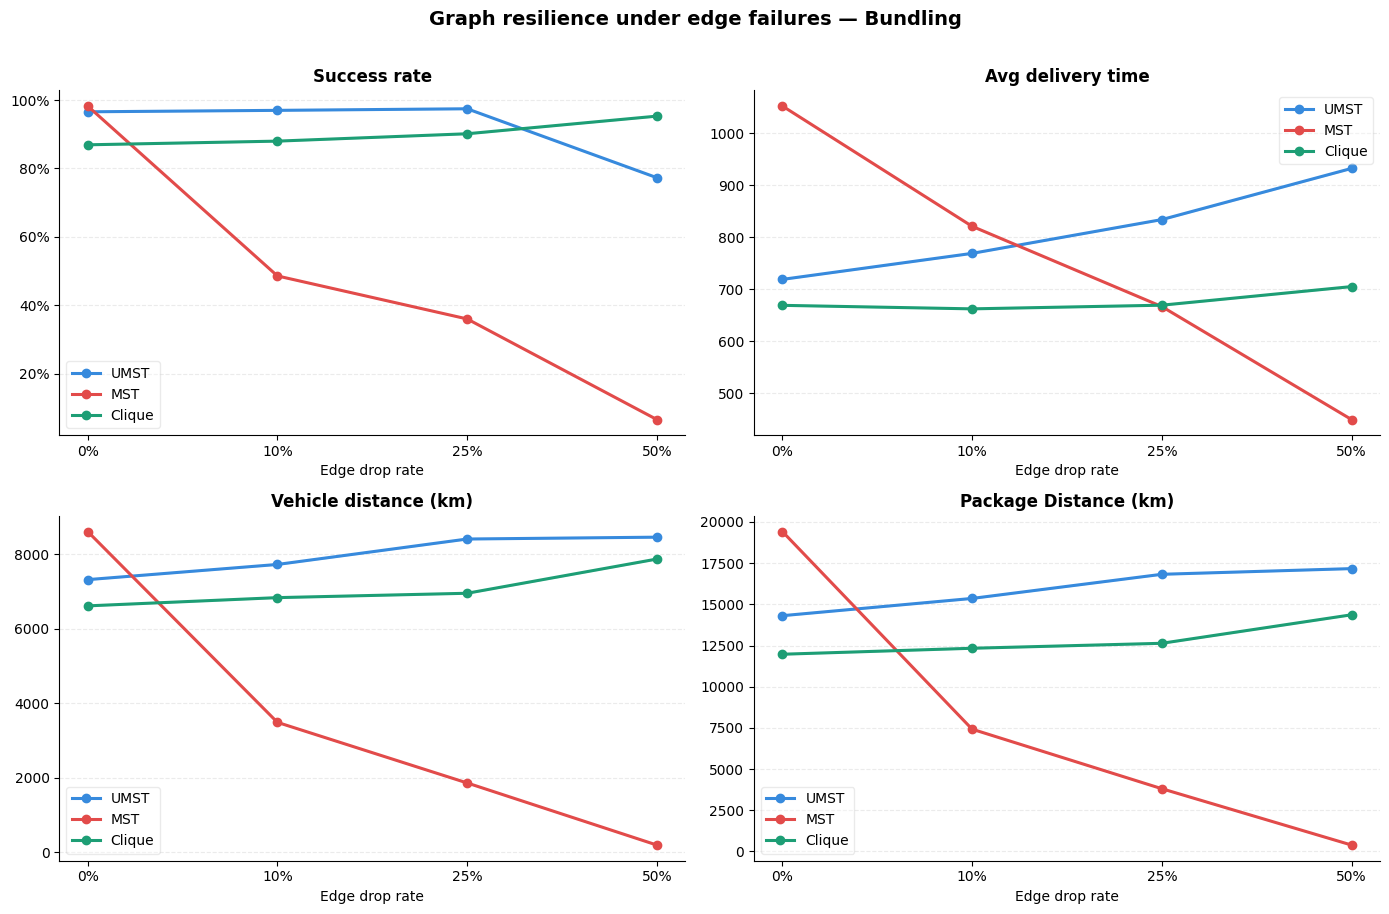

✓ Figure saved: ./gdrive/MyDrive/UMST_DeliverAI/Delivery_Data/Columbus_mini - RL Delivery Data/Results/resilience/resilience_study/resilience_results_20260408_183302/resilience_bundling_20260408_183302.png


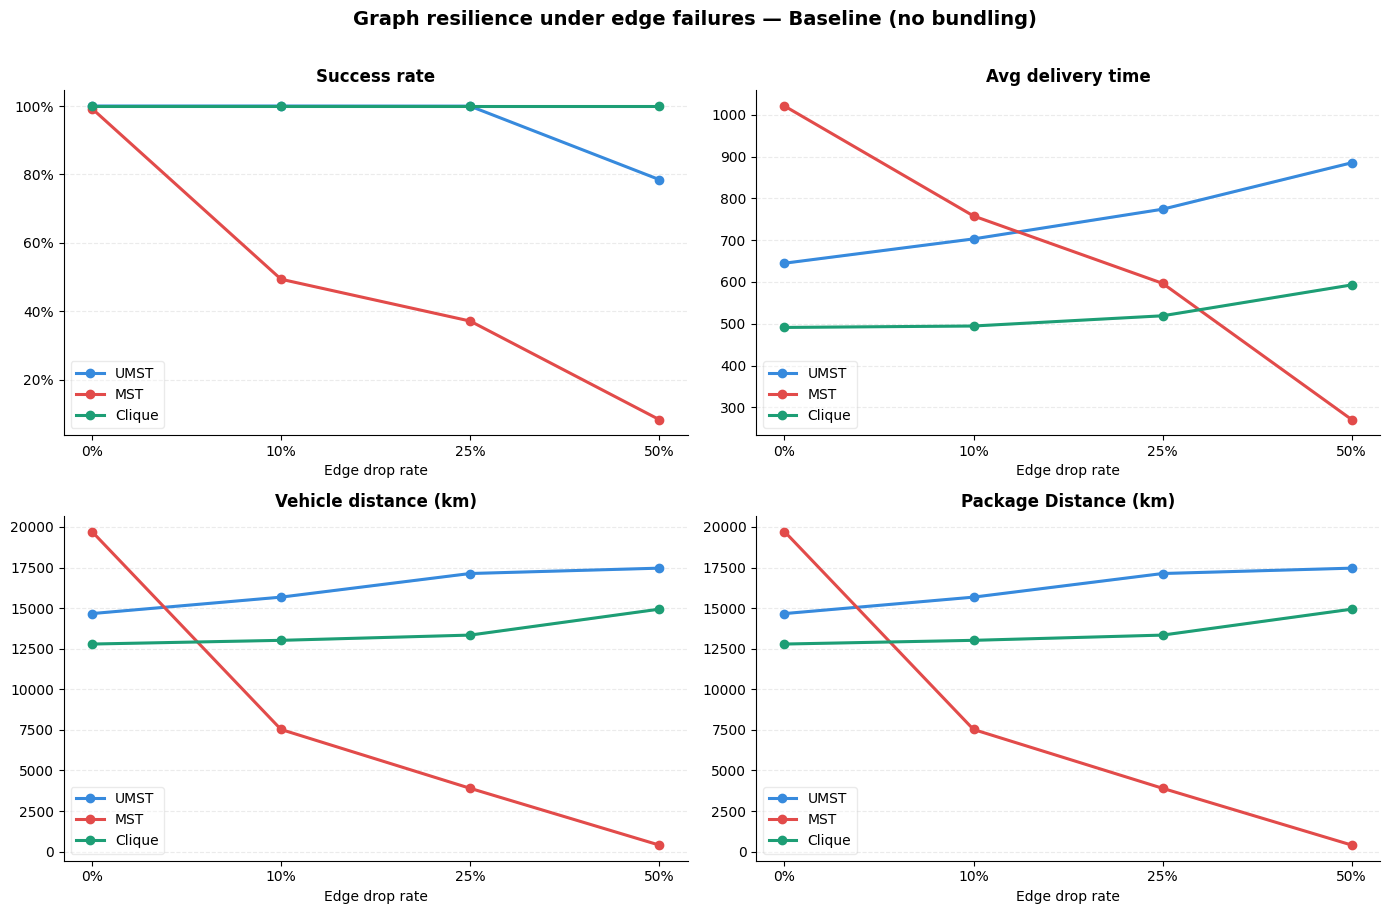

✓ Figure saved: ./gdrive/MyDrive/UMST_DeliverAI/Delivery_Data/Columbus_mini - RL Delivery Data/Results/resilience/resilience_study/resilience_results_20260408_183302/resilience_baseline_20260408_183302.png


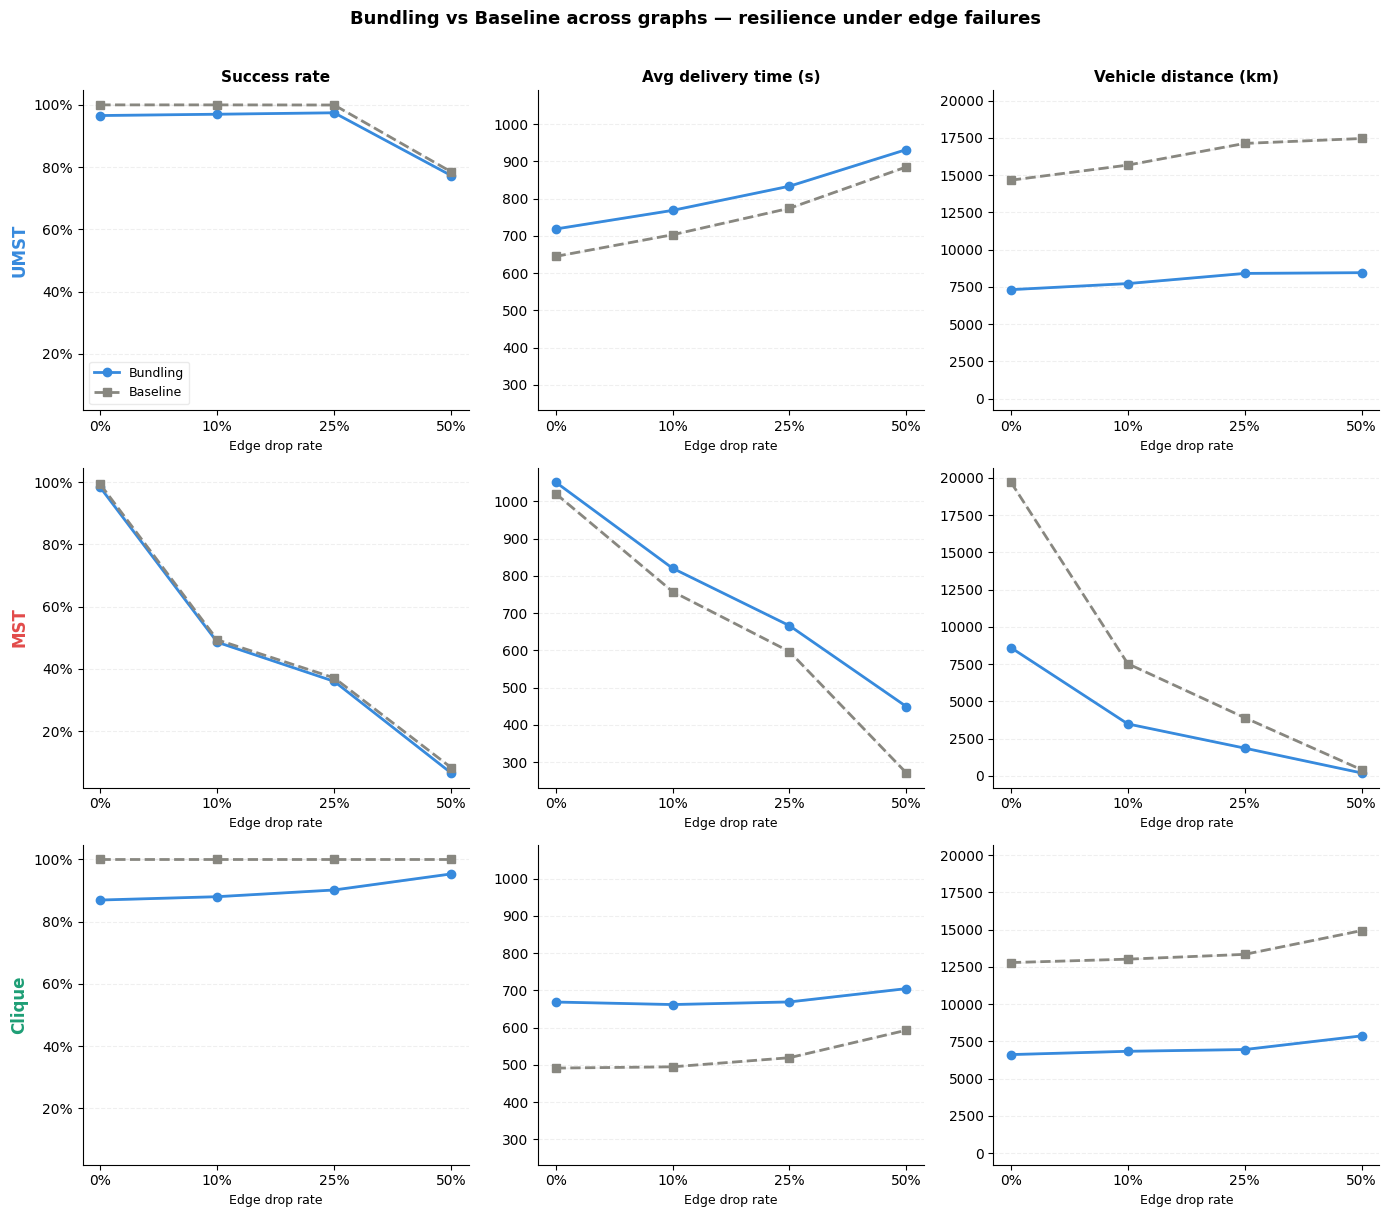

✓ Figure saved: ./gdrive/MyDrive/UMST_DeliverAI/Delivery_Data/Columbus_mini - RL Delivery Data/Results/resilience/resilience_study/resilience_results_20260408_183302/bundling_vs_baseline_per_graph_20260408_183302.png

✓ All results saved to: ./gdrive/MyDrive/UMST_DeliverAI/Delivery_Data/Columbus_mini - RL Delivery Data/Results/resilience/resilience_study/resilience_results_20260408_183302


'./gdrive/MyDrive/UMST_DeliverAI/Delivery_Data/Columbus_mini - RL Delivery Data/Results/resilience/resilience_study/resilience_results_20260408_183302'

In [ ]:
# Run experiments
all_drop_results = {}
for drop_rate in [0.0, 0.1, 0.25, 0.5]:
    comparator_dr = GraphComparator(
        delivery_params=delivery_params,
        output_dir=output_dir + f"/resilience/resilience_{int(drop_rate*100)}pct"
    )
    comparator_dr.add_graph('UMST', umst_graph)
    comparator_dr.add_graph('MST', mst_graph)
    comparator_dr.add_graph('Clique', hotspot_graph)
    # comparator_dr.add_graph('Clique_5', clique_5_graph)
    # comparator_dr.add_graph('Clique_10', clique_10_graph)
    # comparator_dr.add_graph('Clique_30', clique_30_graph)
    comparator_dr.generate_shared_deliveries()

    all_drop_results[drop_rate] = comparator_dr.run_comparison(
        sim_params, n_runs=1, grace_time=GRACE_TIME, drop_rate=drop_rate
    )

# Save everything
save_resilience_results(
    all_drop_results,
    output_dir=output_dir + "/resilience/resilience_study",
    graphs=['UMST', 'MST', 'Clique']
)

#### ── Load previously generated drop rate results ────────────────────────────

  [dr=0%] UMST ✓
  [dr=0%] MST ✓
  [dr=0%] Clique ✓
  [dr=10%] UMST ✓
  [dr=10%] MST ✓
  [dr=10%] Clique ✓
  [dr=25%] UMST ✓
  [dr=25%] MST ✓
  [dr=25%] Clique ✓
  [dr=50%] UMST ✓
  [dr=50%] MST ✓
  [dr=50%] Clique ✓
✓ JSON saved: ./gdrive/MyDrive/UMST_DeliverAI/Delivery_Data/Columbus_mini - RL Delivery Data/Results/resilience/resilience_study/resilience_results_20260408_183355/resilience_stats_20260408_183355.json
✓ CSV saved:  ./gdrive/MyDrive/UMST_DeliverAI/Delivery_Data/Columbus_mini - RL Delivery Data/Results/resilience/resilience_study/resilience_results_20260408_183355/resilience_summary_20260408_183355.csv


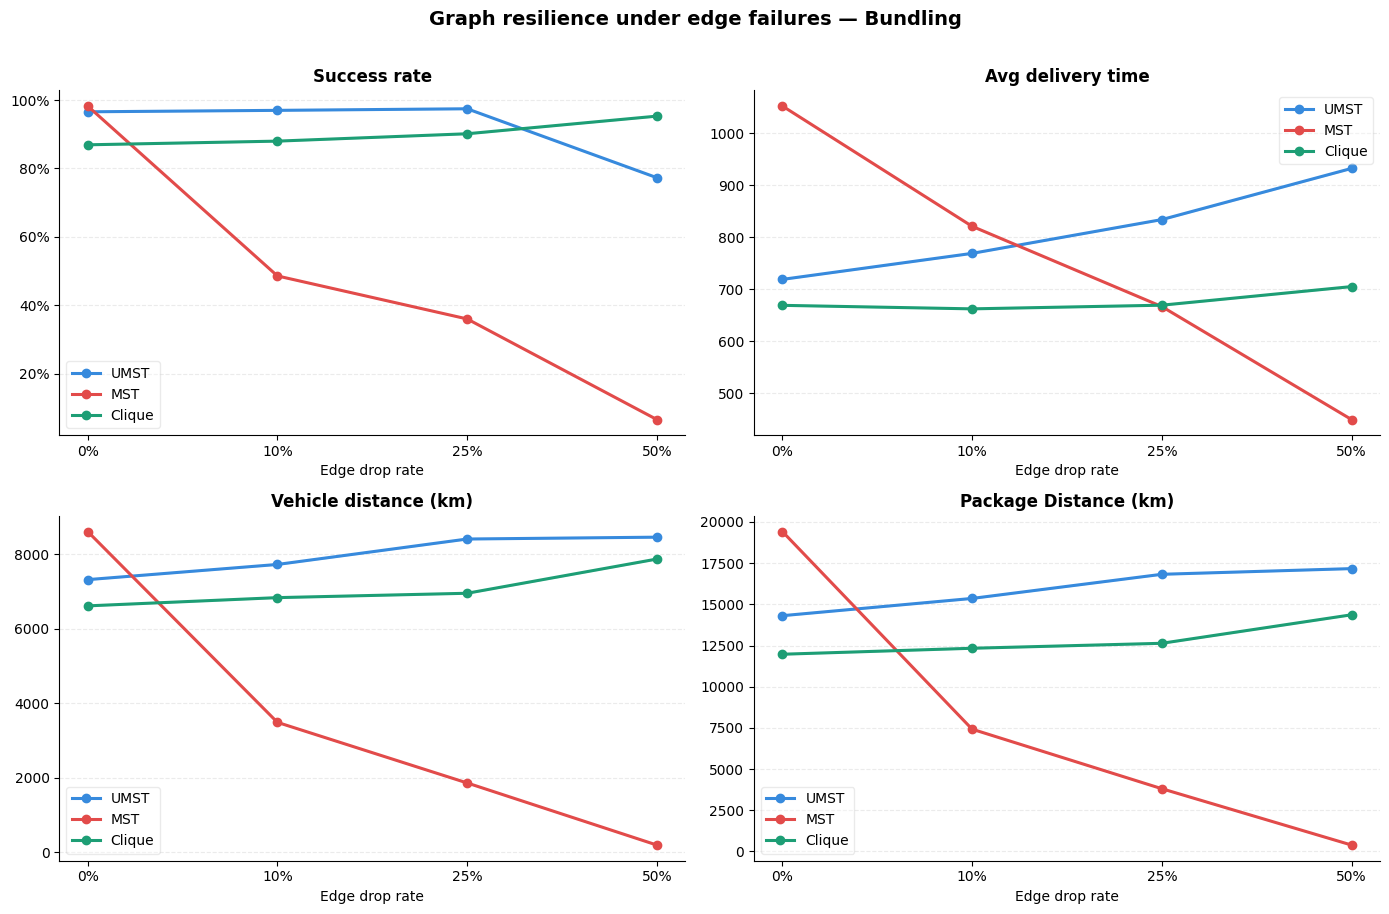

✓ Figure saved: ./gdrive/MyDrive/UMST_DeliverAI/Delivery_Data/Columbus_mini - RL Delivery Data/Results/resilience/resilience_study/resilience_results_20260408_183355/resilience_bundling_20260408_183355.png


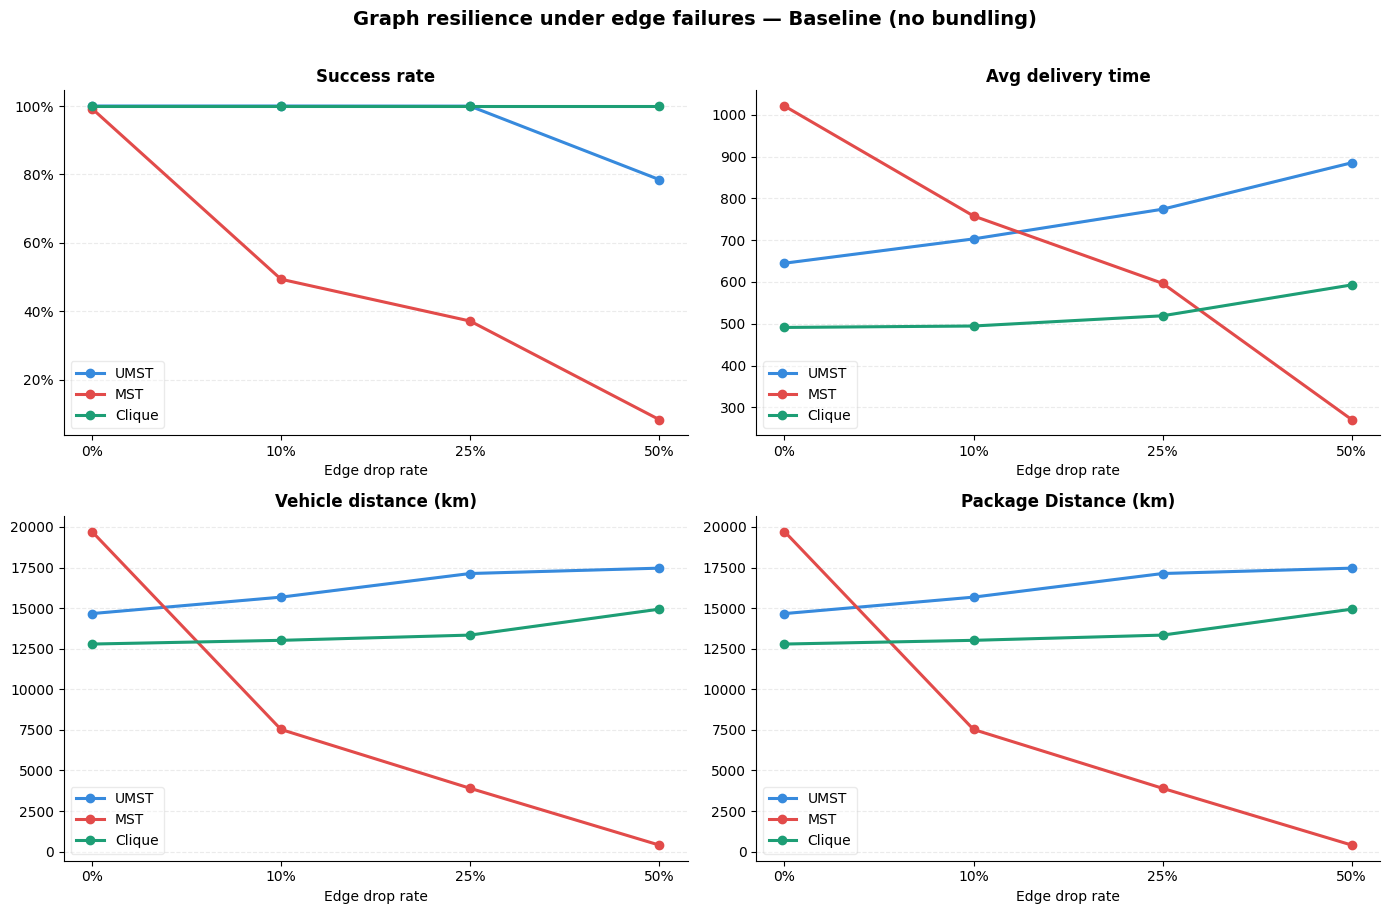

✓ Figure saved: ./gdrive/MyDrive/UMST_DeliverAI/Delivery_Data/Columbus_mini - RL Delivery Data/Results/resilience/resilience_study/resilience_results_20260408_183355/resilience_baseline_20260408_183355.png


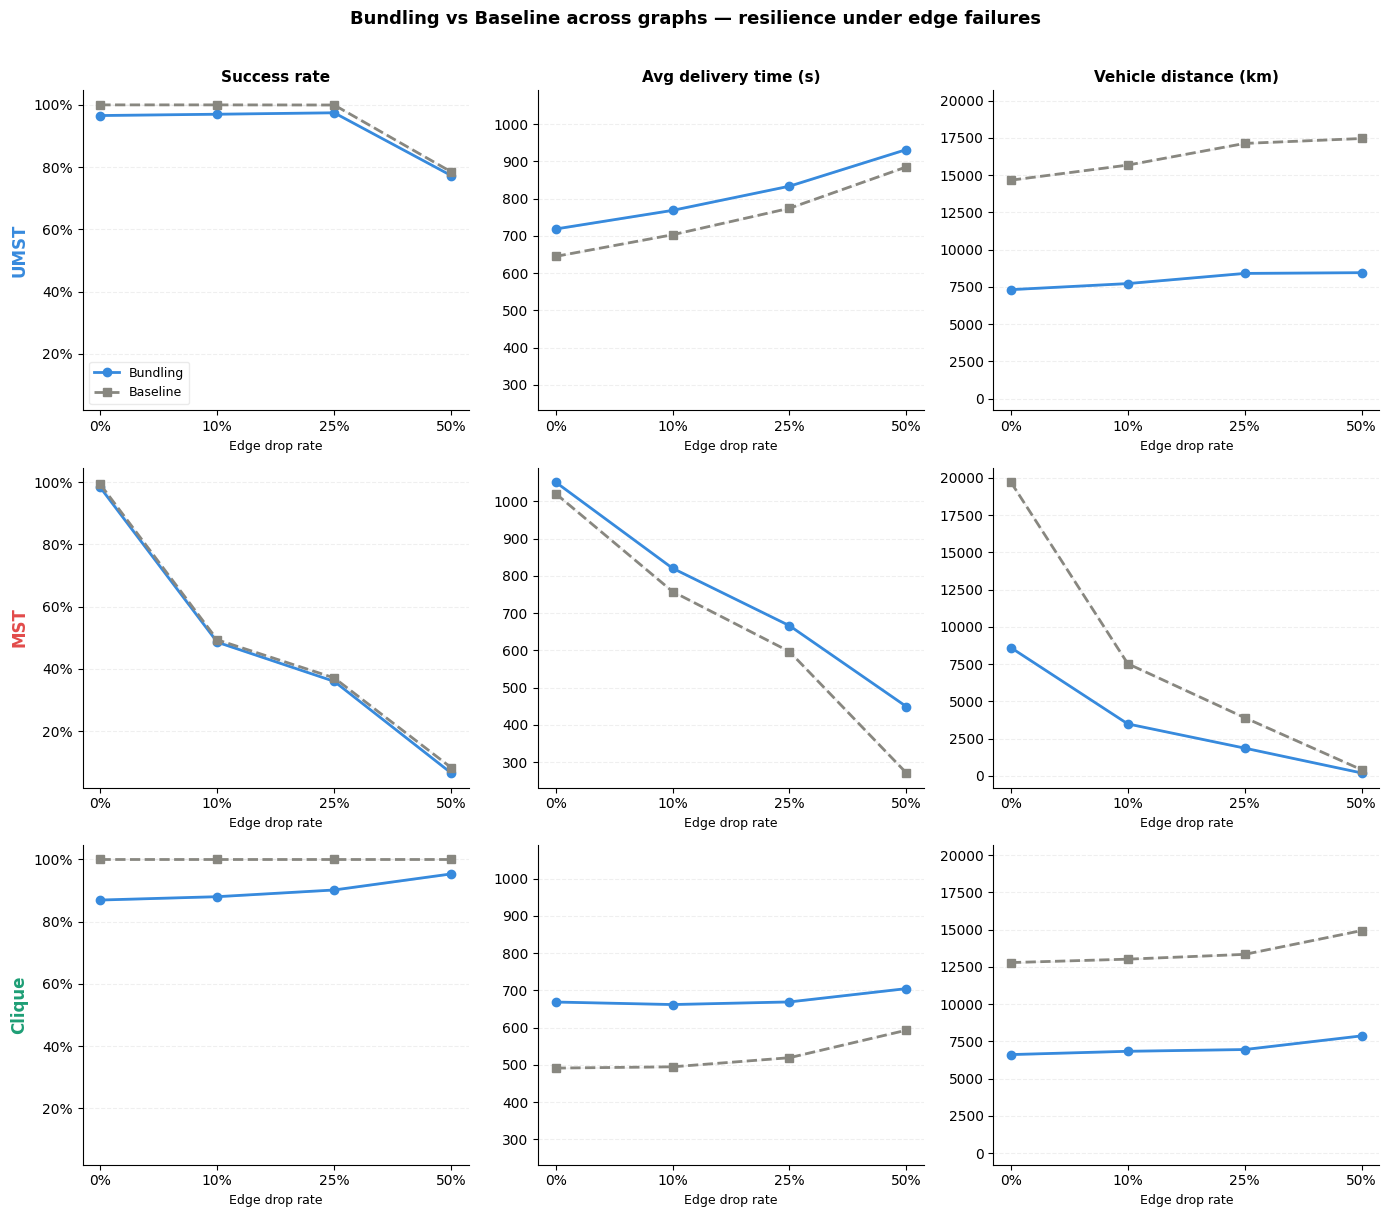

✓ Figure saved: ./gdrive/MyDrive/UMST_DeliverAI/Delivery_Data/Columbus_mini - RL Delivery Data/Results/resilience/resilience_study/resilience_results_20260408_183355/bundling_vs_baseline_per_graph_20260408_183355.png

✓ All results saved to: ./gdrive/MyDrive/UMST_DeliverAI/Delivery_Data/Columbus_mini - RL Delivery Data/Results/resilience/resilience_study/resilience_results_20260408_183355


'./gdrive/MyDrive/UMST_DeliverAI/Delivery_Data/Columbus_mini - RL Delivery Data/Results/resilience/resilience_study/resilience_results_20260408_183355'

In [ ]:
import glob
all_drop_results = {}

for drop_rate in [0.0, 0.1, 0.25, 0.5]:
    folder = output_dir + f"/resilience/resilience_{int(drop_rate*100)}pct"
    all_drop_results[drop_rate] = {}

    for graph in ['UMST', 'MST', 'Clique']:
        graph_eval_folder = os.path.join(folder, graph)
        stats_files = sorted(
            glob.glob(os.path.join(graph_eval_folder, 'statistics_*.json')),
            key=os.path.getmtime, reverse=True
        )
        if not stats_files:
            print(f"  WARNING: no statistics_*.json for {graph} at dr={drop_rate} in {graph_eval_folder}")
            continue

        with open(stats_files[0]) as f:
            stats = json.load(f)

        all_drop_results[drop_rate][graph] = {
            'bundling_stats': stats['bundling'],
            'baseline_stats': stats['baseline'],
        }
        print(f"  [dr={drop_rate:.0%}] {graph} ✓")

# ── Generate resilience_study (plots + CSVs + JSON) ───────────────────────
save_resilience_results(
    all_drop_results,
    output_dir=output_dir + "/resilience/resilience_study",
    graphs=['UMST', 'MST', 'Clique']
)

#### Option 2: Quick Compare Two Graphs

In [ ]:
# # Compare UMST vs MST
# comparator, results = quick_compare_two_graphs(
#     umst_graph, mst_graph,
#     'UMST', 'MST',
#     n_runs=5,
#     drop_rate=0.25
# )

### Break

In [ ]:
Break;;;;;

SyntaxError: invalid syntax (1918095580.py, line 1)

### Quick Test Call

In [ ]:
# Example usage:
quick_test(delivery_params=delivery_params, grace_time=1800, wait_time=2, max_bundle_size=5)

### COMPARE ALL BUFFER STRATEGIES

In [ ]:
# ============================================================
# 5. COMPARE ALL BUFFER STRATEGIES
# ============================================================

def compare_buffer_strategies(delivery_params):
    """
    Run full analysis for each buffer strategy separately.
    Helpful to understand which buffer type works best.
    """
    strategies = ['multiply', 'fixed_buffer', 'rangewise', 'randomized']
    all_results = {}

    for strategy in strategies:
        print(f"\n{'#'*80}")
        print(f"# TESTING BUFFER STRATEGY: {strategy}")
        print(f"{'#'*80}\n")

        # Parameter grid for this strategy
        param_grid_single = {
            'wait_time': [30, 45],
            'max_bundle_size': [5],
            'vehicle_cooldown': [300],
            'vehicle_change_time': [15],
            'buffer_time_type': [strategy]  # Only this strategy
        }

        # best_params, bundling_stats, baseline_stats = run_complete_analysis(
        #     deliverylist=deliverylist,
        #     adjacency_matrix=adjacency_matrix,
        #     node_positions=node_positions,
        #     num_hotspots=num_hotspots,
        #     param_grid=param_grid_single,
        #     delivery_params = delivery_params,
        #     n_tuning_runs=2,
        #     n_eval_runs=2,
        #     grace_time=600,
        #     output_base_dir=f"{data_dir}/results_{strategy}"
        # )

        best_params, bundling_stats, baseline_stats, saved_files = run_complete_analysis(
          deliverylist=deliverylist,
          adjacency_matrix=adjacency_matrix,
          node_positions=node_positions,
          num_hotspots=num_hotspots,
          delivery_params=delivery_params,
          param_grid=param_grid_tiny,
          n_tuning_runs=2,
          n_eval_runs=2,  # <-- Increase for proper std dev
          grace_time=600,
          output_base_dir=output_dir + "/simulation_results_compare_buffer",
          city_name=city_name,      # <-- PASS VARIABLE
          state_name=state_name,    # <-- PASS VARIABLE
          mini=mini                 # <-- PASS VARIABLE
      )


        all_results[strategy] = {
            'best_params': best_params,
            'bundling': bundling_stats,
            'baseline': baseline_stats
        }

    # Print comparison
    print(f"\n{'='*80}")
    print(f"BUFFER STRATEGY COMPARISON")
    print(f"{'='*80}")
    print(f"{'Strategy':<15} {'Success Rate':<20} {'Vehicle Dist':<20} {'Avg Delay':<15}")
    print("-"*80)

    for strategy, results in all_results.items():
        sr = results['bundling']['success_rate']['mean']
        vd = results['bundling']['vehicle_distance']['mean']
        ad = results['bundling']['avg_delay']['mean']
        print(f"{strategy:<15} {sr:.2%}±{results['bundling']['success_rate']['ci_95']:.2%}     "
              f"{vd:.1f}±{results['bundling']['vehicle_distance']['ci_95']:.1f}km      "
              f"{ad:.1f}±{results['bundling']['avg_delay']['ci_95']:.1f}s")

    return all_results

In [ ]:
# # Example usage:
# strategy_comparison = compare_buffer_strategies(delivery_params)

### Complete Run

In [ ]:
# Run analysis with city info
best_params, bundling_stats, baseline_stats, saved_files = run_complete_analysis(
    deliverylist=deliverylist,
    adjacency_matrix=adjacency_matrix,
    node_positions=node_positions,
    num_hotspots=num_hotspots,
    delivery_params=delivery_params,
    param_grid=param_grid_tiny,
    n_tuning_runs=1,
    n_eval_runs=5,  # 10 <-- Increase for proper std dev
    grace_time=1800,
    output_base_dir=output_dir + "/simulation_results",
    city_name=city_name,      # <-- PASS VARIABLE
    state_name=state_name,    # <-- PASS VARIABLE
    mini=mini                 # <-- PASS VARIABLE
)

### ACCESS RESULTS

In [ ]:
# # ============================================================
# # 3. ACCESS RESULTS
# # ============================================================

# print("\n" + "="*80)
# print("🏆 BEST PARAMETERS FOUND")
# print("="*80)
# print(json.dumps(best_params, indent=2))

# print("\n" + "="*80)
# print("📊 BUNDLING PERFORMANCE (n=20 runs)")
# print("="*80)
# for metric in ['success_rate', 'within_buffer_rate', 'vehicle_distance',
#                'avg_time', 'avg_delay', 'total_vehicles']:
#     stats = bundling_stats[metric]
#     print(f"{metric:25s}: {stats['mean']:.3f} ± {stats['ci_95']:.3f}")

# print("\n" + "="*80)
# print("📊 BASELINE PERFORMANCE (n=20 runs)")
# print("="*80)
# for metric in ['success_rate', 'vehicle_distance', 'avg_time', 'total_vehicles']:
#     stats = baseline_stats[metric]
#     print(f"{metric:25s}: {stats['mean']:.3f} ± {stats['ci_95']:.3f}")

# print("\n" + "="*80)
# print("💰 IMPROVEMENTS (Bundling vs Baseline)")
# print("="*80)
# improvement_distance = (baseline_stats['vehicle_distance']['mean'] -
#                        bundling_stats['vehicle_distance']['mean']) / \
#                        baseline_stats['vehicle_distance']['mean'] * 100

# improvement_vehicles = (baseline_stats['total_vehicles']['mean'] -
#                        bundling_stats['total_vehicles']['mean']) / \
#                        baseline_stats['total_vehicles']['mean'] * 100

# success_diff = (bundling_stats['success_rate']['mean'] -
#                baseline_stats['success_rate']['mean']) * 100

# print(f"Vehicle Distance Reduction: {improvement_distance:+.1f}%")
# print(f"Vehicle Count Reduction:    {improvement_vehicles:+.1f}%")
# print(f"Success Rate Change:        {success_diff:+.1f} percentage points")


### DeliverList Analysis

Total deliveries: 2600
Number of hotspots (census tracts): 26
Created mapping for 26 census tracts
Location mappings created: 26

Time Analysis:
  Simulation duration: 1 hour(s) = 60 minutes = 3600 seconds
  Deliveries with time data: 2600
  Time range: 1.00 - 3600.00 seconds
              (0.02 - 60.00 minutes)
Routes plotted in sample: 50
Total routes plotted: 2600


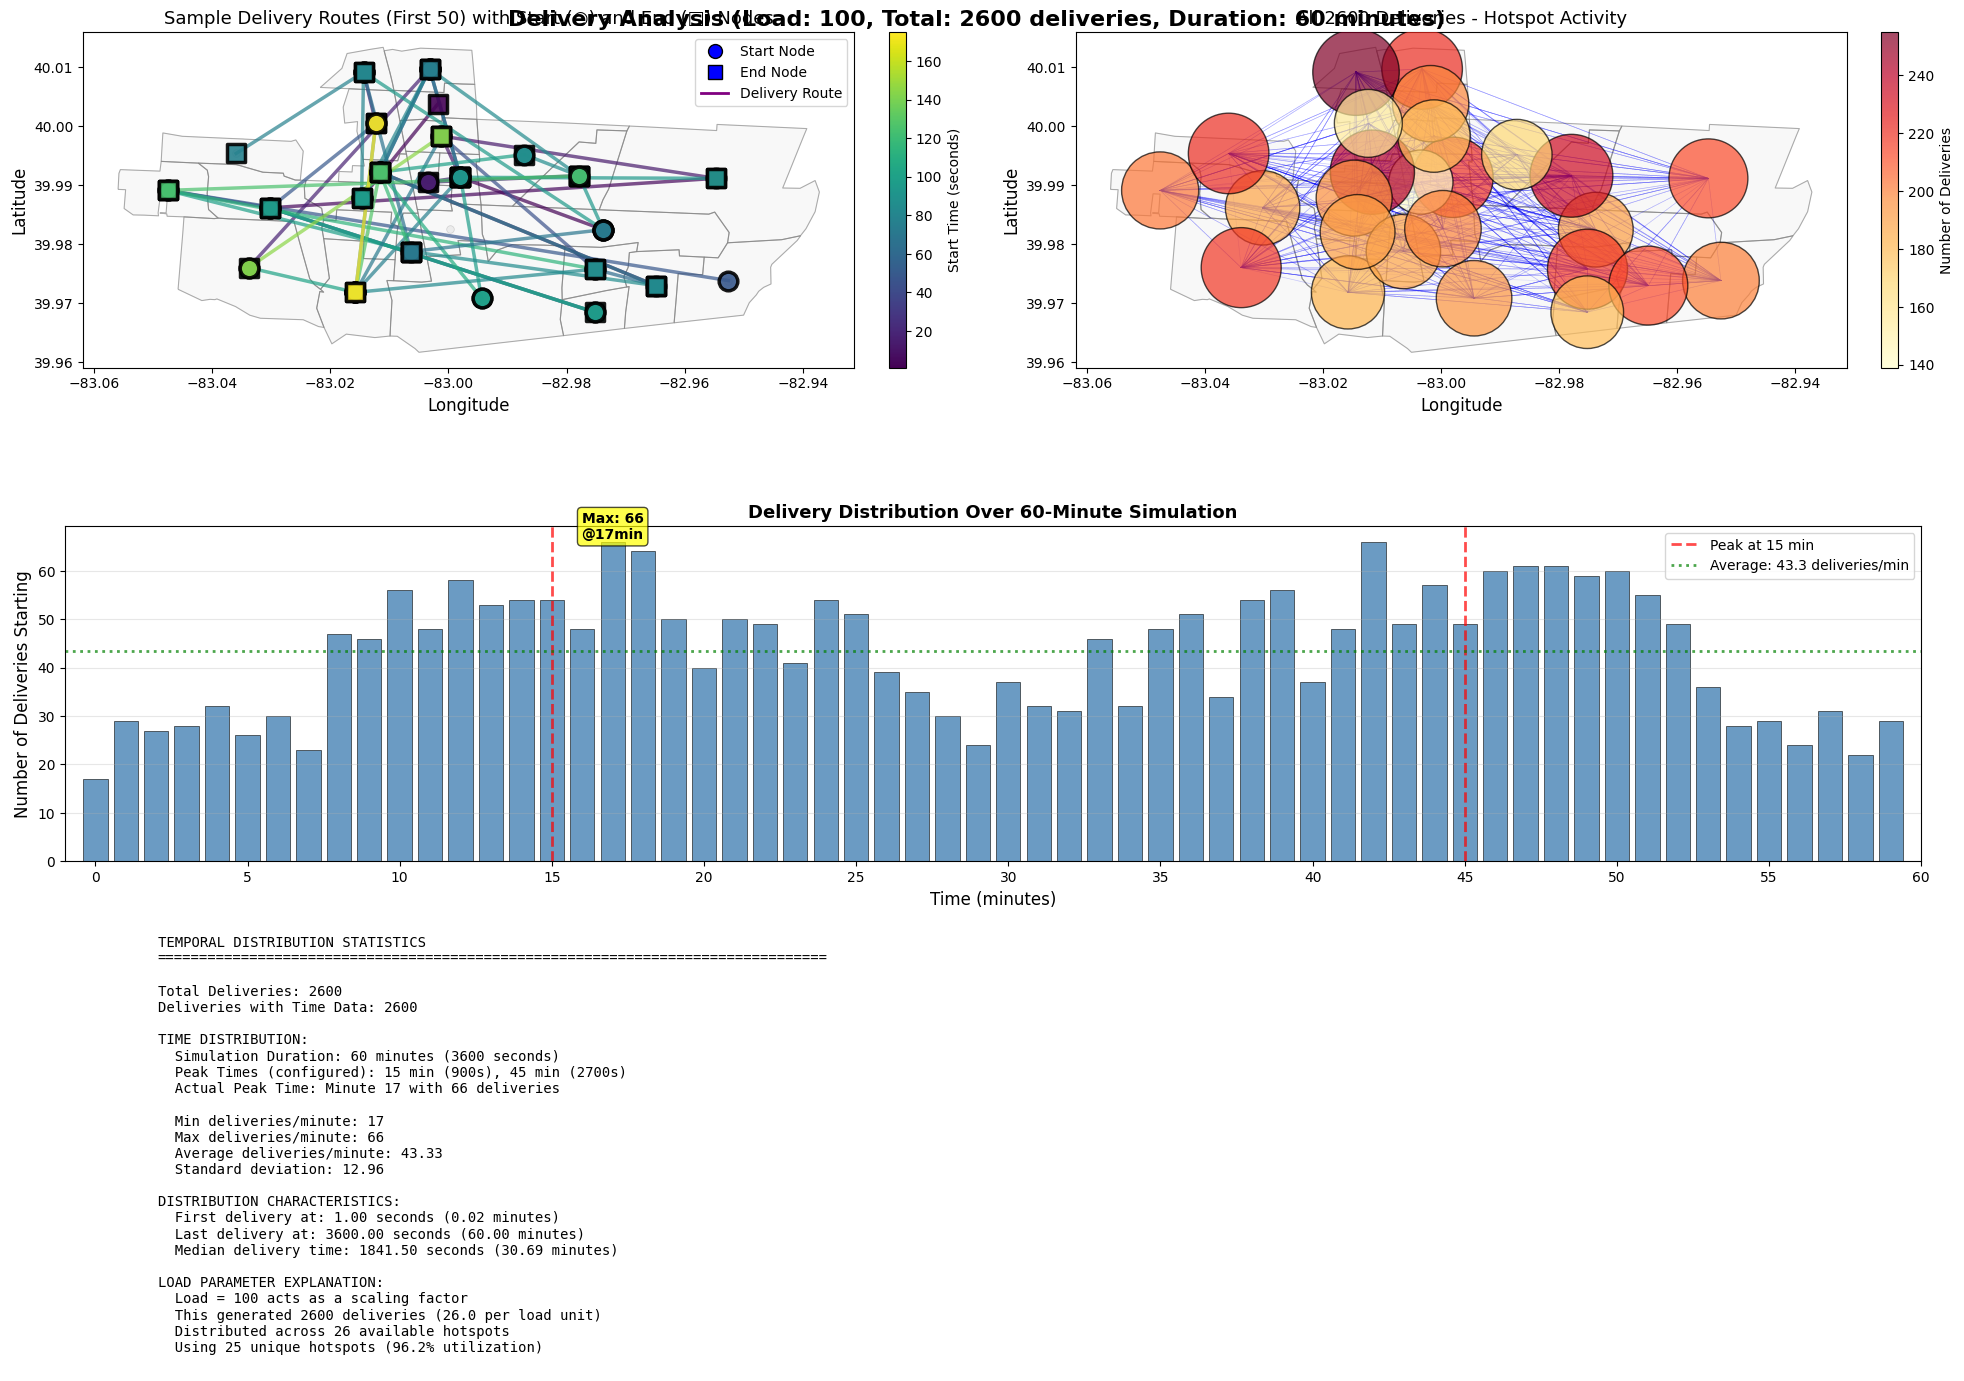


DELIVERIES PER MINUTE (First 20 minutes):
Minute     Time Range (s)       Count      Bar                           
------------------------------------------------------------
0          0-60                 17         █████████████████
1          60-120               29         █████████████████████████████
2          120-180              27         ███████████████████████████
3          180-240              28         ████████████████████████████
4          240-300              32         ████████████████████████████████
5          300-360              26         ██████████████████████████
6          360-420              30         ██████████████████████████████
7          420-480              23         ███████████████████████
8          480-540              47         ███████████████████████████████████████████████
9          540-600              46         ██████████████████████████████████████████████
10         600-660              56         ██████████████████████████████████

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.cm import viridis
from matplotlib.colors import Normalize

# Extract delivery information
deliveries = deliverylist.deliveries

print(f"Total deliveries: {len(deliveries)}")
print(f"Number of hotspots (census tracts): {num_hotspots}")

# Create index mapping dictionaries
index_to_tract = {}
tract_to_index = {}

for idx, row in census_gdf.iterrows():
    geoid = row['GEOID']
    index_to_tract[idx] = geoid
    tract_to_index[geoid] = idx

print(f"Created mapping for {len(index_to_tract)} census tracts")

# Extract delivery details
delivery_data = []
for i, delivery in enumerate(deliveries):
    data = {
        'delivery_id': i,
        'start_node': getattr(delivery, 'start_node', None),
        'end_node': getattr(delivery, 'end_node', None),
        'start_time': getattr(delivery, 'start_time', None),  # This is in seconds
        'num_shared': getattr(delivery, 'num_shared', 0) if hasattr(delivery, 'num_shared') else (len(delivery.shared) if hasattr(delivery, 'shared') and delivery.shared else 0)
    }
    delivery_data.append(data)

# Get hotspot locations using index mapping
index_to_location = {}
geoid_to_location = {}

for idx, row in census_gdf.iterrows():
    geoid = row['GEOID']
    centroid = row.geometry.centroid
    location = (centroid.x, centroid.y)

    index_to_location[idx] = location
    geoid_to_location[geoid] = location

print(f"Location mappings created: {len(index_to_location)}")

# Determine which mapping to use
def get_location(node):
    """Get location for a node, handling both index and GEOID formats"""
    if node is None:
        return None

    # Try as string (GEOID)
    node_str = str(node)
    if node_str in geoid_to_location:
        return geoid_to_location[node_str]

    # Try as integer index
    try:
        node_int = int(float(node_str))
        if node_int in index_to_location:
            return index_to_location[node_int]
        # Try mapping index to GEOID first
        if node_int in index_to_tract:
            geoid = index_to_tract[node_int]
            if geoid in geoid_to_location:
                return geoid_to_location[geoid]
    except:
        pass

    return None

# Select sample deliveries to show
num_samples = min(50, len(delivery_data))
sample_deliveries = delivery_data[:num_samples]

# === PREPARE TIME-BASED DATA (IN SECONDS) ===
# Start times are already in seconds
start_times_seconds = [d['start_time'] for d in delivery_data if d['start_time'] is not None]
start_times_minutes = [t / 60.0 for t in start_times_seconds]  # Convert seconds to minutes for display

# Simulation duration
simulation_duration_seconds = deliverylist.hours * 3600  # hours to seconds
simulation_duration_minutes = deliverylist.hours * 60  # hours to minutes

# Create bins for each minute (0-60 minutes = 0-3600 seconds)
num_minutes = int(simulation_duration_minutes)
minute_bins_seconds = np.arange(0, simulation_duration_seconds + 60, 60)  # Bins in seconds (0, 60, 120, ..., 3600)
delivery_counts, bin_edges = np.histogram(start_times_seconds, bins=minute_bins_seconds)

print(f"\nTime Analysis:")
print(f"  Simulation duration: {deliverylist.hours} hour(s) = {simulation_duration_minutes} minutes = {simulation_duration_seconds} seconds")
print(f"  Deliveries with time data: {len(start_times_seconds)}")
if start_times_seconds:
    print(f"  Time range: {min(start_times_seconds):.2f} - {max(start_times_seconds):.2f} seconds")
    print(f"              ({min(start_times_seconds)/60:.2f} - {max(start_times_seconds)/60:.2f} minutes)")

# Create visualization with 3 plots
fig = plt.figure(figsize=(20, 14))
gs = fig.add_gridspec(3, 2, height_ratios=[2, 2, 1.5])

fig.suptitle(f'Delivery Analysis (Load: {deliverylist.load}, Total: {len(deliveries)} deliveries, Duration: {num_minutes} minutes)',
             fontsize=16, fontweight='bold')

# === PLOT 1: Deliveries with Start/End Nodes Highlighted ===
ax1 = fig.add_subplot(gs[0, 0])

# Plot census tracts
if census_gdf is not None:
    census_gdf.boundary.plot(ax=ax1, color='gray', linewidth=0.8, alpha=0.6)
    census_gdf.plot(ax=ax1, color='lightgray', alpha=0.15, edgecolor='gray', linewidth=0.5)

# Plot all hotspot centroids (faded)
for idx, loc in index_to_location.items():
    ax1.scatter(loc[0], loc[1], s=30, c='lightgray', marker='o',
               edgecolors='gray', linewidths=0.5, alpha=0.3, zorder=2)

# Get start times for coloring (in seconds)
start_times_sample = [d['start_time'] for d in sample_deliveries if d['start_time'] is not None]

if start_times_sample:
    norm = Normalize(vmin=min(start_times_sample), vmax=max(start_times_sample))
    cmap = viridis

    # Plot each delivery route with colored line
    routes_plotted = 0
    for data in sample_deliveries:
        if data['start_node'] is not None and data['end_node'] is not None and data['start_time'] is not None:
            start_loc = get_location(data['start_node'])
            end_loc = get_location(data['end_node'])

            if start_loc and end_loc:
                color = cmap(norm(data['start_time']))

                # Draw route line
                ax1.plot([start_loc[0], end_loc[0]], [start_loc[1], end_loc[1]],
                        color=color, alpha=0.7, linewidth=2.5, zorder=4)

                # Mark start node (circle)
                ax1.scatter(start_loc[0], start_loc[1], s=180, c=[color],
                           marker='o', edgecolors='black', linewidths=2.5,
                           alpha=0.9, zorder=5)

                # Mark end node (square)
                ax1.scatter(end_loc[0], end_loc[1], s=180, c=[color],
                           marker='s', edgecolors='black', linewidths=2.5,
                           alpha=0.9, zorder=5)

                routes_plotted += 1

    print(f"Routes plotted in sample: {routes_plotted}")

    # Add colorbar (show in minutes for readability)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar1 = plt.colorbar(sm, ax=ax1, label='Start Time (seconds)', fraction=0.046, pad=0.04)

# Add legend for markers
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='blue',
           markeredgecolor='black', markersize=10, label='Start Node'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='blue',
           markeredgecolor='black', markersize=10, label='End Node'),
    Line2D([0], [0], color='purple', linewidth=2, label='Delivery Route')
]
ax1.legend(handles=legend_elements, loc='upper right', fontsize=10)

ax1.set_xlabel('Longitude', fontsize=12)
ax1.set_ylabel('Latitude', fontsize=12)
ax1.set_title(f'Sample Delivery Routes (First {num_samples}) with Start (○) and End (□) Nodes', fontsize=13)
ax1.set_aspect('equal', adjustable='box')

# === PLOT 2: All Deliveries Overview with Density ===
ax2 = fig.add_subplot(gs[0, 1])

# Plot census tracts
if census_gdf is not None:
    census_gdf.boundary.plot(ax=ax2, color='gray', linewidth=0.8, alpha=0.6)
    census_gdf.plot(ax=ax2, color='lightgray', alpha=0.15, edgecolor='gray', linewidth=0.5)

# Count deliveries per hotspot for all deliveries
hotspot_activity = {}
for data in delivery_data:
    if data['start_node'] is not None:
        hotspot_activity[data['start_node']] = hotspot_activity.get(data['start_node'], 0) + 1
    if data['end_node'] is not None:
        hotspot_activity[data['end_node']] = hotspot_activity.get(data['end_node'], 0) + 1

# Plot hotspots sized and colored by activity
activities = []
locs_x = []
locs_y = []

for node, count in hotspot_activity.items():
    loc = get_location(node)
    if loc:
        activities.append(count)
        locs_x.append(loc[0])
        locs_y.append(loc[1])

if activities:
    # Plot with size proportional to activity
    sizes = [50 + a * 15 for a in activities]
    scatter = ax2.scatter(locs_x, locs_y, s=sizes, c=activities,
                         cmap='YlOrRd', edgecolors='black', linewidths=1,
                         alpha=0.7, zorder=5)

    # Add colorbar
    cbar2 = plt.colorbar(scatter, ax=ax2, label='Number of Deliveries',
                        fraction=0.046, pad=0.04)

# Plot all delivery routes (faded)
routes_total = 0
for data in delivery_data:
    if data['start_node'] is not None and data['end_node'] is not None:
        start_loc = get_location(data['start_node'])
        end_loc = get_location(data['end_node'])
        if start_loc and end_loc:
            ax2.plot([start_loc[0], end_loc[0]], [start_loc[1], end_loc[1]],
                    'b-', alpha=0.05, linewidth=0.5, zorder=2)
            routes_total += 1

print(f"Total routes plotted: {routes_total}")

ax2.set_xlabel('Longitude', fontsize=12)
ax2.set_ylabel('Latitude', fontsize=12)
ax2.set_title(f'All {len(deliveries)} Deliveries - Hotspot Activity', fontsize=13)
ax2.set_aspect('equal', adjustable='box')

# === PLOT 3: Bar Chart - Deliveries per Minute ===
ax3 = fig.add_subplot(gs[1, :])

# Create bar chart (x-axis in minutes, but data binned from seconds)
minutes = np.arange(0, num_minutes)
bars = ax3.bar(minutes, delivery_counts, color='steelblue', edgecolor='black',
               linewidth=0.5, alpha=0.8)

# Highlight peak periods (peaks are in hours, convert to minutes)
# peaks=[0.25, 0.75] means 0.25*60=15 min and 0.75*60=45 min
peak_minutes = [p * 60 for p in deliverylist.peaks]
for peak_min in peak_minutes:
    if 0 <= peak_min < num_minutes:
        ax3.axvline(peak_min, color='red', linestyle='--', linewidth=2,
                   alpha=0.7, label=f'Peak at {peak_min:.0f} min' if peak_min == peak_minutes[0] else '')

# Add statistics
if len(delivery_counts) > 0:
    max_count = max(delivery_counts)
    max_minute = minutes[np.argmax(delivery_counts)]
    avg_count = np.mean(delivery_counts)

    ax3.axhline(avg_count, color='green', linestyle=':', linewidth=2,
               alpha=0.7, label=f'Average: {avg_count:.1f} deliveries/min')

    # Annotations
    ax3.text(max_minute, max_count, f'Max: {int(max_count)}\n@{int(max_minute)}min',
            ha='center', va='bottom', fontsize=10, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

ax3.set_xlabel('Time (minutes)', fontsize=12)
ax3.set_ylabel('Number of Deliveries Starting', fontsize=12)
ax3.set_title(f'Delivery Distribution Over {num_minutes}-Minute Simulation', fontsize=13, fontweight='bold')
ax3.set_xlim(-1, num_minutes)
ax3.set_xticks(np.arange(0, num_minutes + 1, 5))
ax3.grid(True, alpha=0.3, axis='y')
ax3.legend(loc='upper right', fontsize=10)

# === PLOT 4: Statistics Summary ===
ax4 = fig.add_subplot(gs[2, :])

# Calculate time-based statistics
if start_times_seconds and len(delivery_counts) > 0:
    time_stats = f"""
TEMPORAL DISTRIBUTION STATISTICS
{'='*80}

Total Deliveries: {len(deliveries)}
Deliveries with Time Data: {len(start_times_seconds)}

TIME DISTRIBUTION:
  Simulation Duration: {simulation_duration_minutes:.0f} minutes ({simulation_duration_seconds:.0f} seconds)
  Peak Times (configured): {', '.join([f'{p*60:.0f} min ({p*3600:.0f}s)' for p in deliverylist.peaks])}
  Actual Peak Time: Minute {int(max_minute)} with {int(max_count)} deliveries

  Min deliveries/minute: {int(min(delivery_counts))}
  Max deliveries/minute: {int(max_count)}
  Average deliveries/minute: {avg_count:.2f}
  Standard deviation: {np.std(delivery_counts):.2f}

DISTRIBUTION CHARACTERISTICS:
  First delivery at: {min(start_times_seconds):.2f} seconds ({min(start_times_seconds)/60:.2f} minutes)
  Last delivery at: {max(start_times_seconds):.2f} seconds ({max(start_times_seconds)/60:.2f} minutes)
  Median delivery time: {np.median(start_times_seconds):.2f} seconds ({np.median(start_times_seconds)/60:.2f} minutes)

LOAD PARAMETER EXPLANATION:
  Load = {deliverylist.load} acts as a scaling factor
  This generated {len(deliveries)} deliveries ({len(deliveries) / deliverylist.load:.1f} per load unit)
  Distributed across {num_hotspots} available hotspots
  Using {len(set([d['start_node'] for d in delivery_data if d['start_node']] + [d['end_node'] for d in delivery_data if d['end_node']]))} unique hotspots ({len(set([d['start_node'] for d in delivery_data if d['start_node']] + [d['end_node'] for d in delivery_data if d['end_node']]))/num_hotspots*100:.1f}% utilization)
"""
else:
    time_stats = "No time data available"

ax4.text(0.05, 0.5, time_stats, fontsize=10, family='monospace',
        verticalalignment='center', transform=ax4.transAxes)
ax4.axis('off')

plt.tight_layout()
plt.show()

# Print minute-by-minute breakdown for first 20 minutes
print("\n" + "="*60)
print("DELIVERIES PER MINUTE (First 20 minutes):")
print("="*60)
print(f"{'Minute':<10} {'Time Range (s)':<20} {'Count':<10} {'Bar':<30}")
print("-"*60)
for i in range(min(20, len(delivery_counts))):
    time_range = f"{i*60}-{(i+1)*60}"
    bar = '█' * int(delivery_counts[i])
    print(f"{i:<10} {time_range:<20} {int(delivery_counts[i]):<10} {bar}")

print(f"\n... Total across all {num_minutes} minutes: {int(sum(delivery_counts))} deliveries")

# Print sample deliveries with time in seconds
print("\n" + "="*100)
print(f"SAMPLE DELIVERIES (First 10):")
print("="*100)
print(f"{'ID':<5} {'Start Node':<12} {'End Node':<12} {'Start Time (s)':<15} {'Start Time (min)':<15} {'Shared':<8}")
print("-"*100)

for i, data in enumerate(delivery_data[:10]):
    start_node = str(data['start_node']) if data['start_node'] is not None else "N/A"
    end_node = str(data['end_node']) if data['end_node'] is not None else "N/A"
    start_time_s = f"{data['start_time']:.2f}" if data['start_time'] is not None else "N/A"
    start_time_m = f"{data['start_time']/60:.2f}" if data['start_time'] is not None else "N/A"

    print(f"{i+1:<5} {start_node:<12} {end_node:<12} {start_time_s:<15} {start_time_m:<15} {data['num_shared']:<8}")

### Multi-UMST Comparison System

#### MultiUMSTComparator Class

In [ ]:
import os
import json
import numpy as np
import networkx as nx
from datetime import datetime
from itertools import product
import matplotlib.pyplot as plt
import seaborn as sns

class MultiUMSTComparator:
    """
    Compare multiple UMST configurations against MST and Clique graphs
    """

    def __init__(self, hotspot_graph, delivery_params, output_base_dir):
        """
        Initialize the comparator

        Parameters:
        -----------
        hotspot_graph : networkx.Graph
            The base clique/hotspot graph
        delivery_params : dict
            Delivery generation parameters
        output_base_dir : str
            Base directory for all outputs (will be replaced if exists)
        """
        self.hotspot_graph = hotspot_graph
        self.delivery_params = delivery_params
        self.output_dir = output_base_dir

        # Remove existing directory if it exists
        if os.path.exists(self.output_dir):
            import shutil
            print(f"Removing existing directory: {self.output_dir}")
            shutil.rmtree(self.output_dir)

        # Create fresh output directory
        os.makedirs(self.output_dir, exist_ok=True)

        # Subdirectories
        self.graphs_dir = os.path.join(self.output_dir, "graphs")
        self.results_dir = os.path.join(self.output_dir, "results")
        self.viz_dir = os.path.join(self.output_dir, "visualizations")

        for dir_path in [self.graphs_dir, self.results_dir, self.viz_dir]:
            os.makedirs(dir_path, exist_ok=True)

        # Storage for results
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        self.all_results = {
            'metadata': {
                'timestamp': timestamp,
                'base_graph_nodes': hotspot_graph.number_of_nodes(),
                'base_graph_edges': hotspot_graph.number_of_edges(),
                'delivery_params': delivery_params
            },
            'baseline_graphs': {},
            'umst_configurations': {},
            'comparison_results': {}
        }

        # Generate baseline graphs (MST and Clique)
        self._generate_baseline_graphs()

    def _generate_baseline_graphs(self):
        """Generate and save MST and Clique baseline graphs"""
        print("Generating baseline graphs...")

        # MST
        self.mst_graph = nx.minimum_spanning_tree(self.hotspot_graph, weight="distance")

        # Save baseline graphs (only once)
        self._save_graph(self.hotspot_graph, "clique_graph")
        self._save_graph(self.mst_graph, "mst_graph")

        # Store baseline metadata
        self.all_results['baseline_graphs'] = {
            'clique': {
                'nodes': self.hotspot_graph.number_of_nodes(),
                'edges': self.hotspot_graph.number_of_edges(),
                'avg_degree': np.mean([d for n, d in self.hotspot_graph.degree()])
            },
            'mst': {
                'nodes': self.mst_graph.number_of_nodes(),
                'edges': self.mst_graph.number_of_edges(),
                'avg_degree': np.mean([d for n, d in self.mst_graph.degree()]),
                'total_distance': sum(self.mst_graph[u][v]['distance']
                                     for u, v in self.mst_graph.edges())
            }
        }

        print(f"✓ Clique: {self.hotspot_graph.number_of_nodes()} nodes, "
              f"{self.hotspot_graph.number_of_edges()} edges")
        print(f"✓ MST: {self.mst_graph.number_of_nodes()} nodes, "
              f"{self.mst_graph.number_of_edges()} edges")

    def _save_graph(self, graph, name):
        """Save graph in GraphML format"""
        G_clean = graph.copy()

        # Convert coordinates and remove unsupported attributes
        for node in G_clean.nodes():
            if 'coordinates' in G_clean.nodes[node]:
                lat, lon = G_clean.nodes[node]['coordinates']
                G_clean.nodes[node]['lat'] = float(lat)
                G_clean.nodes[node]['lon'] = float(lon)
                del G_clean.nodes[node]['coordinates']

            if 'geometry' in G_clean.nodes[node]:
                del G_clean.nodes[node]['geometry']

        filepath = os.path.join(self.graphs_dir, f"{name}.graphml")
        nx.write_graphml(G_clean, filepath)
        return filepath

    def generate_umst_configurations(self, mst_counts, drop_percentages, random_seed=42):
        """
        Generate multiple UMST configurations

        Parameters:
        -----------
        mst_counts : list
            List of MST counts to try (e.g., [10, 20, 40, 100])
        drop_percentages : list
            List of drop percentages (e.g., [0.1, 0.2, 0.5, 0.7])
        random_seed : int
            Random seed for reproducibility
        """
        print("\n" + "="*60)
        print("GENERATING UMST CONFIGURATIONS")
        print("="*60)

        total_configs = len(mst_counts) * len(drop_percentages)
        current = 0

        for num_mst, drop_perc in product(mst_counts, drop_percentages):
            current += 1
            config_name = f"umst_m{num_mst}_d{int(drop_perc*100)}"

            print(f"\n[{current}/{total_configs}] Generating {config_name}...")
            print(f"  MSTs: {num_mst}, Drop: {drop_perc*100}%")

            try:
                # Calculate UMST
                umst_graph, mst_collection, edge_frequencies = calculate_umst(
                    self.hotspot_graph,
                    num_iterations=num_mst,
                    drop_percentage=drop_perc,
                    random_seed=random_seed
                )

                if umst_graph is None:
                    print(f"  ✗ Failed - graph became disconnected")
                    continue

                # Save UMST graph
                graph_path = self._save_graph(umst_graph, config_name)

                # Store configuration results
                self.all_results['umst_configurations'][config_name] = {
                    'parameters': {
                        'num_mst': num_mst,
                        'drop_percentage': drop_perc,
                        'random_seed': random_seed
                    },
                    'graph_stats': {
                        'nodes': umst_graph.number_of_nodes(),
                        'edges': umst_graph.number_of_edges(),
                        'avg_degree': np.mean([d for n, d in umst_graph.degree()]),
                        'total_distance': sum(umst_graph[u][v]['distance']
                                             for u, v in umst_graph.edges())
                    },
                    'edge_frequency_stats': {
                        'mean': float(np.mean(list(edge_frequencies.values()))),
                        'std': float(np.std(list(edge_frequencies.values()))),
                        'min': float(np.min(list(edge_frequencies.values()))),
                        'max': float(np.max(list(edge_frequencies.values())))
                    },
                    'mst_collection_stats': {
                        'num_msts': len(mst_collection),
                        'avg_edges_per_mst': np.mean([mst.number_of_edges()
                                                      for mst in mst_collection]),
                        'avg_distance_per_mst': np.mean([
                            sum(mst[u][v]['distance'] for u, v in mst.edges())
                            for mst in mst_collection
                        ])
                    },
                    'graph_file': os.path.basename(graph_path)
                }

                print(f"  ✓ Success: {umst_graph.number_of_edges()} edges, "
                      f"avg degree {np.mean([d for n, d in umst_graph.degree()]):.2f}")

            except Exception as e:
                print(f"  ✗ Error: {str(e)}")
                continue

        print(f"\n✓ Generated {len(self.all_results['umst_configurations'])} "
              f"UMST configurations out of {total_configs} attempted")

        # Save intermediate results
        self._save_results()

    def run_simulation_comparison(self, sim_params, n_runs=5, grace_time=1800):
        """
        Run delivery simulations on all graphs and compare

        Parameters:
        -----------
        sim_params : dict
            Simulation parameters (wait_time, max_bundle_size, etc.)
        n_runs : int
            Number of simulation runs per graph
        grace_time : int
            Grace time for simulation
        """
        print("\n" + "="*60)
        print("RUNNING SIMULATION COMPARISONS")
        print("="*60)

        # Create comparator
        comparator = GraphComparator(
            delivery_params=self.delivery_params,
            output_dir=os.path.join(self.output_dir, "sim_results")
        )

        # Add baseline graphs
        comparator.add_graph('Clique', self.hotspot_graph)
        comparator.add_graph('MST', self.mst_graph)

        # Add all UMST configurations
        for config_name in self.all_results['umst_configurations'].keys():
            graph_file = os.path.join(
                self.graphs_dir,
                f"{config_name}.graphml"
            )
            umst_graph = nx.read_graphml(graph_file)
            comparator.add_graph(config_name, umst_graph)

        # Generate shared deliveries (same for all graphs)
        print("\nGenerating shared deliveries...")
        comparator.generate_shared_deliveries()

        # Run comparison
        print(f"\nRunning {n_runs} simulation runs per graph...")
        results = comparator.run_comparison(sim_params, n_runs=n_runs, grace_time=grace_time)

        # Store comparison results
        self.all_results['comparison_results'] = {
            'simulation_params': sim_params,
            'n_runs': n_runs,
            'grace_time': grace_time,
            'results': results
        }

        # Save final results
        self._save_results()

        return results

    def _save_results(self):
        """Save all results to JSON file"""
        results_file = os.path.join(self.results_dir, "all_results.json")

        # Convert numpy types to native Python types for JSON serialization
        def convert_types(obj):
            if isinstance(obj, np.integer):
                return int(obj)
            elif isinstance(obj, np.floating):
                return float(obj)
            elif isinstance(obj, np.ndarray):
                return obj.tolist()
            elif isinstance(obj, dict):
                return {k: convert_types(v) for k, v in obj.items()}
            elif isinstance(obj, list):
                return [convert_types(v) for v in obj]
            return obj

        results_clean = convert_types(self.all_results)

        with open(results_file, 'w') as f:
            json.dump(results_clean, f, indent=2)

        print(f"\n✓ Results saved to: {results_file}")

    def create_summary_visualizations(self):
        """Create summary visualizations of all configurations"""
        print("\n" + "="*60)
        print("CREATING SUMMARY VISUALIZATIONS")
        print("="*60)

        if not self.all_results['umst_configurations']:
            print("No UMST configurations to visualize")
            return

        # Extract data for visualization
        configs = []
        for name, data in self.all_results['umst_configurations'].items():
            configs.append({
                'name': name,
                'num_mst': data['parameters']['num_mst'],
                'drop_perc': data['parameters']['drop_percentage'],
                'edges': data['graph_stats']['edges'],
                'avg_degree': data['graph_stats']['avg_degree'],
                'total_distance': data['graph_stats']['total_distance'],
                'edge_freq_mean': data['edge_frequency_stats']['mean']
            })

        # Create figure with subplots
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))
        fig.suptitle('UMST Configuration Comparison', fontsize=16, fontweight='bold')

        # Plot 1: Edge count vs MST count by drop percentage
        ax = axes[0, 0]
        for drop_perc in sorted(set(c['drop_perc'] for c in configs)):
            subset = [c for c in configs if c['drop_perc'] == drop_perc]
            x = [c['num_mst'] for c in subset]
            y = [c['edges'] for c in subset]
            ax.plot(x, y, marker='o', label=f'Drop {drop_perc*100}%', linewidth=2)

        ax.axhline(y=self.all_results['baseline_graphs']['mst']['edges'],
                   color='red', linestyle='--', label='MST', linewidth=2)
        ax.axhline(y=self.all_results['baseline_graphs']['clique']['edges'],
                   color='green', linestyle='--', label='Clique', linewidth=2)
        ax.set_xlabel('Number of MSTs', fontsize=12)
        ax.set_ylabel('Number of Edges', fontsize=12)
        ax.set_title('Edge Count vs MST Count', fontsize=14, fontweight='bold')
        ax.legend()
        ax.grid(True, alpha=0.3)

        # Plot 2: Average degree vs drop percentage
        ax = axes[0, 1]
        for num_mst in sorted(set(c['num_mst'] for c in configs)):
            subset = [c for c in configs if c['num_mst'] == num_mst]
            x = [c['drop_perc']*100 for c in subset]
            y = [c['avg_degree'] for c in subset]
            ax.plot(x, y, marker='s', label=f'{num_mst} MSTs', linewidth=2)

        ax.axhline(y=self.all_results['baseline_graphs']['mst']['avg_degree'],
                   color='red', linestyle='--', label='MST', linewidth=2)
        ax.set_xlabel('Drop Percentage (%)', fontsize=12)
        ax.set_ylabel('Average Degree', fontsize=12)
        ax.set_title('Average Degree vs Drop Percentage', fontsize=14, fontweight='bold')
        ax.legend()
        ax.grid(True, alpha=0.3)

        # Plot 3: Total distance comparison
        ax = axes[1, 0]
        config_names = [c['name'] for c in configs]
        distances = [c['total_distance'] for c in configs]
        colors = plt.cm.viridis(np.linspace(0, 1, len(configs)))

        bars = ax.barh(range(len(configs)), distances, color=colors)
        ax.axvline(x=self.all_results['baseline_graphs']['mst']['total_distance'],
                   color='red', linestyle='--', label='MST', linewidth=2)
        ax.set_yticks(range(len(configs)))
        ax.set_yticklabels(config_names, fontsize=8)
        ax.set_xlabel('Total Distance', fontsize=12)
        ax.set_title('Total Network Distance by Configuration', fontsize=14, fontweight='bold')
        ax.legend()
        ax.grid(True, alpha=0.3, axis='x')

        # Plot 4: Heatmap of edge count by parameters
        ax = axes[1, 1]
        pivot_data = {}
        for c in configs:
            key = (c['num_mst'], c['drop_perc'])
            pivot_data[key] = c['edges']

        mst_counts = sorted(set(c['num_mst'] for c in configs))
        drop_percs = sorted(set(c['drop_perc'] for c in configs))

        heatmap_data = np.zeros((len(drop_percs), len(mst_counts)))
        for i, drop in enumerate(drop_percs):
            for j, mst in enumerate(mst_counts):
                heatmap_data[i, j] = pivot_data.get((mst, drop), np.nan)

        im = ax.imshow(heatmap_data, cmap='YlOrRd', aspect='auto')
        ax.set_xticks(range(len(mst_counts)))
        ax.set_yticks(range(len(drop_percs)))
        ax.set_xticklabels(mst_counts)
        ax.set_yticklabels([f'{d*100:.0f}%' for d in drop_percs])
        ax.set_xlabel('Number of MSTs', fontsize=12)
        ax.set_ylabel('Drop Percentage', fontsize=12)
        ax.set_title('Edge Count Heatmap', fontsize=14, fontweight='bold')

        # Add colorbar
        cbar = plt.colorbar(im, ax=ax)
        cbar.set_label('Number of Edges', rotation=270, labelpad=20)

        # Add text annotations
        for i in range(len(drop_percs)):
            for j in range(len(mst_counts)):
                text = ax.text(j, i, f'{heatmap_data[i, j]:.0f}',
                             ha="center", va="center", color="black", fontsize=9)

        plt.tight_layout()

        # Save figure
        viz_file = os.path.join(self.viz_dir, "configuration_summary.png")
        plt.savefig(viz_file, dpi=300, bbox_inches='tight')
        print(f"✓ Summary visualization saved to: {viz_file}")
        plt.close()

    def print_summary(self):
        """Print a summary of all results"""
        print("\n" + "="*60)
        print("COMPARISON SUMMARY")
        print("="*60)

        print(f"\nOutput Directory: {self.output_dir}")
        print(f"\nBaseline Graphs:")
        print(f"  Clique: {self.all_results['baseline_graphs']['clique']['edges']} edges")
        print(f"  MST: {self.all_results['baseline_graphs']['mst']['edges']} edges")

        print(f"\nUMST Configurations: {len(self.all_results['umst_configurations'])}")

        if self.all_results['umst_configurations']:
            print("\nConfiguration Details:")
            for name, data in sorted(self.all_results['umst_configurations'].items()):
                print(f"\n  {name}:")
                print(f"    MSTs: {data['parameters']['num_mst']}, "
                      f"Drop: {data['parameters']['drop_percentage']*100}%")
                print(f"    Edges: {data['graph_stats']['edges']}, "
                      f"Avg Degree: {data['graph_stats']['avg_degree']:.2f}")

        if self.all_results['comparison_results']:
            print("\n" + "-"*60)
            print("Simulation Results Available")
            print("-"*60)



In [ ]:
# Example usage function
def run_multi_umst_comparison(hotspot_graph, delivery_params, output_base_dir):
    """
    Run complete multi-UMST comparison analysis

    Parameters:
    -----------
    hotspot_graph : networkx.Graph
        The clique/hotspot graph
    delivery_params : dict
        Delivery generation parameters
    output_base_dir : str
        Base directory for outputs
    """

    # Initialize comparator
    comparator = MultiUMSTComparator(
        hotspot_graph=hotspot_graph,
        delivery_params=delivery_params,
        output_base_dir=output_base_dir
    )

    # Define parameter combinations
    mst_counts = [10, 20, 40, 100]
    drop_percentages = [0.1, 0.2, 0.5, 0.7]

    # Generate UMST configurations
    comparator.generate_umst_configurations(
        mst_counts=mst_counts,
        drop_percentages=drop_percentages,
        random_seed=42
    )

    # Create summary visualizations
    comparator.create_summary_visualizations()

    # Run simulations (optional - can be computationally expensive)
    # run_sims = input("\nRun delivery simulations? This may take a while (y/n): ")
    # if run_sims.lower() == 'y':
    sim_params = {
        'wait_time': 2,
        'max_bundle_size': 5,
        'vehicle_cooldown': 120,
        'vehicle_change_time': 2
    }

    comparator.run_simulation_comparison(
        sim_params=sim_params,
        n_runs=5,
        grace_time=1800
    )

    # Print summary
    comparator.print_summary()

    return comparator

#### MultiUMSTComparator Function Call

In [ ]:

# Usage in your notebook:
comparator = run_multi_umst_comparison(
    hotspot_graph=hotspot_graph,
    delivery_params=delivery_params,
    output_base_dir=output_dir + "/multi_umst_analysis"
)

## GNN Baseline

#### GNN System

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATConv
from torch_geometric.data import Data
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
from datetime import datetime

##### Data Preprocessor

In [ ]:
# =============================================================================
# 1. DATA PREPROCESSOR
# =============================================================================

class DeliveryDataPreprocessor:
    """Convert delivery data into GNN format"""

    def __init__(self, graph, deliverylist_obj, tract_to_index, index_to_tract, time_window=3600):
        self.graph = graph
        self.deliverylist_obj = deliverylist_obj
        self.time_window = time_window
        self.node_to_idx = tract_to_index
        self.idx_to_node = index_to_tract
        self.all_nodes = list(graph.nodes())

        print(f"✓ Using your existing mappings: {len(tract_to_index)} nodes")
        self.deliveries = self._filter_valid_deliveries(deliverylist_obj.deliveries)
        print(f"✓ Filtered deliveries: {len(deliverylist_obj.deliveries)} → {len(self.deliveries)}")

    def _filter_valid_deliveries(self, all_deliveries):
        valid_deliveries = []
        missing_count = 0

        for delivery in all_deliveries:
            start_node = delivery.start_node
            end_node = delivery.end_node

            if isinstance(start_node, int) and isinstance(list(self.node_to_idx.keys())[0], str):
                start_node = self.idx_to_node.get(start_node, None)
                end_node = self.idx_to_node.get(end_node, None)
                if start_node is None or end_node is None:
                    missing_count += 1
                    continue

            if (start_node in self.node_to_idx and end_node in self.node_to_idx):
                delivery.start_node_geoid = start_node
                delivery.end_node_geoid = end_node
                valid_deliveries.append(delivery)
            else:
                missing_count += 1

        if missing_count > 0:
            print(f"  Skipped {missing_count} deliveries (nodes not in UMST)")

        return valid_deliveries

    def create_delivery_graph(self, current_time=0, pending_delivery_objs=None):
        if pending_delivery_objs is None:
            pending_delivery_objs = [d for d in self.deliveries if d.start_time <= current_time]

        num_nodes = len(self.all_nodes)
        node_features = np.zeros((num_nodes, 5))

        for delivery in pending_delivery_objs:
            start_idx = self.node_to_idx[delivery.start_node]
            end_idx = self.node_to_idx[delivery.end_node]
            node_features[start_idx, 0] = 1
            node_features[start_idx, 3] += 1
            node_features[end_idx, 1] = 1
            node_features[end_idx, 4] += 1
            time_waiting = current_time - delivery.start_time
            urgency = min(time_waiting / self.time_window, 1.0)
            node_features[start_idx, 2] = max(node_features[start_idx, 2], urgency)
            node_features[end_idx, 2] = max(node_features[end_idx, 2], urgency)

        edge_index = []
        edge_attr = []

        for u, v, data in self.graph.edges(data=True):
            u_idx = self.node_to_idx[u]
            v_idx = self.node_to_idx[v]
            edge_index.append([u_idx, v_idx])
            edge_index.append([v_idx, u_idx])
            distance = data.get('travel_distance_km', data.get('weight', 0))
            travel_time = data.get('travel_time_minutes', distance * 3)
            edge_features = [distance, travel_time, distance / 50.0, travel_time / 120.0]
            edge_attr.append(edge_features)
            edge_attr.append(edge_features)

        x = torch.FloatTensor(node_features)
        edge_index = torch.LongTensor(edge_index).t().contiguous()
        edge_attr = torch.FloatTensor(edge_attr)
        data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr)
        data.num_deliveries = len(pending_delivery_objs)
        data.current_time = current_time
        data.node_to_idx = self.node_to_idx
        data.idx_to_node = self.idx_to_node

        return data, pending_delivery_objs


##### GNN Model

In [ ]:
# =============================================================================
# 2. GNN MODEL
# =============================================================================

class DeliveryGNN(nn.Module):
    """Graph Attention Network for delivery route prediction"""

    def __init__(self, node_features=5, edge_features=4, hidden_dim=128, num_layers=3):
        super(DeliveryGNN, self).__init__()
        self.node_embedding = nn.Linear(node_features, hidden_dim)
        self.edge_embedding = nn.Linear(edge_features, hidden_dim)
        self.gat_layers = nn.ModuleList([
            GATConv(hidden_dim, hidden_dim, heads=4, concat=False, edge_dim=hidden_dim)
            for _ in range(num_layers)
        ])
        self.layer_norms = nn.ModuleList([nn.LayerNorm(hidden_dim) for _ in range(num_layers)])
        self.priority_head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, 1),
            nn.Sigmoid()
        )

    def forward(self, data):
        x, edge_index, edge_attr = data.x, data.edge_index, data.edge_attr
        x = F.relu(self.node_embedding(x))
        edge_attr_embedded = F.relu(self.edge_embedding(edge_attr))

        for gat, norm in zip(self.gat_layers, self.layer_norms):
            x_residual = x
            x = gat(x, edge_index, edge_attr=edge_attr_embedded)
            x = norm(x)
            x = F.relu(x)
            x = x + x_residual

        node_priorities = self.priority_head(x).squeeze(-1)
        return {'node_embeddings': x, 'node_priorities': node_priorities}

##### GNN Route Planner

In [ ]:
# =============================================================================
# 3. ROUTE PLANNER
# =============================================================================

class GNNRoutePlanner:
    """Route planning using GNN predictions"""

    def __init__(self, gnn_model, graph):
        self.gnn_model = gnn_model
        self.graph = graph

    def predict_next_delivery(self, data, current_vehicle_location, pending_delivery_objs):
        with torch.no_grad():
            predictions = self.gnn_model(data)
            node_priorities = predictions['node_priorities'].cpu().numpy()

        delivery_scores = []
        for delivery in pending_delivery_objs:
            start_idx = data.node_to_idx[delivery.start_node]
            end_idx = data.node_to_idx[delivery.end_node]
            pickup_priority = node_priorities[start_idx]
            dropoff_priority = node_priorities[end_idx]

            try:
                distance_to_pickup = nx.shortest_path_length(
                    self.graph, current_vehicle_location,
                    delivery.start_node, weight='weight'
                )
            except:
                distance_to_pickup = float('inf')

            if distance_to_pickup < float('inf'):
                distance_penalty = 1.0 / (1.0 + distance_to_pickup / 10.0)
                score = (pickup_priority + dropoff_priority) / 2.0 * distance_penalty
            else:
                score = -1

            delivery_scores.append({'delivery': delivery, 'score': score})

        if not delivery_scores:
            return None, None, None

        best_delivery = max(delivery_scores, key=lambda x: x['score'])
        if best_delivery['score'] < 0:
            return None, None, None

        try:
            pickup_route = nx.shortest_path(
                self.graph, current_vehicle_location,
                best_delivery['delivery'].start_node, weight='weight'
            )
            delivery_route = nx.shortest_path(
                self.graph, best_delivery['delivery'].start_node,
                best_delivery['delivery'].end_node, weight='weight'
            )
        except:
            return None, None, None

        return best_delivery['delivery'], pickup_route, delivery_route

    def calculate_route_cost(self, route):
      """Calculate total distance (km) and time (seconds) for a route"""
      if not route or len(route) < 2:
          return 0, 0

      total_distance = 0
      total_time = 0

      for i in range(len(route) - 1):
          if self.graph.has_edge(route[i], route[i+1]):
              edge_data = self.graph[route[i]][route[i+1]]

              # Get edge distance
              edge_distance = edge_data.get('travel_distance_km', edge_data.get('weight', 0))
              total_distance += edge_distance

              # Calculate edge time
              if 'travel_time_minutes' in edge_data:
                  edge_time = edge_data['travel_time_minutes'] * 60  # Convert to seconds
              else:
                  # Fallback: assume 20 km/h average speed
                  edge_time = (edge_distance / 30.0) * 3600  # Convert hours to seconds

              total_time += edge_time

      return total_distance, total_time


##### GNN Simulator Class

In [ ]:
# =============================================================================
# 4. SIMULATOR
# =============================================================================

class GNNDeliverySimulator:
    """GNN-based delivery simulator with UMST-compatible metrics"""

    def __init__(self, gnn_model, graph, deliverylist_obj, tract_to_index, index_to_tract, num_vehicles=1):
        self.gnn_model = gnn_model
        self.graph = graph
        self.deliverylist_obj = deliverylist_obj
        self.num_vehicles = num_vehicles
        self.preprocessor = DeliveryDataPreprocessor(graph, deliverylist_obj, tract_to_index, index_to_tract)
        self.deliveries = self.preprocessor.deliveries
        self.route_planner = GNNRoutePlanner(gnn_model, graph)

        # Pre-calculate theoretical delivery distances
        self.theoretical_delivery_distances = {}
        print(f"\nPre-calculating theoretical delivery distances for {len(self.deliveries)} deliveries...")
        for delivery in self.deliveries:
            try:
                direct_distance = nx.shortest_path_length(
                    self.graph, delivery.start_node, delivery.end_node, weight='weight'
                )
                self.theoretical_delivery_distances[delivery.id] = direct_distance
            except:
                self.theoretical_delivery_distances[delivery.id] = 0

        total_theoretical = sum(self.theoretical_delivery_distances.values())
        print(f"✓ Theoretical total delivery distance: {total_theoretical:.2f} km (CONSTANT baseline)\n")

    def run_simulation(self, depot_node, time_window=3600, grace_period=1800, time_step=10,
                       reuse_vehicles=True, allow_bundling=False, max_bundle_size=1, verbose=False):
        current_time = 0
        max_time = time_window + grace_period
        all_deliveries = sorted(self.deliveries, key=lambda d: d.start_time)
        pending_deliveries = []
        assigned_deliveries = set()
        completed_deliveries = []

        vehicles = [{
            'id': i, 'location': depot_node, 'available_time': 0, 'current_bundle': [],
            'total_distance': 0, 'total_time': 0, 'deliveries_completed': 0, 'is_retired': False
        } for i in range(self.num_vehicles)]

        step_count = 0
        last_report_time = 0
        delivery_index = 0

        while current_time < max_time:
            step_count += 1

            # Add deliveries that reached start_time
            new_deliveries_added = 0
            while delivery_index < len(all_deliveries):
                delivery = all_deliveries[delivery_index]
                if delivery.start_time <= current_time:
                    pending_deliveries.append(delivery)
                    delivery_index += 1
                    new_deliveries_added += 1
                else:
                    break

            if verbose and new_deliveries_added > 0:
                print(f"  → Time {current_time:.0f}s: {new_deliveries_added} new deliveries requested")

            # Check for completed vehicles
            for vehicle in vehicles:
                if vehicle['current_bundle'] and vehicle['available_time'] <= current_time:
                    if not reuse_vehicles:
                        vehicle['is_retired'] = True
                    vehicle['current_bundle'] = []

            # Get available vehicles
            if reuse_vehicles:
                available_vehicles = [v for v in vehicles if v['available_time'] <= current_time and not v['current_bundle']]
            else:
                available_vehicles = [v for v in vehicles if not v['is_retired'] and not v['current_bundle']]

            # Check termination
            if len(pending_deliveries) == 0 and all(not v['current_bundle'] for v in vehicles):
                if delivery_index >= len(all_deliveries):
                    break
                else:
                    current_time += time_step
                    continue

            if len(available_vehicles) == 0:
                current_time += time_step
                continue

            # Dispatch vehicles
            if len(pending_deliveries) > 0:
                data, _ = self.preprocessor.create_delivery_graph(current_time, pending_deliveries)

                for vehicle in available_vehicles:
                    if len(pending_deliveries) == 0:
                        break

                    trip_start_location = vehicle['location']

                    if allow_bundling:
                        bundle = []
                        full_route = [vehicle['location']]
                        remaining_capacity = max_bundle_size
                        available_for_bundle = pending_deliveries.copy()

                        while remaining_capacity > 0 and available_for_bundle:
                            delivery, pickup_route, _ = self.route_planner.predict_next_delivery(
                                data, full_route[-1], available_for_bundle
                            )
                            if delivery is None:
                                break
                            bundle.append(delivery)
                            available_for_bundle.remove(delivery)
                            if pickup_route[0] == full_route[-1]:
                                full_route.extend(pickup_route[1:])
                            else:
                                full_route.extend(pickup_route)
                            remaining_capacity -= 1

                        if not bundle:
                            continue

                        current_loc = full_route[-1]
                        deliveries_to_complete = bundle.copy()

                        while deliveries_to_complete:
                            best_delivery = None
                            best_path = None
                            best_dist = float('inf')
                            for delivery in deliveries_to_complete:
                                try:
                                    path = nx.shortest_path(self.graph, current_loc, delivery.end_node, weight='weight')
                                    dist = nx.shortest_path_length(self.graph, current_loc, delivery.end_node, weight='weight')
                                    if dist < best_dist:
                                        best_dist = dist
                                        best_path = path
                                        best_delivery = delivery
                                except:
                                    continue
                            if best_delivery is None:
                                break
                            if best_path[0] == current_loc:
                                full_route.extend(best_path[1:])
                            else:
                                full_route.extend(best_path)
                            current_loc = best_delivery.end_node
                            deliveries_to_complete.remove(best_delivery)

                        trip_distance, trip_time = self.route_planner.calculate_route_cost(full_route)
                        vehicle['location'] = full_route[-1]
                        vehicle['available_time'] = current_time + trip_time
                        vehicle['current_bundle'] = [d.id for d in bundle]
                        vehicle['total_distance'] += trip_distance
                        vehicle['total_time'] += trip_time
                        vehicle['deliveries_completed'] += len(bundle)

                        for delivery in bundle:
                            try:
                                dist_to_pickup = nx.shortest_path_length(
                                    self.graph, trip_start_location, delivery.start_node, weight='weight'
                                )
                                dist_delivery = nx.shortest_path_length(
                                    self.graph, delivery.start_node, delivery.end_node, weight='weight'
                                )
                                actual_delivery_distance = dist_to_pickup + dist_delivery
                            except:
                                actual_delivery_distance = 0

                            completed_deliveries.append({
                                'delivery_id': delivery.id,
                                'vehicle_id': vehicle['id'],
                                'start_time': delivery.start_time,
                                'assignment_time': current_time,
                                'complete_time': vehicle['available_time'],
                                'wait_time': current_time - delivery.start_time,
                                'total_time': vehicle['available_time'] - delivery.start_time,
                                'theoretical_distance': self.theoretical_delivery_distances[delivery.id],
                                'actual_distance': actual_delivery_distance,
                                'bundled': True,
                                'bundle_size': len(bundle)
                            })
                            pending_deliveries.remove(delivery)
                            assigned_deliveries.add(delivery.id)

                    else:
                        delivery, pickup_route, delivery_route = self.route_planner.predict_next_delivery(
                            data, vehicle['location'], pending_deliveries
                        )
                        if delivery is None:
                            continue

                        pickup_distance, pickup_time = self.route_planner.calculate_route_cost(pickup_route)
                        delivery_distance, delivery_time = self.route_planner.calculate_route_cost(delivery_route)
                        trip_distance = pickup_distance + delivery_distance
                        trip_time = pickup_time + delivery_time
                        completion_time = current_time + trip_time

                        vehicle['location'] = delivery.end_node
                        vehicle['available_time'] = completion_time
                        vehicle['current_bundle'] = [delivery.id]
                        vehicle['total_distance'] += trip_distance
                        vehicle['total_time'] += trip_time
                        vehicle['deliveries_completed'] += 1

                        completed_deliveries.append({
                            'delivery_id': delivery.id,
                            'vehicle_id': vehicle['id'],
                            'start_time': delivery.start_time,
                            'assignment_time': current_time,
                            'complete_time': completion_time,
                            'wait_time': current_time - delivery.start_time,
                            'total_time': completion_time - delivery.start_time,
                            'theoretical_distance': self.theoretical_delivery_distances[delivery.id],
                            'actual_distance': trip_distance,
                            'bundled': False,
                            'bundle_size': 1
                        })
                        pending_deliveries.remove(delivery)
                        assigned_deliveries.add(delivery.id)

            assigned_deliveries = {d_id for d_id in assigned_deliveries if any(d_id in v['current_bundle'] for v in vehicles)}

            if verbose and (current_time - last_report_time >= 500 or (not pending_deliveries and not assigned_deliveries)):
                active_vehicles = sum(1 for v in vehicles if v['current_bundle'])
                print(f"Time: {current_time:5.0f}s | Completed: {len(completed_deliveries):5d} | "
                      f"Pending: {len(pending_deliveries):5d} | Active: {active_vehicles:4d}")
                last_report_time = current_time

            current_time += time_step

        # Calculate metrics (UMST-compatible naming)
        failed_deliveries = [d for d in all_deliveries if d.id not in [cd['delivery_id'] for cd in completed_deliveries]]
        vehicle_distance_total = sum(v['total_distance'] for v in vehicles)

        if completed_deliveries:
            completed_df = pd.DataFrame(completed_deliveries)
            total_theoretical_delivery_distance = completed_df['theoretical_distance'].sum()
            total_actual_delivery_distance = completed_df['actual_distance'].sum()
        else:
            total_theoretical_delivery_distance = 0
            total_actual_delivery_distance = 0

        total_theoretical_all = sum(self.theoretical_delivery_distances[d.id] for d in all_deliveries)
        num_completed = len(completed_deliveries)
        num_total = len(all_deliveries)

        metrics = {
            'completed': num_completed,
            'successful': num_completed,
            'num_failed': len(failed_deliveries),
            'completion_rate': num_completed / num_total if num_total > 0 else 0,
            'success_rate': num_completed / num_total if num_total > 0 else 0,
            'within_buffer_rate': num_completed / num_total if num_total > 0 else 0,
            'vehicle_distance': vehicle_distance_total,
            'delivery_distance': total_actual_delivery_distance,
            'package_km': total_actual_delivery_distance,
            'distance_saved': total_actual_delivery_distance - vehicle_distance_total if allow_bundling else 0,
            'total_vehicles': sum(1 for v in vehicles if v['deliveries_completed'] > 0),
            'peak_active_vehicles': max(sum(1 for v in vehicles if v['current_bundle']) for _ in [0]),
            'theoretical_delivery_distance_all': total_theoretical_all,
            'avg_deliveries_per_vehicle': sum(v['deliveries_completed'] for v in vehicles) / max(1, sum(1 for v in vehicles if v['deliveries_completed'] > 0)),
            'num_completed': num_completed,
            'vehicles_used': sum(1 for v in vehicles if v['deliveries_completed'] > 0),
        }

        if completed_deliveries:
            completed_df = pd.DataFrame(completed_deliveries)
            metrics['avg_time'] = completed_df['total_time'].mean()
            metrics['median_time'] = completed_df['total_time'].median()
            metrics['max_time'] = completed_df['total_time'].max()
            metrics['avg_delay'] = completed_df['wait_time'].mean()
            metrics['median_delay'] = completed_df['wait_time'].median()
            metrics['max_delay'] = completed_df['wait_time'].max()

            if allow_bundling:
                bundled_deliveries = completed_df[completed_df['bundled'] == True]
                metrics['bundling_participation'] = len(bundled_deliveries)
                metrics['avg_bundle_size'] = completed_df['bundle_size'].mean()
                metrics['bundles_created'] = len(completed_df.groupby(['vehicle_id', 'assignment_time']))
            else:
                metrics['bundling_participation'] = 0
                metrics['avg_bundle_size'] = 1.0
                metrics['bundles_created'] = num_completed

            metrics['avg_delivery_time'] = metrics['avg_time']
            metrics['median_delivery_time'] = metrics['median_time']

        print(f"\n{'='*100}")
        print(f"GNN SIMULATION COMPLETE")
        print(f"{'='*100}")
        print(f"Success Rate:        {metrics['success_rate']*100:.2f}%")
        print(f"Within Buffer:       {metrics['within_buffer_rate']*100:.2f}%")
        print(f"Vehicle Distance:    {metrics['vehicle_distance']:.1f}km")
        print(f"Delivery Distance:   {metrics['delivery_distance']:.1f}km")
        print(f"Total Vehicles:      {metrics['total_vehicles']}")
        if completed_deliveries:
            print(f"Avg Delivery Time:   {metrics['avg_time']:.1f}s")
            print(f"Avg Delay:           {metrics['avg_delay']:.1f}s")
            if allow_bundling:
                print(f"Bundling Rate:       {metrics['bundling_participation']}/{num_completed}")
                print(f"Avg Bundle Size:     {metrics['avg_bundle_size']:.2f}")
        print(f"{'='*100}")

        return metrics, completed_deliveries, vehicles

##### Comparison Function

In [ ]:
# =============================================================================
# COMPLETE GNN vs UMST COMPARISON FUNCTION
# =============================================================================

import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
import pandas as pd
import numpy as np
from datetime import datetime


def compare_gnn_vs_umst(
    gnn_model,
    hotspot_graph,
    umst_graph,
    deliverylist_obj,
    tract_to_index,
    index_to_tract,
    depot_node,
    delivery_params,
    grace_time=1800,
    wait_time=2,
    max_bundle_size=5,
    num_vehicles=5000,
    reuse_vehicles=True,
    verbose=True
):
    """
    Compare GNN baseline vs UMST system

    Parameters:
    -----------
    gnn_model : DeliveryGNN
        Trained or untrained GNN model
    umst_graph : networkx.Graph
        UMST graph with nodes as census tract GEOIDs
    deliverylist_obj : DeliveryList
        Delivery list object with deliveries
    tract_to_index : dict
        Mapping from GEOID string to integer index
    index_to_tract : dict
        Mapping from integer index to GEOID string
    depot_node : str
        Depot node GEOID
    delivery_params : dict
        Must contain 'hours' key for time_window calculation
    grace_time : int
        Grace period in seconds (default: 1800)
    wait_time : int
        Wait time parameter (default: 30)
    max_bundle_size : int
        Max deliveries per vehicle (default: 5)
    num_vehicles : int
        Number of vehicles available
    reuse_vehicles : bool
        Whether vehicles can do multiple trips
    verbose : bool
        Print detailed progress

    Returns:
    --------
    dict : Contains gnn_metrics, umst_metrics, comparison data
    """

    print("\n" + "="*100)
    print("GNN vs UMST COMPARISON")
    print("="*100)

    time_window = delivery_params['hours'] * 3600  # Convert hours to seconds

    # =========================================================================
    # RUN GNN SIMULATION
    # =========================================================================
    print("\n" + "="*100)
    print("RUNNING GNN BASELINE")
    print("="*100)
    print(f"Parameters:")
    print(f"  Time window: {time_window}s ({delivery_params['hours']}h)")
    print(f"  Grace period: {grace_time}s")
    print(f"  Vehicles: {num_vehicles} ({'reusable' if reuse_vehicles else 'single-use'})")
    print(f"  Bundling: {'ENABLED' if max_bundle_size > 1 else 'DISABLED'} (max: {max_bundle_size})")

    gnn_simulator = GNNDeliverySimulator(
        gnn_model=gnn_model,
        graph=hotspot_graph,
        deliverylist_obj=deliverylist_obj,
        tract_to_index=tract_to_index,
        index_to_tract=index_to_tract,
        num_vehicles=num_vehicles
    )

    gnn_metrics, gnn_deliveries, gnn_vehicles = gnn_simulator.run_simulation(
        depot_node=depot_node,
        time_window=time_window,
        grace_period=grace_time,
        time_step=10,
        reuse_vehicles=reuse_vehicles,
        allow_bundling=(max_bundle_size > 1),
        max_bundle_size=max_bundle_size,
        verbose=verbose
    )

    # =========================================================================
    # RUN UMST SIMULATION
    # =========================================================================
    print("\n" + "="*100)
    print("RUNNING UMST SYSTEM")
    print("="*100)
    print(f"Parameters:")
    print(f"  Time window: {time_window}s ({delivery_params['hours']}h)")
    print(f"  Grace time: {grace_time}s")
    print(f"  Wait time: {wait_time}s")
    print(f"  Max bundle size: {max_bundle_size}")

    # Use the quick_test function
    umst_raw_metrics = quick_test(
        delivery_params=delivery_params,
        grace_time=grace_time,
        wait_time=wait_time,
        max_bundle_size=max_bundle_size
    )

    # Extract UMST metrics - handle nested structure
    # UMST returns: {'bundling': {metrics}, 'baseline': {metrics}}
    # Each metric has: {'mean': value, 'std': value, 'ci_95': value}
    umst_metrics = {}

    # Use bundling results if available, otherwise baseline
    if 'bundling' in umst_raw_metrics and max_bundle_size > 1:
        umst_data = umst_raw_metrics['bundling']
        print(f"  Using UMST bundling results")
    elif 'baseline' in umst_raw_metrics:
        umst_data = umst_raw_metrics['baseline']
        print(f"  Using UMST baseline results")
    else:
        # Flat structure - use as is
        umst_metrics = umst_raw_metrics
        umst_data = None

    # Extract mean values from nested structure
    if umst_data:
        for key, value in umst_data.items():
            if isinstance(value, dict) and 'mean' in value:
                umst_metrics[key] = value['mean']
            else:
                umst_metrics[key] = value

    # Map UMST metric names to standard names
    metric_mapping = {
        'vehicle_distance': 'vehicle_distance',
        'avg_time': 'avg_time',
        'avg_delay': 'avg_delay',
        'total_vehicles': 'total_vehicles',
        'package_km': 'package_km',
        'bundling_participation': 'bundling_participation',
    }

    total_delivery = len(deliverylist_obj.deliveries)
    # Rename metrics to match GNN naming
    for old_key, new_key in metric_mapping.items():
        if old_key in umst_metrics and new_key not in umst_metrics:
            umst_metrics[new_key] = umst_metrics[old_key]

    # Calculate derived metrics if not present
    if 'num_completed' not in umst_metrics and 'completion_rate' in umst_metrics:
        umst_metrics['num_completed'] = int(umst_metrics['completion_rate'] * total_delivery)

    if 'num_failed' not in umst_metrics and 'completion_rate' in umst_metrics:
        umst_metrics['num_failed'] = total_delivery - umst_metrics['num_completed']

    if 'total_delivery_distance' not in umst_metrics and 'package_km' in umst_metrics:
        umst_metrics['total_delivery_distance'] = umst_metrics['package_km']

    print(f"  Extracted UMST metrics: {len(umst_metrics)} metrics")

    # =========================================================================
    # COMPARISON TABLE
    # =========================================================================
    print("\n" + "="*100)
    print("DETAILED COMPARISON: GNN vs UMST")
    print("="*100)

    comparison_metrics = [
        ('Success Rate (%)', 'success_rate', 'higher', True),
        ('Within Buffer Rate (%)', 'within_buffer_rate', 'higher', True),
        ('Completion Rate (%)', 'completion_rate', 'higher', True),
        ('Completed Deliveries', 'num_completed', 'higher', False),
        ('Failed Deliveries', 'num_failed', 'lower', False),
        ('Vehicle Distance (km)', 'total_vehicle_distance', 'lower', False),
        ('Delivery Distance (km)', 'total_delivery_distance', 'lower', False),
        ('Package-km', 'package_km', 'lower', False),
        ('Total Vehicles', 'total_vehicles', 'lower', False),
        ('Avg Delivery Time (s)', 'avg_delivery_time', 'lower', False),
        ('Avg Delay (s)', 'avg_delay', 'lower', False),
        ('Bundling Participation', 'bundling_participation', 'higher', False),
    ]

    print(f"\n{'Metric':<40} {'GNN':<20} {'UMST':<20} {'Winner':<15}")
    print("-" * 100)

    gnn_wins = 0
    umst_wins = 0

    for metric_name, metric_key, better, convert_to_pct in comparison_metrics:
        gnn_val = gnn_metrics.get(metric_key, 0)
        umst_val = umst_metrics.get(metric_key, 0)
        display_gnn = gnn_val * 100 if convert_to_pct else gnn_val
        display_umst = umst_val * 100 if convert_to_pct else umst_val

        if gnn_val == 0 and umst_val == 0:
            winner = "TIE"
        elif better == 'higher':
            winner = "GNN" if gnn_val > umst_val else "UMST" if umst_val > gnn_val else "TIE"
        else:  # 'lower'
            winner = "GNN" if gnn_val < umst_val else "UMST" if umst_val < gnn_val else "TIE"

        if winner == "GNN":
            gnn_wins += 1
        elif winner == "UMST":
            umst_wins += 1

        # Format values
        if convert_to_pct:
            gnn_str = f"{display_gnn:.2f}%"
            umst_str = f"{display_umst:.2f}%"
        elif 'distance' in metric_key.lower() or 'km' in metric_key.lower():
            gnn_str = f"{display_gnn:.1f}"
            umst_str = f"{display_umst:.1f}"
        elif isinstance(display_gnn, float):
            gnn_str = f"{display_gnn:.1f}"
            umst_str = f"{display_umst:.1f}"
        else:
            gnn_str = f"{int(display_gnn)}"
            umst_str = f"{int(display_umst)}"

        print(f"{metric_name:<40} {gnn_str:<20} {umst_str:<20} {winner:<15}")

    print("\n" + "="*100)
    print(f"FINAL SCORE: GNN wins {gnn_wins} metrics | UMST wins {umst_wins} metrics")
    print("="*100)

    # Calculate improvement percentages
    print(f"\nKEY IMPROVEMENTS:")
    if umst_metrics.get('total_vehicle_distance', 0) > 0:
        vehicle_dist_improvement = ((umst_metrics['total_vehicle_distance'] - gnn_metrics['total_vehicle_distance'])
                                   / umst_metrics['total_vehicle_distance'] * 100)
        print(f"  Vehicle Distance: GNN is {abs(vehicle_dist_improvement):.1f}% {'better' if vehicle_dist_improvement > 0 else 'worse'} than UMST")

    if umst_metrics.get('success_rate', 0) > 0:
        success_improvement = (gnn_metrics['success_rate'] - umst_metrics['success_rate']) * 100 if convert_to_pct else gnn_metrics['success_rate'] - umst_metrics['success_rate']
        print(f"  Success Rate: GNN is {abs(success_improvement):.1f} percentage points {'better' if success_improvement > 0 else 'worse'} than UMST")

    if umst_metrics.get('avg_delivery_time', 0) > 0:
        time_improvement = ((umst_metrics['avg_delivery_time'] - gnn_metrics['avg_delivery_time'])
                           / umst_metrics['avg_delivery_time'] * 100)
        print(f"  Delivery Time: GNN is {abs(time_improvement):.1f}% {'faster' if time_improvement > 0 else 'slower'} than UMST")

    print("\n" + "="*100)

    return {
        'gnn_metrics': gnn_metrics,
        'umst_metrics': umst_metrics,
        'gnn_wins': gnn_wins,
        'umst_wins': umst_wins,
        'gnn_deliveries': gnn_deliveries,
        'gnn_vehicles': gnn_vehicles
    }


In [ ]:
# =============================================================================
# VISUALIZATION AND RESULTS SAVING
# =============================================================================

def save_comparison_results(
    results,
    output_dir="output",
    experiment_name=None,
    save_figures=True,
    save_json=True
):
    """
    Save GNN vs UMST comparison results with visualizations and JSON

    Parameters:
    -----------
    results : dict
        Output from compare_gnn_vs_umst()
    output_dir : str
        Base output directory (default: "output")
    experiment_name : str
        Custom name for this experiment (default: auto-generated timestamp)
    save_figures : bool
        Whether to save visualization figures
    save_json : bool
        Whether to save results as JSON
    """

    # Create directory structure
    if experiment_name is None:
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        experiment_name = f"gnn_vs_umst_{timestamp}"

    # Create subdirectories
    exp_dir = os.path.join(output_dir, "gnn_baseline", experiment_name)
    viz_dir = os.path.join(exp_dir, "visualizations")
    results_dir = os.path.join(exp_dir, "results")

    os.makedirs(viz_dir, exist_ok=True)
    os.makedirs(results_dir, exist_ok=True)

    print(f"\n{'='*100}")
    print(f"SAVING RESULTS TO: {exp_dir}")
    print(f"{'='*100}")

    gnn_metrics = results['gnn_metrics']
    umst_metrics = results['umst_metrics']
    gnn_deliveries = results['gnn_deliveries']

    # =========================================================================
    # SAVE JSON RESULTS
    # =========================================================================
    if save_json:
        # Prepare JSON-serializable data
        json_data = {
            'experiment_info': {
                'name': experiment_name,
                'timestamp': datetime.now().isoformat(),
                'gnn_wins': results['gnn_wins'],
                'umst_wins': results['umst_wins']
            },
            'gnn_metrics': {k: float(v) if isinstance(v, (np.integer, np.floating)) else v
                           for k, v in gnn_metrics.items() if not isinstance(v, list)},
            'umst_metrics': {k: float(v) if isinstance(v, (np.integer, np.floating)) else v
                            for k, v in umst_metrics.items() if not isinstance(v, list)},
            'comparison': {
                'success_rate_diff': gnn_metrics.get('success_rate', 0) - umst_metrics.get('success_rate', 0),
                'vehicle_distance_diff': gnn_metrics.get('total_vehicle_distance', 0) - umst_metrics.get('total_vehicle_distance', 0),
                'avg_time_diff': gnn_metrics.get('avg_delivery_time', 0) - umst_metrics.get('avg_delivery_time', 0),
            }
        }

        json_path = os.path.join(results_dir, "comparison_metrics.json")
        with open(json_path, 'w') as f:
            json.dump(json_data, f, indent=2)
        print(f"✓ Saved metrics JSON: {json_path}")

        # Save detailed delivery data
        if gnn_deliveries:
            deliveries_df = pd.DataFrame(gnn_deliveries)
            deliveries_csv = os.path.join(results_dir, "gnn_deliveries_detailed.csv")
            deliveries_df.to_csv(deliveries_csv, index=False)
            print(f"✓ Saved delivery details CSV: {deliveries_csv}")

    # =========================================================================
    # CREATE VISUALIZATIONS
    # =========================================================================
    if save_figures:
        sns.set_style("whitegrid")
        plt.rcParams['figure.dpi'] = 300
        plt.rcParams['savefig.dpi'] = 300

        # FIGURE 1: Metric Comparison Bar Chart
        fig1, axes = plt.subplots(2, 3, figsize=(15, 10))
        fig1.suptitle('GNN vs UMST: Key Metrics Comparison', fontsize=16, fontweight='bold')

        metrics_to_plot = [
            ('Success Rate (%)', 'success_rate', axes[0, 0]),
            ('Total Vehicle Distance (km)', 'total_vehicle_distance', axes[0, 1]),
            ('Total Delivery Distance (km)', 'total_delivery_distance', axes[0, 2]),
            ('Avg Delivery Time (s)', 'avg_delivery_time', axes[1, 0]),
            ('Completed Deliveries', 'num_completed', axes[1, 1]),
            ('Failed Deliveries', 'num_failed', axes[1, 2])
        ]

        for metric_name, metric_key, ax in metrics_to_plot:
            gnn_val = gnn_metrics.get(metric_key, 0)
            umst_val = umst_metrics.get(metric_key, 0)

            # Convert percentages if needed
            if metric_key == 'success_rate':
                gnn_val = gnn_val * 100 if gnn_val <= 1 else gnn_val
                umst_val = umst_val * 100 if umst_val <= 1 else umst_val

            bars = ax.bar(['GNN', 'UMST'], [gnn_val, umst_val],
                         color=['#2ecc71', '#e74c3c'], alpha=0.7, edgecolor='black')
            ax.set_title(metric_name, fontweight='bold')
            ax.set_ylabel('Value')

            # Add value labels on bars
            for bar in bars:
                height = bar.get_height()
                ax.text(bar.get_x() + bar.get_width()/2., height,
                       f'{height:.1f}',
                       ha='center', va='bottom', fontweight='bold')

            # Highlight winner
            if 'distance' in metric_key.lower() or 'failed' in metric_key.lower() or 'time' in metric_key.lower():
                winner_idx = 0 if gnn_val < umst_val else 1  # Lower is better
            else:
                winner_idx = 0 if gnn_val > umst_val else 1  # Higher is better

            bars[winner_idx].set_edgecolor('gold')
            bars[winner_idx].set_linewidth(3)

        plt.tight_layout()
        fig1_path = os.path.join(viz_dir, "01_metrics_comparison.png")
        plt.savefig(fig1_path, bbox_inches='tight')
        plt.close()
        print(f"✓ Saved figure: {fig1_path}")

        # FIGURE 2: Delivery Time Distribution
        if gnn_deliveries:
            fig2, ax = plt.subplots(1, 1, figsize=(12, 6))
            deliveries_df = pd.DataFrame(gnn_deliveries)

            ax.hist(deliveries_df['total_time'] / 60, bins=50, alpha=0.7,
                   color='#3498db', edgecolor='black', label='GNN')
            ax.axvline(deliveries_df['total_time'].mean() / 60,
                      color='red', linestyle='--', linewidth=2, label='Mean')
            ax.axvline(deliveries_df['total_time'].median() / 60,
                      color='orange', linestyle='--', linewidth=2, label='Median')

            ax.set_xlabel('Total Delivery Time (minutes)', fontsize=12, fontweight='bold')
            ax.set_ylabel('Frequency', fontsize=12, fontweight='bold')
            ax.set_title('GNN Delivery Time Distribution', fontsize=14, fontweight='bold')
            ax.legend()
            ax.grid(True, alpha=0.3)

            fig2_path = os.path.join(viz_dir, "02_delivery_time_distribution.png")
            plt.savefig(fig2_path, bbox_inches='tight')
            plt.close()
            print(f"✓ Saved figure: {fig2_path}")

        # FIGURE 3: Distance Comparison Breakdown
        fig3, ax = plt.subplots(1, 1, figsize=(10, 6))

        distance_data = {
            'Vehicle\nDistance': [gnn_metrics.get('total_vehicle_distance', 0),
                                 umst_metrics.get('total_vehicle_distance', 0)],
            'Delivery\nDistance': [gnn_metrics.get('total_delivery_distance', 0),
                                  umst_metrics.get('total_delivery_distance', 0)]
        }

        x = np.arange(len(distance_data))
        width = 0.35

        gnn_vals = [distance_data['Vehicle\nDistance'][0], distance_data['Delivery\nDistance'][0]]
        umst_vals = [distance_data['Vehicle\nDistance'][1], distance_data['Delivery\nDistance'][1]]

        bars1 = ax.bar(x - width/2, gnn_vals, width, label='GNN',
                      color='#2ecc71', alpha=0.7, edgecolor='black')
        bars2 = ax.bar(x + width/2, umst_vals, width, label='UMST',
                      color='#e74c3c', alpha=0.7, edgecolor='black')

        ax.set_ylabel('Distance (km)', fontsize=12, fontweight='bold')
        ax.set_title('Distance Metrics Comparison', fontsize=14, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(distance_data.keys())
        ax.legend()
        ax.grid(True, alpha=0.3, axis='y')

        # Add value labels
        for bars in [bars1, bars2]:
            for bar in bars:
                height = bar.get_height()
                ax.text(bar.get_x() + bar.get_width()/2., height,
                       f'{height:.0f}',
                       ha='center', va='bottom', fontweight='bold', fontsize=9)

        fig3_path = os.path.join(viz_dir, "03_distance_breakdown.png")
        plt.savefig(fig3_path, bbox_inches='tight')
        plt.close()
        print(f"✓ Saved figure: {fig3_path}")

    # =========================================================================
    # CREATE SUMMARY REPORT
    # =========================================================================
    summary_path = os.path.join(results_dir, "summary_report.txt")
    with open(summary_path, 'w') as f:
        f.write("="*100 + "\n")
        f.write("GNN vs UMST COMPARISON REPORT\n")
        f.write("="*100 + "\n\n")
        f.write(f"Experiment: {experiment_name}\n")
        f.write(f"Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n\n")

        f.write("-"*100 + "\n")
        f.write("OVERALL RESULTS\n")
        f.write("-"*100 + "\n")
        f.write(f"GNN wins: {results['gnn_wins']} metrics\n")
        f.write(f"UMST wins: {results['umst_wins']} metrics\n\n")

        f.write("-"*100 + "\n")
        f.write("KEY METRICS COMPARISON\n")
        f.write("-"*100 + "\n")
        f.write(f"{'Metric':<40} {'GNN':<20} {'UMST':<20} {'Difference':<20}\n")
        f.write("-"*100 + "\n")

        comparison_metrics = [
            ('Success Rate (%)', 'success_rate'),
            ('Completed Deliveries', 'num_completed'),
            ('Failed Deliveries', 'num_failed'),
            ('Total Vehicle Distance (km)', 'total_vehicle_distance'),
            ('Total Delivery Distance (km)', 'total_delivery_distance'),
            ('Avg Delivery Time (s)', 'avg_delivery_time'),
            ('Median Delivery Time (s)', 'median_delivery_time'),
        ]

        for metric_name, metric_key in comparison_metrics:
            gnn_val = gnn_metrics.get(metric_key, 0)
            umst_val = umst_metrics.get(metric_key, 0)
            diff = gnn_val - umst_val
            f.write(f"{metric_name:<40} {gnn_val:<20.2f} {umst_val:<20.2f} {diff:<20.2f}\n")

        f.write("\n" + "="*100 + "\n")

    print(f"✓ Saved summary report: {summary_path}")
    print(f"\n{'='*100}")
    print(f"ALL RESULTS SAVED TO: {exp_dir}")
    print(f"{'='*100}\n")

    return exp_dir



In [ ]:
output_dir

'./gdrive/MyDrive/UMST_DeliverAI/Delivery_Data/Columbus_mini - RL Delivery Data/Results'

##### GNN Call

In [ ]:
# =============================================================================
# ENHANCED COMPARISON FUNCTION WITH AUTO-SAVE
# =============================================================================

def compare_gnn_vs_umst_with_save(
    gnn_model,
    hotspot_graph,
    umst_graph,
    deliverylist_obj,
    tract_to_index,
    index_to_tract,
    depot_node,
    delivery_params,
    grace_time=1800,
    wait_time=2,
    max_bundle_size=5,
    num_vehicles=5000,
    reuse_vehicles=True,
    output_dir="output",
    experiment_name=None,
    save_results=True,
    verbose=False
):
    # Run comparison (NOT recursive - calls the base function)
    results = compare_gnn_vs_umst(
        gnn_model=gnn_model,
        hotspot_graph=hotspot_graph,
        umst_graph=umst_graph,
        deliverylist_obj=deliverylist_obj,
        tract_to_index=tract_to_index,
        index_to_tract=index_to_tract,
        depot_node=depot_node,
        delivery_params=delivery_params,
        grace_time=grace_time,
        wait_time=wait_time,
        max_bundle_size=max_bundle_size,
        num_vehicles=num_vehicles,
        reuse_vehicles=reuse_vehicles,
        verbose=verbose
    )

    # Save results if requested
    if save_results:
        exp_dir = save_comparison_results(
            results=results,
            output_dir=output_dir,
            experiment_name=experiment_name,
            save_figures=True,
            save_json=True
        )
        results['output_directory'] = exp_dir

    return results


In [ ]:
# # Delivery parameters (already defined)
# delivery_params = {
#     'max_delivery_time': 1800,
#     'load': 200,
#     'time_tolerance_factor': 2,
#     'hours': 1,
#     'peaks': [0.25, 0.75],
#     'sigma': 10,
#     'buffer_time_type': 'rangewise',
# }
# Prepare delivery list
print(f"Num of Hotspots: {num_hotspots}")
deliverylist = DeliveryList(
    num_hotspots=num_hotspots,
    adjacency_matrix=adjacency_matrix,
    node_positions=node_positions,
    **delivery_params
)


Num of Hotspots: 26


  Reachable pairs: 488, avg reachable per node: 18.8


In [ ]:
# Step 1: Prepare delivery list (convert indices to GEOIDs)
for delivery in deliverylist.deliveries:
    delivery.start_node = index_to_tract[delivery.start_node]
    delivery.end_node = index_to_tract[delivery.end_node]

# Create GNN model
print("Creating GNN model...")
gnn_model = DeliveryGNN(node_features=5, edge_features=4, hidden_dim=128, num_layers=3)

# Select depot node
depot_node = list(umst_graph.nodes())[0]

# Step 2: Run comparison with auto-save
results = compare_gnn_vs_umst_with_save(
    gnn_model=gnn_model,
    hotspot_graph=hotspot_graph,
    umst_graph=umst_graph,
    deliverylist_obj=deliverylist,
    tract_to_index=tract_to_index,
    index_to_tract=index_to_tract,
    depot_node=depot_node,
    delivery_params=delivery_params,
    grace_time=1800,
    wait_time=2,
    max_bundle_size=5,
    num_vehicles=10000,
    reuse_vehicles=False,
    output_dir=output_dir,
    experiment_name="food_delivery_test"
)

Creating GNN model...

GNN vs UMST COMPARISON

RUNNING GNN BASELINE
Parameters:
  Time window: 3600s (1h)
  Grace period: 1800s
  Vehicles: 10000 (single-use)
  Bundling: ENABLED (max: 5)
✓ Using your existing mappings: 26 nodes
✓ Filtered deliveries: 2600 → 2600

Pre-calculating theoretical delivery distances for 2600 deliveries...
✓ Theoretical total delivery distance: 17912.52 km (CONSTANT baseline)


GNN SIMULATION COMPLETE
Success Rate:        100.00%
Within Buffer:       100.00%
Vehicle Distance:    26763.9km
Delivery Distance:   40683.0km
Total Vehicles:      666
Avg Delivery Time:   5132.3s
Avg Delay:           4.4s
Bundling Rate:       2600/2600
Avg Bundle Size:     4.42

RUNNING UMST SYSTEM
Parameters:
  Time window: 3600s (1h)
  Grace time: 1800s
  Wait time: 2s
  Max bundle size: 5


  Reachable pairs: 488, avg reachable per node: 18.8



🚀 BUNDLING SIMULATION
⏱️  Max time: 5400s (1.50hr)
⏳ Wait time: 2s
🚗 Max bundle: 5 deliveries
🔄 Vehicle cooldown: 120s
📦 Total deliveries: 2600




🏁 SIMULATION COMPLETE - 5400s (1.50hr)
📦 Total Deliveries: 2600
✅ Completed: 2542 (97.8%)
🎯 Successful (on-time): 2499 (96.1%)
⏰ Late: 43 (1.7%)

🔗 Bundling Events:
   • Created: 1938
   • Bundles Merged: 4
   • Dissolved: 1938
   • Participation: 2542

🚗 Vehicle Metrics:
   • Total vehicles: 1345
   • Vehicle reuse: Enabled
   • Reused vehicles: 295 (21.9%)
   • Avg trips per vehicle: 0.88

📏 Distance:
   • Vehicle distance: 5833.5km
   • Delivery distance: 11147.0km
   • Distance saved: 5313.5km (47.7%)

⏱️  Time:
   • Avg delivery time: 593.9s (9.9min)


QUICK TEST: buffer=multiply, wait=2, bundle=5
Success Rate:        96.12%
Within Buffer:       98.31%
Vehicle Distance:    5833.5km
Total Vehicles:      1345
Avg Delivery Time:   593.9s
Avg Delay:           -698.9s
Bundling Rate:       2542/2600



TypeError: argument of type 'NoneType' is not iterable